## Importing Library

In [1]:
import pandas as pd
import os
import numpy as np
import re
import math
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')
# Set style for visualizations
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## File Paths

### Get Project Root File Path

In [2]:
CURRENT_PATH = Path().resolve()
PROJECT_NAME = "technerds"

# Find project root
project_root = next(
    (str(parent) for parent in [CURRENT_PATH] + list(CURRENT_PATH.parents) if parent.name == PROJECT_NAME),
    None
)

if project_root is None:
    raise ValueError("Project root 'technerds' not found.")
else:
    print(project_root)


C:\Users\shib kumar saraf\Documents\technerds


### Raw Dataset File Path

In [4]:
# Build string paths
DATA_DIR = os.path.join(project_root, "data", "raw_dataset")

APP_DATA_PATH = os.path.join(DATA_DIR, "application_data.csv")
PREV_APP_PATH = os.path.join(DATA_DIR, "previous_application.csv")
COL_DESC_PATH = os.path.join(DATA_DIR, "columns_description.xlsx")

APP_DATA_PATH, PREV_APP_PATH, COL_DESC_PATH

('C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\raw_dataset\\application_data.csv',
 'C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\raw_dataset\\previous_application.csv',
 'C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\raw_dataset\\columns_description.xlsx')

## Initial Data Inspection

In [5]:
def inspect_file(filepath, description):
    print(f"--- Inspecting {description} ---")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    
    if filepath.endswith('.csv'):
        df = pd.read_csv(filepath)
    elif filepath.endswith('.xlsx'):
        df = pd.read_excel(filepath)
    else:
        print(f"Unsupported file format: {filepath}")
        return None

    print(f"Shape: {df.shape}")
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nInfo:")
    print(df.info())
    print("\nMissing Values (Top 10):")
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    print("\nDuplicates:", df.duplicated().sum())
    return df

def main():
    print("Starting Data Inspection...")
    
    # Inspect Application Data
    app_df = inspect_file(APP_DATA_PATH, "Application Data")
    
    # Inspect Previous Application Data
    prev_app_df = inspect_file(PREV_APP_PATH, "Previous Application Data")
    
    # Inspect Column Descriptions
    col_desc_df = inspect_file(COL_DESC_PATH, "Column Descriptions")

    if app_df is not None:
        print("\n--- Target Variable Distribution (Application Data) ---")
        if 'TARGET' in app_df.columns:
            print(app_df['TARGET'].value_counts(normalize=True))
        else:
            print("TARGET column not found in Application Data")
    
    if prev_app_df is not None:
        print("\n--- Target Variable Distribution (Previous Application Data) ---")
        if 'TARGET' in prev_app_df.columns:
            print(prev_app_df['TARGET'].value_counts(normalize=True))
        else:
            print("TARGET column not found in Previous Application Data")
    
    if col_desc_df is not None:
        print("\n--- Column Descriptions ---")
        print(col_desc_df)

if __name__ == "__main__":
    main()


Starting Data Inspection...
--- Inspecting Application Data ---
Shape: (307511, 122)

First 5 rows:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOC

## Data Cleanup

In [6]:
OUTPUT_DIR = os.path.join(project_root, "data", "processed","initially_cleaned_dataset")
FILES = ['application_data.csv', 'previous_application.csv']

def clean_application_data(df):
    """
    Specific cleaning logic for aplication_data.csv
    """
    print("  Applying application_data specific cleaning...")
    
    # 1. Handle magic numbers in DAYS_EMPLOYED
    # 365243 days is often used as a magic number for "Not Available" or "Pensioner"
    if 'DAYS_EMPLOYED' in df.columns:
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # 2. Convert DAYS_ columns to absolute values
    days_cols = [col for col in df.columns if 'DAYS_' in col]
    for col in days_cols:
         df[col] = df[col].abs()
         
    # 3. Handle XNA in categorical columns
    # Example: CODE_GENDER, ORGANIZATION_TYPE might have XNA
    # Specific categorical cleanup
    if 'CODE_GENDER' in df.columns:
        df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', np.nan)
        
    if 'NAME_FAMILY_STATUS' in df.columns:
        df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].replace('Unknown', np.nan)
        
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df[col] = df[col].replace('XNA', np.nan)
        
    return df

def clean_previous_application(df):
    """
    Specific cleaning logic for previous_application.csv
    """
    print("  Applying previous_application specific cleaning...")
    
    # 1. Handle magic numbers in DAYS_ columns
    # 365243 is common in previous_application too
    days_cols = [col for col in df.columns if 'DAYS_' in col]
    for col in days_cols:
        df[col] = df[col].replace(365243, np.nan)
        df[col] = df[col].abs()
        
    # 2. Handle XNA/XAP in categorical columns
    if 'NAME_PAYMENT_TYPE' in df.columns:
        df['NAME_PAYMENT_TYPE'] = df['NAME_PAYMENT_TYPE'].replace('XNA', np.nan)

    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
         df[col] = df[col].replace(['XNA', 'XAP'], np.nan)

    return df

def clean_data(file_name):
    print(f"Processing {file_name}...")
    file_path = os.path.join(DATA_DIR, file_name)
    
    if not os.path.exists(file_path):
        print(f"Error: {file_path} not found.")
        return

    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return

    initial_shape = df.shape
    print(f"Initial shape: {initial_shape}")

    # 1. Deduplication
    df.drop_duplicates(inplace=True)
    dedup_shape = df.shape
    if initial_shape != dedup_shape:
        print(f"Dropped {initial_shape[0] - dedup_shape[0]} duplicate rows.")
    
    # 2. Specific Cleaning
    if file_name == 'application_data.csv':
        df = clean_application_data(df)
    elif file_name == 'previous_application.csv':
        df = clean_previous_application(df)

    # Save cleaned data
    output_path = os.path.join(OUTPUT_DIR, file_name)
    df.to_csv(output_path, index=False)
    print(f"Saved cleaned data to {output_path}")

if __name__ == "__main__":
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for file_name in FILES:
        clean_data(file_name)
    print("Data cleanup complete.")


Processing application_data.csv...
Initial shape: (307511, 122)
  Applying application_data specific cleaning...
Saved cleaned data to C:\Users\shib kumar saraf\Documents\technerds\data\processed\initially_cleaned_dataset\application_data.csv
Processing previous_application.csv...
Initial shape: (1670214, 37)
  Applying previous_application specific cleaning...
Saved cleaned data to C:\Users\shib kumar saraf\Documents\technerds\data\processed\initially_cleaned_dataset\previous_application.csv
Data cleanup complete.


## Exploratory Data Analysis

### EDA for Application Data

In [7]:
OUTPUT_DIR = os.path.join(project_root, "charts", "EDA")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

def load_data():
    print("Loading data...")
    df = pd.read_csv(APP_DATA_PATH)
    return df

def plot_target_distribution(df):
    plt.figure(figsize=(6, 4))
    sns.countplot(x='TARGET', data=df)
    plt.title('Distribution of Target Variable (0: Non-Default, 1: Default)')
    plt.savefig(os.path.join(OUTPUT_DIR, 'application_target_distribution.png'))
    plt.show()
    plt.close()
    print("Saved target_distribution.png")

def plot_missing_values(df):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    missing_percent = (missing / len(df)) * 100
    missing_percent = missing_percent.sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    missing_percent.head(20).plot(kind='bar')
    plt.title('Top 20 Columns with Missing Values (%)')
    plt.ylabel('Percentage Missing')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'application_missing_values.png'))
    plt.show()
    plt.close()
    print("Saved missing_values.png")

def plot_numerical_distributions(df):
    cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']
    for col in cols:
        if col in df.columns:
            plt.figure(figsize=(10, 5))
            sns.histplot(df[col].dropna(), kde=True, bins=50)
            plt.title(f'Distribution of {col}')
            plt.savefig(os.path.join(OUTPUT_DIR, f'application_dist_{col}.png'))
            plt.show()
            plt.close()
            print(f'application_dist_{col}.png')
            
            # Boxplot for outliers
            plt.figure(figsize=(10, 2))
            sns.boxplot(x=df[col].dropna())
            plt.title(f'Boxplot of {col}')
            plt.savefig(os.path.join(OUTPUT_DIR, f'application_boxplot_{col}.png'))
            plt.show()
            plt.close()

def plot_categorical_analysis(df):
    cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE']
    for col in cols:
        if col in df.columns:
            plt.figure(figsize=(10, 5))
            sns.countplot(y=col, data=df, order=df[col].value_counts().index)
            plt.title(f'Count of {col}')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, f'application_count_{col}.png'))
            plt.show()
            plt.close()
            print(f"Saved count_{col}.png")

            # Default rate by category
            plt.figure(figsize=(10, 5))
            default_rates = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
            sns.barplot(x=default_rates.values, y=default_rates.index)
            plt.title(f'Default Rate by {col}')
            plt.xlabel('Default Rate')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, f'application_default_rate_{col}.png'))
            plt.show()
            plt.close()

def main():
    df = load_data()
    
    plot_target_distribution(df)
    plot_missing_values(df)
    plot_numerical_distributions(df)
    plot_categorical_analysis(df)
    
    print(f"EDA completed. Plots saved to {OUTPUT_DIR} directory.")

if __name__ == "__main__":
    main()


Loading data...
Saved target_distribution.png
Saved missing_values.png
application_dist_AMT_INCOME_TOTAL.png
application_dist_AMT_CREDIT.png
application_dist_AMT_ANNUITY.png
Saved count_NAME_CONTRACT_TYPE.png
Saved count_CODE_GENDER.png
Saved count_NAME_EDUCATION_TYPE.png
EDA completed. Plots saved to C:\Users\shib kumar saraf\Documents\technerds\charts\EDA directory.


### EDA for Previous Application Data

In [8]:
# -----------------------------
# OUTPUT DIRECTORY FOR PREV APP
# -----------------------------
OUTPUT_DIR_PREV = os.path.join(project_root, "charts", "EDA")

if not os.path.exists(OUTPUT_DIR_PREV):
    os.makedirs(OUTPUT_DIR_PREV)

# -----------------------------
# LOAD DATA
# -----------------------------
def load_previous_data():
    print("Loading Previous Application Data...")
    df = pd.read_csv(PREV_APP_PATH)
    return df


# -----------------------------
# TARGET DISTRIBUTION (if exists)
# -----------------------------
def plot_prev_target_distribution(df):
    if "TARGET" not in df.columns:
        print("TARGET column not present in previous_application.csv. Skipping...")
        return
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x='TARGET', data=df)
    plt.title('TARGET Distribution in Previous Application')
    plt.savefig(os.path.join(OUTPUT_DIR_PREV, 'prev_target_distribution.png'))
    plt.show()
    plt.close()
    print("Saved prev_target_distribution.png")


# -----------------------------
# MISSING VALUES
# -----------------------------
def plot_prev_missing_values(df):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    missing_percent = (missing / len(df)) * 100
    missing_percent = missing_percent.sort_values(ascending=False)

    plt.figure(figsize=(14, 6))
    missing_percent.head(20).plot(kind='bar')
    plt.title('Top 20 Columns with Missing Values (%) - Previous Application')
    plt.ylabel('Percentage Missing')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_PREV, 'prev_missing_values.png'))
    plt.show()
    plt.close()

    print("Saved prev_missing_values.png")


# -----------------------------
# NUMERICAL DISTRIBUTIONS
# -----------------------------
def plot_prev_numerical_distributions(df):

    numeric_cols = [
        'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT',
        'AMT_GOODS_PRICE', 'SELLERPLACE_AREA', 'RATE_DOWN_PAYMENT',
        'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED',
        'CNT_PAYMENT', 'DAYS_DECISION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE',
        'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION'
    ]

    for col in numeric_cols:
        if col in df.columns:
            # Histogram
            plt.figure(figsize=(10, 5))
            sns.histplot(df[col].dropna(), bins=50, kde=True)
            plt.title(f"Distribution of {col} (Previous Application)")
            plt.savefig(os.path.join(OUTPUT_DIR_PREV, f'prev_dist_{col}.png'))
            plt.close()
            print(f"Saved prev_dist_{col}.png")

            # Boxplot
            plt.figure(figsize=(10, 2))
            sns.boxplot(x=df[col].dropna())
            plt.title(f"Boxplot of {col} (Previous Application)")
            plt.savefig(os.path.join(OUTPUT_DIR_PREV, f'prev_boxplot_{col}.png'))
            plt.show()
            plt.close()
            print(f"Saved prev_boxplot_{col}.png")


# -----------------------------
# CATEGORICAL DISTRIBUTIONS
# -----------------------------
def plot_prev_categorical_analysis(df):

    categorical_cols = [
        'NAME_CONTRACT_TYPE', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS',
        'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE',
        'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO',
        'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY',
        'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION'
    ]

    for col in categorical_cols:
        if col in df.columns:

            # Count plot
            plt.figure(figsize=(12, 6))
            sns.countplot(y=col, data=df, order=df[col].value_counts().index)
            plt.title(f'Count of {col} (Previous Application)')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR_PREV, f'prev_count_{col}.png'))
            plt.show()
            plt.close()
            print(f"Saved prev_count_{col}.png")

            # Default rate by category (only if TARGET exists)
            if "TARGET" in df.columns:
                default_rates = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)

                plt.figure(figsize=(12, 6))
                sns.barplot(x=default_rates.values, y=default_rates.index)
                plt.title(f'Default Rate by {col} (Previous Application)')
                plt.xlabel('Default Rate')
                plt.tight_layout()
                plt.savefig(os.path.join(OUTPUT_DIR_PREV, f'prev_default_rate_{col}.png'))
                plt.show()
                plt.close()
                print(f"Saved prev_default_rate_{col}.png")


# -----------------------------
# MAIN FUNCTION
# -----------------------------
def main_prev():
    df = load_previous_data()

    plot_prev_target_distribution(df)
    plot_prev_missing_values(df)
    plot_prev_numerical_distributions(df)
    plot_prev_categorical_analysis(df)

    print(f"\nPrevious Application EDA completed. Plots saved to:\n{OUTPUT_DIR_PREV}")


# Run
if __name__ == "__main__":
    main_prev()


Loading Previous Application Data...
TARGET column not present in previous_application.csv. Skipping...
Saved prev_missing_values.png
Saved prev_dist_AMT_ANNUITY.png
Saved prev_boxplot_AMT_ANNUITY.png
Saved prev_dist_AMT_APPLICATION.png
Saved prev_boxplot_AMT_APPLICATION.png
Saved prev_dist_AMT_CREDIT.png
Saved prev_boxplot_AMT_CREDIT.png
Saved prev_dist_AMT_DOWN_PAYMENT.png
Saved prev_boxplot_AMT_DOWN_PAYMENT.png
Saved prev_dist_AMT_GOODS_PRICE.png
Saved prev_boxplot_AMT_GOODS_PRICE.png
Saved prev_dist_SELLERPLACE_AREA.png
Saved prev_boxplot_SELLERPLACE_AREA.png
Saved prev_dist_RATE_DOWN_PAYMENT.png
Saved prev_boxplot_RATE_DOWN_PAYMENT.png
Saved prev_dist_RATE_INTEREST_PRIMARY.png
Saved prev_boxplot_RATE_INTEREST_PRIMARY.png
Saved prev_dist_RATE_INTEREST_PRIVILEGED.png
Saved prev_boxplot_RATE_INTEREST_PRIVILEGED.png
Saved prev_dist_CNT_PAYMENT.png
Saved prev_boxplot_CNT_PAYMENT.png
Saved prev_dist_DAYS_DECISION.png
Saved prev_boxplot_DAYS_DECISION.png
Saved prev_dist_DAYS_FIRST_DRAWIN

## Feature Engineering

### Cleaned Data File Path

In [21]:
CLeaned_Data_DIR = os.path.join(project_root, "data", "processed","initially_cleaned_dataset")
cleaned_applications_path = os.path.join(CLeaned_Data_DIR, "application_data.csv")
cleaned_prev_applications_path = os.path.join(CLeaned_Data_DIR, "previous_application.csv")
cleaned_applications_path, cleaned_prev_applications_path

('C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\processed\\initially_cleaned_dataset\\application_data.csv',
 'C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\processed\\initially_cleaned_dataset\\previous_application.csv')

### Feature Engineering for Application Data

In [145]:
applications = pd.read_csv(cleaned_applications_path)
applications.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [146]:
applications.shape

(307511, 122)

In [147]:
applications.isna().sum().sum()

9263219

#### Convert DAYS → Positive Years (Fixed: Keep SK_ID_CURR)

In [148]:
def convert_to_positive_year(df):
    def safe_years(col):
        # Handle negative days → positive years
        return (-(col // 365)).fillna(0).astype(int)
    
    # Replace magic number for unemployed/pensioners
    if 'DAYS_EMPLOYED' in df.columns:
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    
    # Create new features (only if columns exist)
    if 'DAYS_BIRTH' in df.columns:
        df['AGE_AT_LOAN'] = safe_years(df['DAYS_BIRTH'])
        df.drop(columns=['DAYS_BIRTH'], inplace=True, errors='ignore')
    
    if 'DAYS_EMPLOYED' in df.columns:
        df['JOB_AGE_AT_LOAN'] = safe_years(df['DAYS_EMPLOYED'])
        df.drop(columns=['DAYS_EMPLOYED'], inplace=True, errors='ignore')
    
    for old_col, new_col in [
        ('DAYS_REGISTRATION', 'REGISTRATION_YEARS'),
        ('DAYS_ID_PUBLISH', 'DOCS_CHANGE_AT'),
        ('DAYS_LAST_PHONE_CHANGE', 'YEARS_LAST_PHONE_CHANGE')
    ]:
        if old_col in df.columns:
            df[new_col] = safe_years(df[old_col])
            df.drop(columns=[old_col], inplace=True, errors='ignore')

convert_to_positive_year(applications)
print("Days → Years conversion complete.")
applications[['AGE_AT_LOAN', 'JOB_AGE_AT_LOAN']].head()

Days → Years conversion complete.


,AGE_AT_LOAN,JOB_AGE_AT_LOAN
0,-25,-1
1,-45,-3
2,-52,0
3,-52,-8
4,-54,-8


#### Financial Ratios (Safe: Handle Missing)

In [149]:
def financial_ratios(df):
    eps = 1e-6  # Avoid division by zero
    
    if all(col in df.columns for col in ['AMT_CREDIT', 'AMT_INCOME_TOTAL']):
        df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + eps)
    
    if all(col in df.columns for col in ['AMT_ANNUITY', 'AMT_INCOME_TOTAL']):
        df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + eps)
    
    if all(col in df.columns for col in ['AMT_CREDIT', 'AMT_GOODS_PRICE']):
        df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + eps)
    
    if all(col in df.columns for col in ['AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS']):
        df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + eps)
    
    # Drop originals only if ratios created
    cols_to_drop = []
    if 'CREDIT_INCOME_RATIO' in df.columns:
        cols_to_drop.extend(['AMT_CREDIT', 'AMT_INCOME_TOTAL'])
    if 'CREDIT_GOODS_RATIO' in df.columns:
        cols_to_drop.append('AMT_GOODS_PRICE')
    if 'INCOME_PER_PERSON' in df.columns:
        cols_to_drop.append('CNT_FAM_MEMBERS')
    
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

financial_ratios(applications)
print("Financial ratios created.")
applications[['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO']].head()

Financial ratios created.


,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
0,2.007889,0.121978
1,4.790750,0.132217
2,2.000000,0.100000
3,2.316167,0.219900
4,4.222222,0.179963


#### Aggregations & Simplifications 

In [150]:
def total_contact_points(df):
    contact_cols = [
        'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
        'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'
    ]
    existing = [c for c in contact_cols if c in df.columns]
    if existing:
        df['TOTAL_CONTACT_POINTS'] = df[existing].sum(axis=1)
        df.drop(columns=existing, inplace=True, errors='ignore')

def count_docs_submitted(df):
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
    if doc_cols:
        df['COUNT_DOCS'] = df[doc_cols].sum(axis=1)
        df.drop(columns=doc_cols, inplace=True, errors='ignore')

def ext_source_mean(df):
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    existing = [c for c in ext_cols if c in df.columns]
    if existing:
        df['EXT_SOURCE_MEAN'] = df[existing].mean(axis=1)
        df.drop(columns=existing, inplace=True, errors='ignore')

def social_circle_risk(df):
    obs_cols = ['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE']
    def_cols = ['DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']
    existing_obs = [c for c in obs_cols if c in df.columns]
    existing_def = [c for c in def_cols if c in df.columns]
    if existing_obs and existing_def:
        df['TOTAL_OBS_SOCIAL'] = df[existing_obs].sum(axis=1)
        df['TOTAL_DEF_SOCIAL'] = df[existing_def].sum(axis=1)
        df['SOCIAL_RISK_RATIO'] = df['TOTAL_DEF_SOCIAL'] / (df['TOTAL_OBS_SOCIAL'] + 1)
        df.drop(columns=(existing_obs + existing_def + ['TOTAL_OBS_SOCIAL', 'TOTAL_DEF_SOCIAL']), 
                inplace=True, errors='ignore')

def total_bureau_requests(df):
    bureau_cols = [
        'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
        'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
        'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
    ]
    existing = [c for c in bureau_cols if c in df.columns]
    if existing:
        df['TOTAL_BUREAU_REQUESTS'] = df[existing].sum(axis=1)
        df.drop(columns=existing, inplace=True, errors='ignore')

def property_area_mean(df):
    area_cols = [c for c in df.columns if any(s in c for s in ['_AVG', '_MODE', '_MEDI'])]  # Auto-detect
    area_cols = [c for c in area_cols if any(s in c for s in ['APARTMENT', 'AREA', 'FLOOR', 'LIVING', 'NONLIVING'])]
    if area_cols:
        df['PROPERTY_AREA'] = df[area_cols].mean(axis=1)
        df.drop(columns=area_cols, inplace=True, errors='ignore')

def categorical_simplification(df):
    edu_map = {
        'Higher education': 'Higher', 'Incomplete higher': 'Higher',
        'Secondary / secondary special': 'Secondary', 'Lower secondary': 'Low',
        'Academic degree': 'Higher'
    }
    if 'NAME_EDUCATION_TYPE' in df.columns:
        df['EDU_SIMPLIFIED'] = df['NAME_EDUCATION_TYPE'].replace(edu_map).fillna('Unknown')
        df.drop(columns=['NAME_EDUCATION_TYPE'], inplace=True, errors='ignore')
    
    income_map = {
        'Working': 'Working', 'Commercial associate': 'Commercial',
        'State servant': 'Govt', 'Pensioner': 'Pension',
        'Unemployed': 'No Income', 'Student': 'No Income',
        'Maternity leave': 'No Income', 'Businessman': 'Business'
    }
    if 'NAME_INCOME_TYPE' in df.columns:
        df['INCOME_SIMPLIFIED'] = df['NAME_INCOME_TYPE'].replace(income_map).fillna('Unknown')
        df.drop(columns=['NAME_INCOME_TYPE'], inplace=True, errors='ignore')
    
    family_map = {
        'Married': 'Married', 'Single / not married': 'Single',
        'Civil marriage': 'Civil', 'Separated': 'Separated', 'Widow': 'Widow'
    }
    if 'NAME_FAMILY_STATUS' in df.columns:
        df['FAMILY_TYPE'] = df['NAME_FAMILY_STATUS'].replace(family_map).fillna('Unknown')
        df.drop(columns=['NAME_FAMILY_STATUS'], inplace=True, errors='ignore')

def regional_risk_score(df):
    if all(col in df.columns for col in ['REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT']):
        df['REGION_RATING_DIFF'] = df['REGION_RATING_CLIENT_W_CITY'] - df['REGION_RATING_CLIENT']
        df.drop(columns=['REGION_RATING_CLIENT'], inplace=True, errors='ignore')

def mobility_score(df):
    mobility_cols = [
        'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
        'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
        'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
    ]
    existing = [c for c in mobility_cols if c in df.columns]
    if existing:
        df['MOBILITY_SCORE'] = df[existing].sum(axis=1)
        df.drop(columns=existing, inplace=True, errors='ignore')

# Apply all (in logical order)
def run_feature_engineering(df):
    total_contact_points(df)
    count_docs_submitted(df)
    ext_source_mean(df)
    social_circle_risk(df)
    total_bureau_requests(df)
    property_area_mean(df)
    categorical_simplification(df)
    regional_risk_score(df)
    mobility_score(df)
    return df

applications = run_feature_engineering(applications)
print("All aggregations & simplifications complete.")
print(f"Shape after engineering: {applications.shape}")

All aggregations & simplifications complete.
Shape after engineering: (307511, 53)


#### Binning (Fixed: Ensure Numeric Bins)

In [151]:
def child_count(df):
    if 'CNT_CHILDREN' not in df.columns:
        return
    # Ensure numeric bins (convert max to float)
    max_children = float(df['CNT_CHILDREN'].max())
    df['CNT_CHILDREN'] = pd.cut(
        df['CNT_CHILDREN'],
        bins=[-1, 0, 3, 5, max_children],
        labels=['No Children', 'Small Family (1–3)', 'Medium Family (3–5)', 'Large Family (5+)'],
        include_lowest=True,
        right=False  # Ensures exact bin edges
    )

def population_density_category(df):
    if 'REGION_POPULATION_RELATIVE' not in df.columns:
        return
    q1 = df['REGION_POPULATION_RELATIVE'].quantile(0.25)
    q2 = df['REGION_POPULATION_RELATIVE'].quantile(0.50)
    q3 = df['REGION_POPULATION_RELATIVE'].quantile(0.75)
    df['POP_DENSITY_CAT'] = pd.cut(
        df['REGION_POPULATION_RELATIVE'],
        bins=[0, q1, q2, q3, float('inf')],  # Use inf for upper bound
        labels=['Very Low', 'Low', 'Medium', 'High'],
        include_lowest=True
    )
    df.drop(columns='REGION_POPULATION_RELATIVE', inplace=True, errors='ignore')

child_count(applications)
population_density_category(applications)

print("Binning complete.")
print("Sample binned data:")
applications[['CNT_CHILDREN', 'POP_DENSITY_CAT']].head()

Binning complete.
Sample binned data:


,CNT_CHILDREN,POP_DENSITY_CAT
0,Small Family (1–3),Low
1,Small Family (1–3),Very Low
2,Small Family (1–3),Low
3,Small Family (1–3),Very Low
4,Small Family (1–3),Medium


In [171]:
Processed_Data_DIR = os.path.join(project_root, "data", "processed","Feature-Engineered")

PROCESSED_APP_DATA_PATH = os.path.join(Processed_Data_DIR, "application_data.csv")
applications.to_csv(PROCESSED_APP_DATA_PATH, index=False)
PROCESSED_APP_DATA_PATH

'C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\processed\\Feature-Engineered\\application_data.csv'

### Feature Engineering for Previous Application Data

In [133]:
prev = pd.read_csv(cleaned_prev_applications_path )
prev.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,NaN,42.0,300.0,42.0,37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,NaN,36.0,low_action,Cash X-Sell: low,NaN,134.0,916.0,NaN,NaN,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,NaN,12.0,high,Cash X-Sell: high,NaN,271.0,59.0,NaN,NaN,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,NaN,12.0,middle,Cash X-Sell: middle,NaN,482.0,152.0,182.0,177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,NaN,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [134]:
# ----------------------- BASIC INFO -----------------------
prev.info()
print("\nMissing values (%):")
print((prev.isnull().sum() / len(prev) * 100).sort_values(ascending=False).head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1669868 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

#### Fix DAYS columns → Convert to positive years (like main app)

In [135]:
def convert_days_to_years(df):
    days_cols = [col for col in df.columns if col.startswith('DAYS_')]
    for col in days_cols:
        # Some datasets use 365243 as missing → replace first
        df[col] = df[col].replace(365243, np.nan)
        df[col] = df[col].abs() / 365.25   # more accurate than 365
        df[col] = df[col].round(1)
    return df

prev = convert_days_to_years(prev)
prev[[col for col in prev.columns if col.startswith('DAYS_')]].head()

,DAYS_DECISION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION
0,0.2,NaN,0.1,0.8,0.1,0.1
1,0.4,NaN,0.4,2.5,NaN,NaN
2,0.8,NaN,0.7,0.2,NaN,NaN
3,1.4,NaN,1.3,0.4,0.5,0.5
4,2.1,NaN,NaN,NaN,NaN,NaN


#### Financial Ratios (same philosophy as main application)

In [136]:
def create_financial_ratios(df):
    # Avoid division by zero
    eps = 1e-6
    
    df['PREV_CREDIT_DOWN_PAYMENT_RATIO'] = df['AMT_DOWN_PAYMENT'] / (df['AMT_CREDIT'] + eps)
    df['PREV_CREDIT_GOODS_RATIO']        = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + eps)
    df['PREV_ANNUITY_APPLICATION_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_APPLICATION'] + eps)
    df['PREV_APPLICATION_CREDIT_DIFF']   = df['AMT_APPLICATION'] - df['AMT_CREDIT']  # negative = over-asking
    
    return df

prev = create_financial_ratios(prev)

#### Contract Status & Approval/Rejection Flags

In [137]:
def contract_status_features(df):
    # Simple binary outcome
    df['PREV_APPROVED'] = (df['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
    df['PREV_REFUSED']  = (df['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
    df['PREV_CANCELED'] = (df['NAME_CONTRACT_STATUS'] == 'Canceled').astype(int)
    df['PREV_UNUSED']   = (df['NAME_CONTRACT_STATUS'] == 'Unused offer').astype(int)
    
    # Was the loan ever active?
    df['PREV_LOAN_ACTIVE'] = df['NAME_CONTRACT_STATUS'].isin(['Approved']).astype(int)
    
    return df

prev = contract_status_features(prev)

#### Interest & Yield Group Simplification

In [138]:
def simplify_yield_interest(df):
    # NAME_YIELD_GROUP
    yield_mapping = {
        'low_action': 'Low', 'low_normal': 'Low',
        'middle': 'Medium',
        'high': 'High', 'XNA': 'Missing'
    }
    df['PREV_YIELD_GROUP_SIMPLE'] = df['NAME_YIELD_GROUP'].map(yield_mapping).fillna('Missing')
    
    # Interest rate (rare, but when present)
    if 'RATE_INTEREST_PRIMARY' in df.columns:
        df['HAS_INTEREST_RATE'] = df['RATE_INTEREST_PRIMARY'].notna().astype(int)
    
    return df

prev = simplify_yield_interest(prev)

#### Time & Duration Features

In [139]:
def time_features(df):
    # How long ago was the decision made?
    df['PREV_DAYS_SINCE_DECISION'] = df['DAYS_DECISION']
    
    # Planned loan duration (in years)
    df['PREV_PLANNED_DURATION_YEARS'] = df['CNT_PAYMENT'] / 12
    
    # Early termination flag
    if 'DAYS_TERMINATION' not in df.columns or 'DAYS_LAST_DUE' not in df.columns:
        df['PREV_EARLY_TERMINATED'] = np.nan
    else:
        df['PREV_EARLY_TERMINATED'] = (df['DAYS_TERMINATION'] < df['DAYS_LAST_DUE']).astype(float)
    
    return df

prev = time_features(prev)


#### Aggregated Features per Customer (SK_ID_CURR)

In [141]:
# 1. Keep only the columns we actually need
cols_to_keep = [
    'SK_ID_CURR', 'SK_ID_PREV',
    'NAME_CONTRACT_STATUS',       # Approved / Refused / etc.
    'AMT_CREDIT',                 # Final loan amount given
    'AMT_APPLICATION',            # Amount requested
    'AMT_ANNUITY',
    'AMT_DOWN_PAYMENT',
    'DAYS_DECISION',              # How long ago
    'CNT_PAYMENT',                # Loan term in months
    'NFLAG_INSURED_ON_APPROVAL',  # Did they take insurance?
    'NAME_CONTRACT_TYPE',         # Cash / Consumer / Revolving
    'PRODUCT_COMBINATION'         # Type of product
]

prev = prev[cols_to_keep].copy()

# 2. Simple & strong derived features
prev['PREV_APPROVED'] = (prev['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
prev['PREV_REFUSED']  = (prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)

prev['PREV_CREDIT_DIFF'] = prev['AMT_APPLICATION'] - prev['AMT_CREDIT']  # Over-asking?
prev['PREV_DOWN_PAYMENT_PCT'] = prev['AMT_DOWN_PAYMENT'] / (prev['AMT_CREDIT'] + 1)
prev['PREV_IS_CONSUMER'] = (prev['NAME_CONTRACT_TYPE'] == 'Consumer loans').astype(int)
prev['PREV_HAS_INSURANCE'] = prev['NFLAG_INSURED_ON_APPROVAL'].fillna(0)

# Convert DAYS_DECISION → positive years ago
prev['YEARS_SINCE_PREV_APP'] = prev['DAYS_DECISION'].abs() / 365.25

# 3. FINAL AGGREGATION — Only the BEST signals
agg_features = {
    'SK_ID_PREV':              'count',                                 # Total past applications
    'PREV_APPROVED':          ['sum', 'mean'],                         # Approval count & rate
    'PREV_REFUSED':           ['sum', 'mean'],                         # Rejection count & rate
    'AMT_CREDIT':             ['mean', 'sum', 'max'],                  # Credit behavior
    'PREV_CREDIT_DIFF':       'mean',                                  # How much they over-ask
    'PREV_DOWN_PAYMENT_PCT':  'mean',                                  # Willingness to pay upfront
    'YEARS_SINCE_PREV_APP':   ['mean', 'min'],                         # Recency of activity
    'CNT_PAYMENT':            'mean',                                  # Average loan term
    'PREV_IS_CONSUMER':       'mean',                                  # % consumer loans
    'PREV_HAS_INSURANCE':     'mean',                                  # % insured loans
}

prev_final = prev.groupby('SK_ID_CURR').agg(agg_features)

# Flatten column names
prev_final.columns = ['PREV_' + '_'.join(col).strip().upper() for col in prev_final.columns.values]
prev_final = prev_final.reset_index()

# Fill missing (for customers with no previous loans)
prev_final.fillna(0, inplace=True)

# Flatten + rename with short, clear names
prev_final.columns = [
    'SK_ID_CURR',
    'PREV_TOTAL_APPS',                    # Total previous applications
    
    'PREV_APPROVED_COUNT',                # How many were approved
    'PREV_APPROVAL_RATE',                 # Approval rate (%)
    
    'PREV_REFUSED_COUNT',                 # How many were refused
    'PREV_REFUSAL_RATE',                  # Refusal rate (%)
    
    'PREV_AVG_LOAN_AMT',                  # Average loan amount
    'PREV_TOTAL_LOAN_AMT',                # Total credit taken in past
    'PREV_MAX_LOAN_AMT',                  # Largest single loan
    
    'PREV_AVG_OVERASK',                   # On average, how much they ask above what they get
    'PREV_AVG_DOWNPAYMENT_PCT',           # Average % down payment
    
    'PREV_AVG_YEARS_AGO',                 # Average time since past applications
    'PREV_MOST_RECENT_APP_YEARS',         # How long ago was the latest application
    
    'PREV_AVG_LOAN_TERM_MONTHS',          # Average loan duration
    'PREV_PCT_CONSUMER_LOANS',            # % of past loans that were consumer loans
    'PREV_PCT_WITH_INSURANCE'             # % of past loans with insurance
]

# Reorder columns for logical flow (optional but nice)
column_order = [
    'SK_ID_CURR',
    'PREV_TOTAL_APPS',
    'PREV_APPROVED_COUNT', 'PREV_APPROVAL_RATE',
    'PREV_REFUSED_COUNT',  'PREV_REFUSAL_RATE',
    'PREV_AVG_LOAN_AMT', 'PREV_TOTAL_LOAN_AMT', 'PREV_MAX_LOAN_AMT',
    'PREV_AVG_OVERASK', 'PREV_AVG_DOWNPAYMENT_PCT',
    'PREV_MOST_RECENT_APP_YEARS', 'PREV_AVG_YEARS_AGO',
    'PREV_AVG_LOAN_TERM_MONTHS',
    'PREV_PCT_CONSUMER_LOANS',
    'PREV_PCT_WITH_INSURANCE'
]

prev_final = prev_final[column_order]

# Final check
print("DONE! Final previous_application features:")
print(prev_final.shape)
display(prev_final.head())


DONE! Final previous_application features:
(338857, 16)


,SK_ID_CURR,PREV_TOTAL_APPS,PREV_APPROVED_COUNT,PREV_APPROVAL_RATE,PREV_REFUSED_COUNT,PREV_REFUSAL_RATE,PREV_AVG_LOAN_AMT,PREV_TOTAL_LOAN_AMT,PREV_MAX_LOAN_AMT,PREV_AVG_OVERASK,PREV_AVG_DOWNPAYMENT_PCT,PREV_MOST_RECENT_APP_YEARS,PREV_AVG_YEARS_AGO,PREV_AVG_LOAN_TERM_MONTHS,PREV_PCT_CONSUMER_LOANS,PREV_PCT_WITH_INSURANCE
0,100001,1,1,1.0,0,0.0,23787.00,23787.0,23787.0,1048.5,0.105936,0.013142,0.013142,8.0,1.000000,0.000000
1,100002,1,1,1.0,0,0.0,179055.00,179055.0,179055.0,0.0,0.000000,0.004654,0.004654,24.0,1.000000,0.000000
2,100003,3,3,1.0,0,0.0,484191.00,1452573.0,1035882.0,-48754.5,0.050584,0.005476,0.009765,10.0,0.666667,0.666667
3,100004,1,1,1.0,0,0.0,20106.00,20106.0,20106.0,4176.0,0.241707,0.006023,0.006023,4.0,1.000000,0.000000
4,100005,2,1,0.5,0,0.0,20076.75,40153.5,40153.5,2232.0,0.111171,0.002464,0.004107,12.0,0.500000,0.000000


#### Save Prev Applciation Dataset

In [169]:
Processed_Data_DIR = os.path.join(project_root, "data", "processed","Feature-Engineered")
PROCESSED_PREV_APP_DATA_PATH = os.path.join(Processed_Data_DIR, "previous_application.csv")
prev_final.to_csv(PROCESSED_PREV_APP_DATA_PATH, index=False)


print(f"Feature-engineered previous_application saved!")
print(f"Path: {PROCESSED_PREV_APP_DATA_PATH}")

Feature-engineered previous_application saved!
Path: C:\Users\shib kumar saraf\Documents\technerds\data\processed\Feature-Engineered\previous_application.csv


## Preparing the Final Dataset

In [172]:
Processed_Data_DIR = os.path.join(project_root, "data", "processed","Feature-Engineered")

PROCESSED_APP_DATA_PATH = os.path.join(Processed_Data_DIR, "application_data.csv")
PROCESSED_PREV_APP_DATA_PATH = os.path.join(Processed_Data_DIR, "previous_application.csv")
PROCESSED_PREV_APP_DATA_PATH,PROCESSED_APP_DATA_PATH

('C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\processed\\Feature-Engineered\\previous_application.csv',
 'C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\processed\\Feature-Engineered\\application_data.csv')

In [189]:
rocessed_app_df = pd.read_csv(PROCESSED_APP_DATA_PATH)
processed_prev_app_df = pd.read_csv(PROCESSED_PREV_APP_DATA_PATH)

final_dataset = pd.merge(processed_app_df, processed_prev_app_df, on='SK_ID_CURR', how='left')

# Fill missing previous-app values with 0
final_dataset[processed_prev_app_df.columns.drop('SK_ID_CURR')] = final_dataset[
    processed_prev_app_df.columns.drop('SK_ID_CURR')
].fillna(0)

print(f"FINAL DATASET SHAPE: {final_dataset.shape}")
print(f"Default rate: {final_dataset['TARGET'].mean():.3%}")

### Handling Missing Values (if any remain after cleaning)
numerical_cols = final_dataset.select_dtypes(include=['float64', 'int64']).columns
final_dataset[numerical_cols] = final_dataset[numerical_cols].fillna(final_dataset[numerical_cols].median())

# For categorical columns, fill with mode
categorical_cols = final_dataset.select_dtypes(include=['object']).columns
for col in categorical_cols:
    final_dataset[col] = final_dataset[col].fillna(final_dataset[col].mode()[0])

# Verify no missing values
print("\nMissing Values After Filling:")
print(final_dataset.isnull().sum().sum())

FINAL DATASET SHAPE: (307511, 68)
Default rate: 8.073%

Missing Values After Filling:
0


## Final export – THIS IS THE FILE YOU WILL SUBMIT & USE IN POWER BI

In [190]:
Final_Data_DIR = os.path.join(project_root, "data", "final_dataset")
Final_Data_Path = os.path.join(Final_Data_DIR, "final_dataset.csv")
final_dataset.to_csv(Final_Data_Path, index=False)
Final_Data_DIR

'C:\\Users\\shib kumar saraf\\Documents\\technerds\\data\\final_dataset'

## Data Analysis

In [3]:
Final_Data_DIR = os.path.join(project_root, "data", "final_dataset")
Final_Data_Path = os.path.join(Final_Data_DIR, "final_dataset.csv")
df = pd.read_csv(Final_Data_Path)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_ANNUITY,NAME_TYPE_SUITE,NAME_HOUSING_TYPE,...,PREV_AVG_LOAN_AMT,PREV_TOTAL_LOAN_AMT,PREV_MAX_LOAN_AMT,PREV_AVG_OVERASK,PREV_AVG_DOWNPAYMENT_PCT,PREV_MOST_RECENT_APP_YEARS,PREV_AVG_YEARS_AGO,PREV_AVG_LOAN_TERM_MONTHS,PREV_PCT_CONSUMER_LOANS,PREV_PCT_WITH_INSURANCE
0,100002,1,Cash loans,M,N,Y,Small Family (1–3),24700.5,Unaccompanied,House / apartment,...,179055.00,179055.0,179055.0,0.00,0.000000,0.004654,0.004654,24.000000,1.000000,0.000000
1,100003,0,Cash loans,F,N,N,Small Family (1–3),35698.5,Family,House / apartment,...,484191.00,1452573.0,1035882.0,-48754.50,0.050584,0.005476,0.009765,10.000000,0.666667,0.666667
2,100004,0,Revolving loans,M,Y,Y,Small Family (1–3),6750.0,Unaccompanied,House / apartment,...,20106.00,20106.0,20106.0,4176.00,0.241707,0.006023,0.006023,4.000000,1.000000,0.000000
3,100006,0,Cash loans,F,N,Y,Small Family (1–3),29686.5,Unaccompanied,House / apartment,...,291695.50,2625259.5,906615.0,-19492.24,0.180610,0.001369,0.002069,23.000000,0.222222,0.000000
4,100007,0,Cash loans,M,N,Y,Small Family (1–3),21865.5,Unaccompanied,House / apartment,...,166638.75,999832.5,284400.0,-16108.50,0.176391,0.002738,0.009172,20.666667,0.333333,0.500000


### List Of Columns

In [4]:
print(df.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_ANNUITY', 'NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'OWN_CAR_AGE', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'AGE_AT_LOAN', 'JOB_AGE_AT_LOAN', 'REGISTRATION_YEARS', 'DOCS_CHANGE_AT', 'YEARS_LAST_PHONE_CHANGE', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON', 'TOTAL_CONTACT_POINTS', 'COUNT_DOCS', 'EXT_SOURCE_MEAN', 'SOCIAL_RISK_RATIO', 'TOTAL_BUREAU_REQUESTS', 'PROPERTY_AREA', 'EDU_SIMPLIFIED', 'INCOME_SIMPLIF

### Important Features

In [5]:
num_features = ['CNT_CHILDREN', 'AMT_ANNUITY', 'OWN_CAR_AGE', 'AGE_AT_LOAN', 'JOB_AGE_AT_LOAN',
                'REGISTRATION_YEARS', 'YEARS_LAST_PHONE_CHANGE', 'CREDIT_INCOME_RATIO',
                'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON',
                'TOTAL_CONTACT_POINTS', 'COUNT_DOCS', 'EXT_SOURCE_MEAN', 'SOCIAL_RISK_RATIO',
                'TOTAL_BUREAU_REQUESTS', 'PROPERTY_AREA', 'PREV_TOTAL_APPS', 'PREV_APPROVED_COUNT',
                'PREV_APPROVAL_RATE', 'PREV_REFUSED_COUNT', 'PREV_REFUSAL_RATE', 'PREV_AVG_LOAN_AMT',
                'PREV_TOTAL_LOAN_AMT', 'PREV_MAX_LOAN_AMT', 'PREV_AVG_OVERASK',
                'PREV_AVG_DOWNPAYMENT_PCT', 'PREV_MOST_RECENT_APP_YEARS', 'PREV_AVG_YEARS_AGO',
                'PREV_AVG_LOAN_TERM_MONTHS', 'PREV_PCT_CONSUMER_LOANS', 'PREV_PCT_WITH_INSURANCE']

cat_features = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
                'NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
                'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
                'HOUR_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
                'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE',
                'EDU_SIMPLIFIED', 'INCOME_SIMPLIFIED', 'FAMILY_TYPE', 'REGION_RATING_DIFF',
                'MOBILITY_SCORE', 'POP_DENSITY_CAT']


In [6]:
# Define the folder where you want to save everything
OUTPUT_DIR_analysis = os.path.join(project_root, "charts", "Analysis")

# Create the folder if it doesn't exist
os.makedirs(OUTPUT_DIR_analysis, exist_ok=True)

def save_fig(fig, name, dpi=300):
    path = os.path.join(OUTPUT_DIR_analysis, name)
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    plt.close(fig)
    print(f"Saved: {path}")

### Data Summary and Basic Information

In [ ]:
# Basic info
print("\nDataFrame Info:")
df.info()

# Summary statistics for numerical columns
print("\nSummary Statistics:")
display(df.describe())

# Check for missing values
print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Target distribution (assuming TARGET is the default indicator: 1=default, 0=repay)
print("\nTarget Distribution:")
print(df['TARGET'].value_counts(normalize=True))

# Visualize target distribution
plt.figure()
sns.countplot(x='TARGET', data=df)
plt.title('Target Distribution')
plt.show()

### Univariate Analysis

#### Numerical features distributions

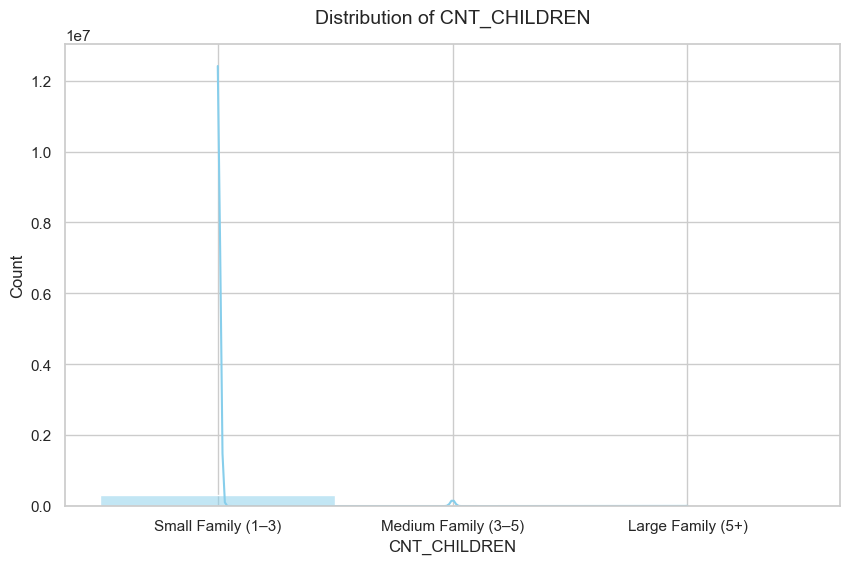

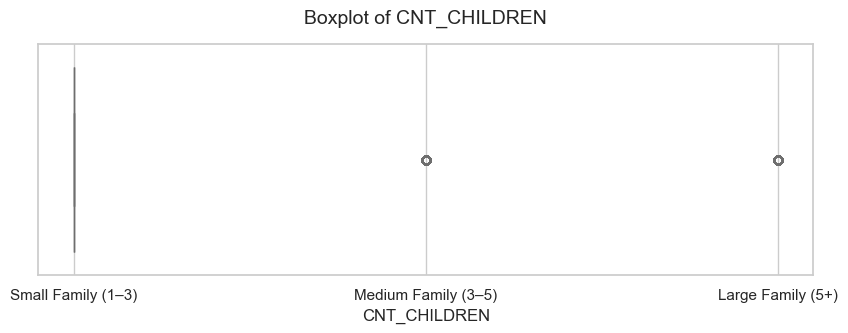

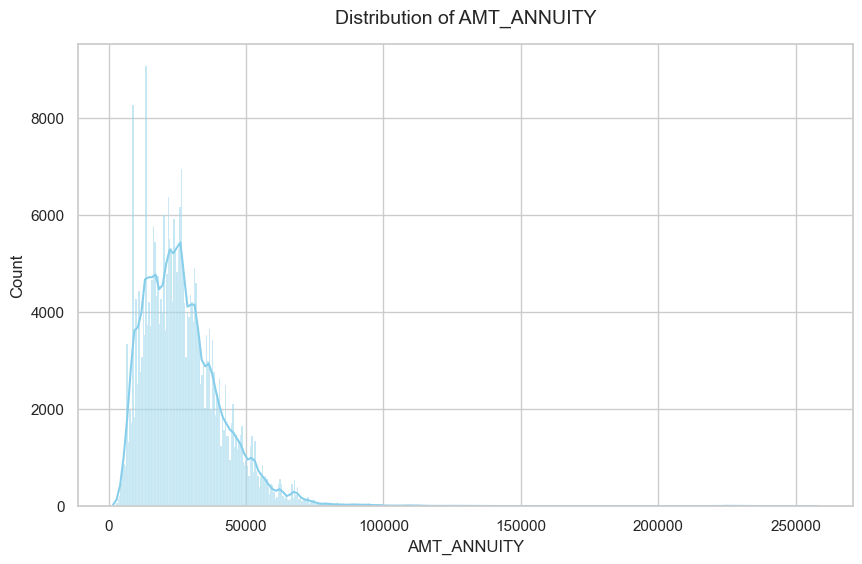

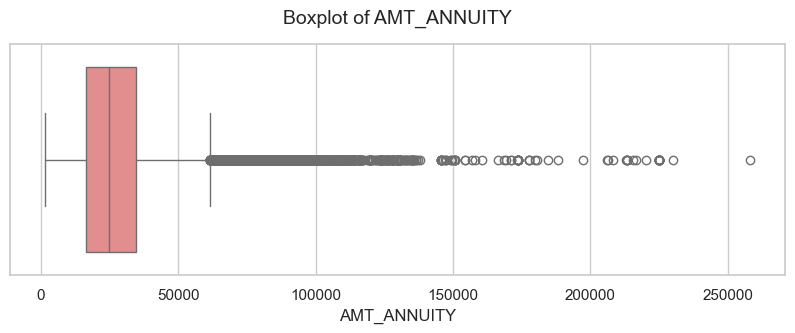

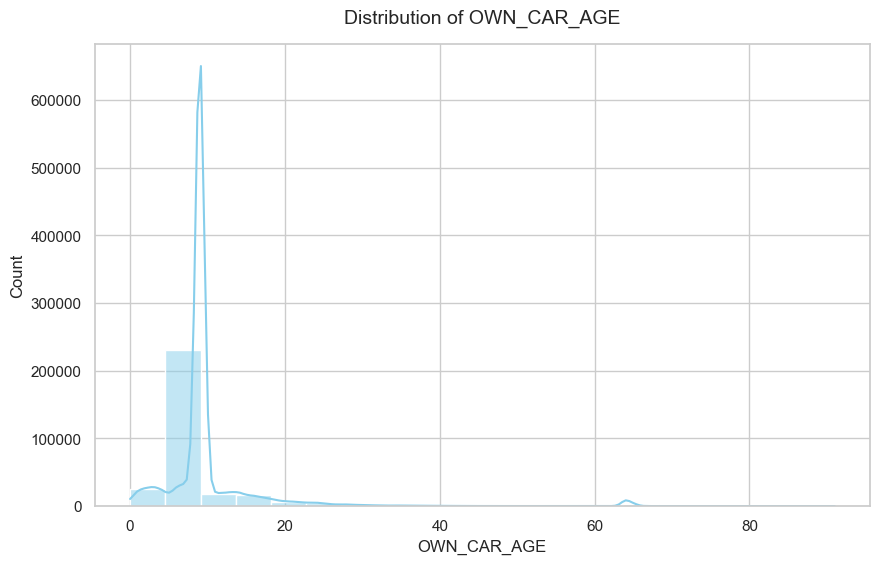

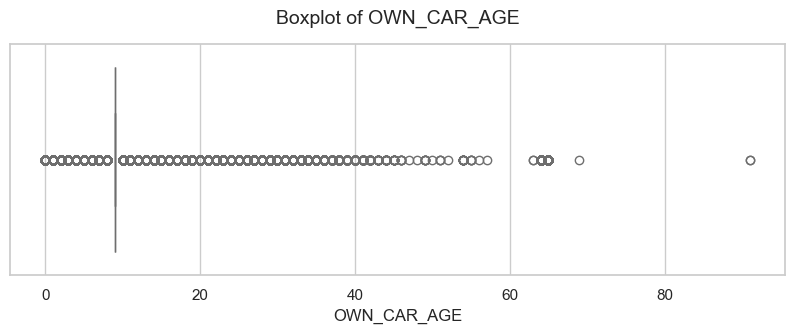

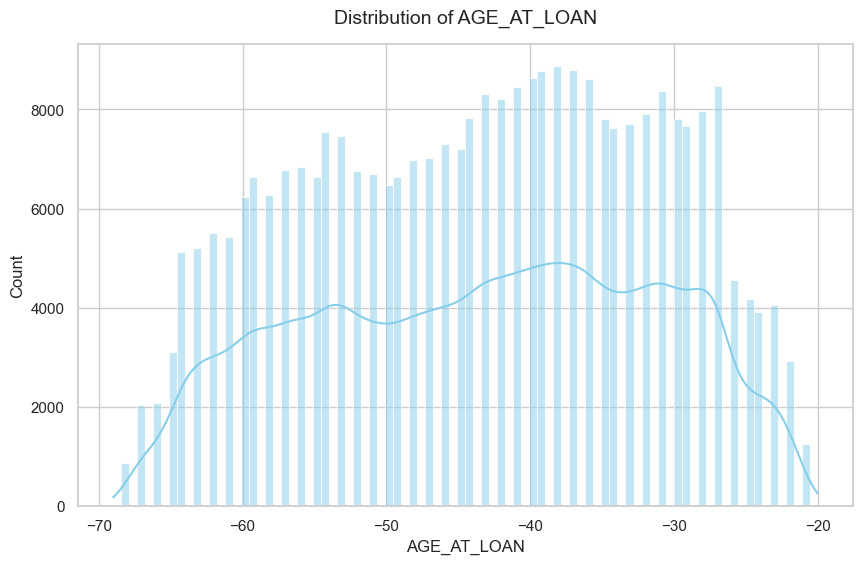

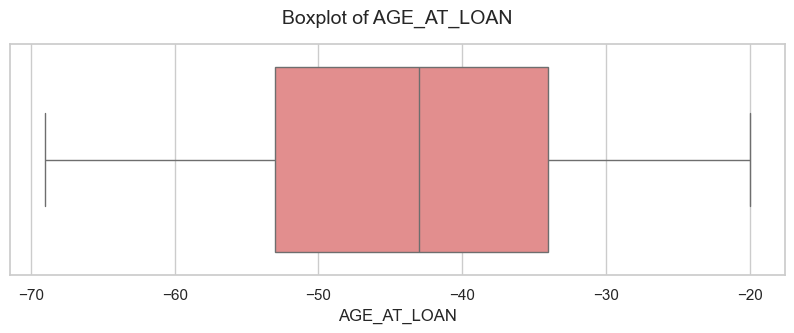

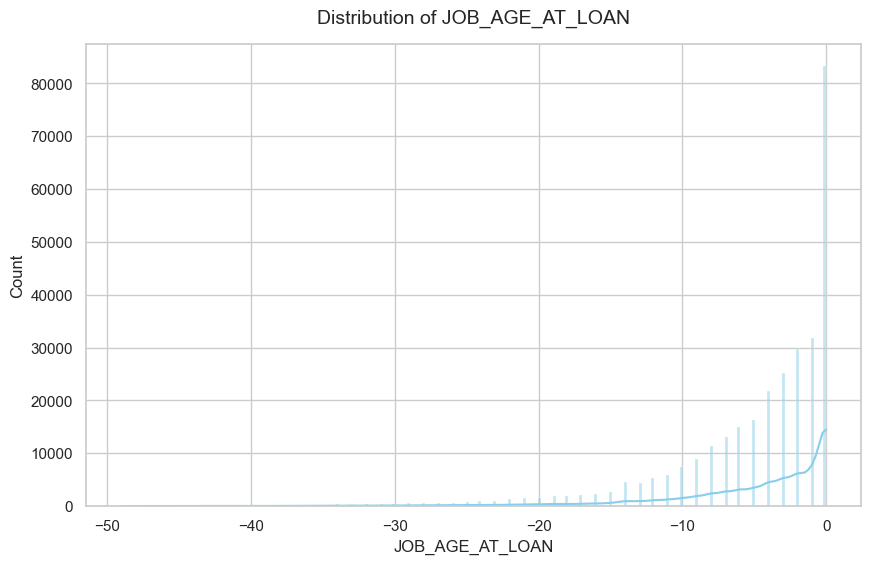

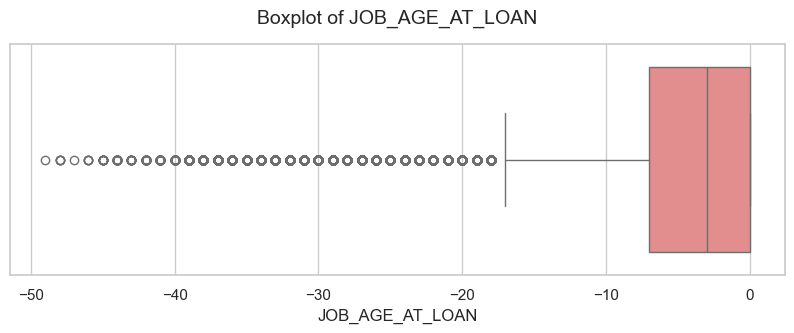

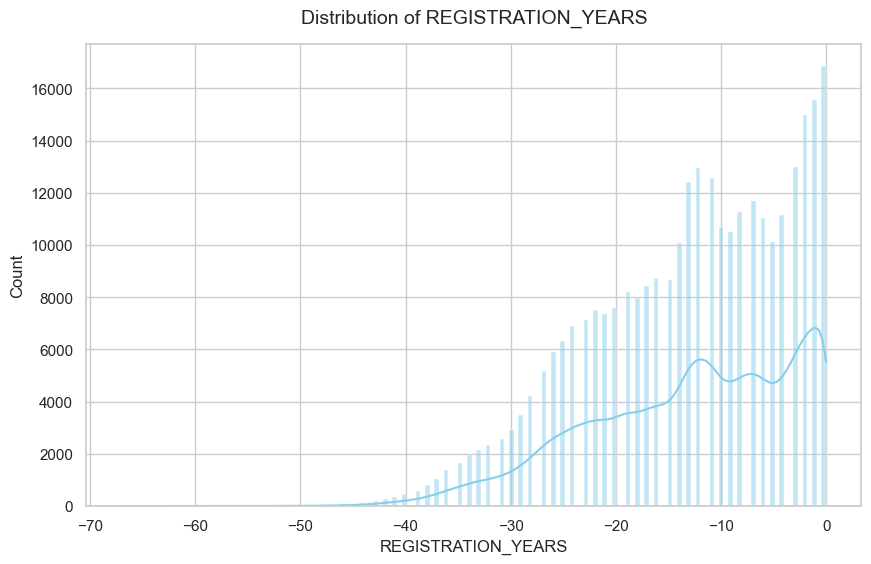

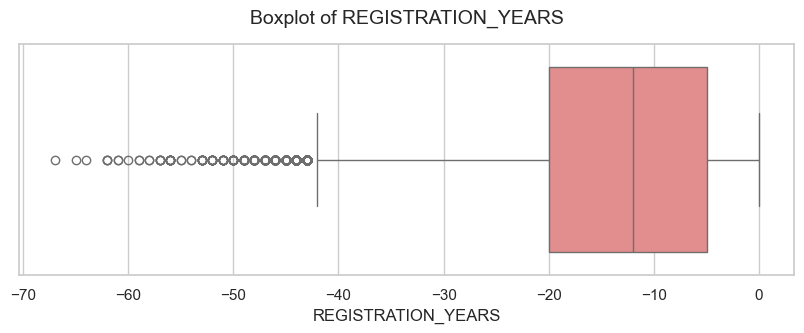

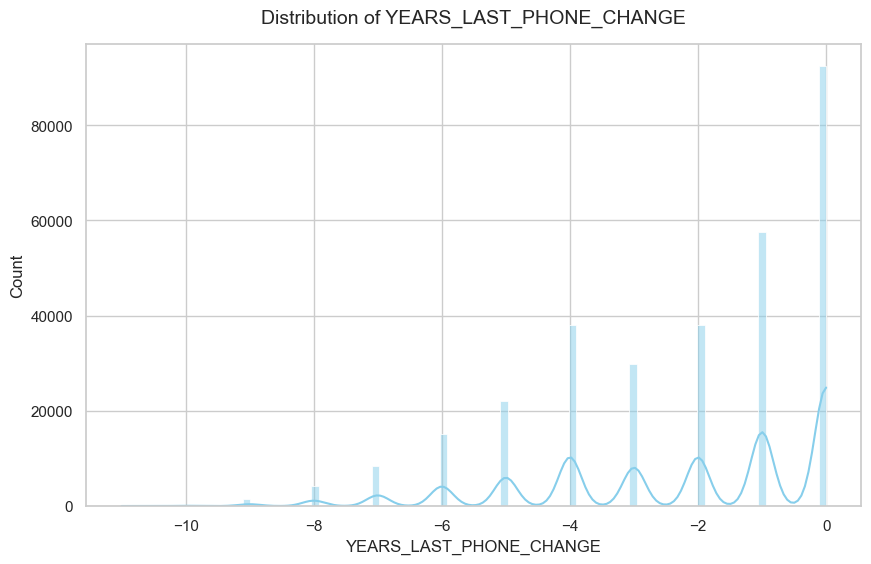

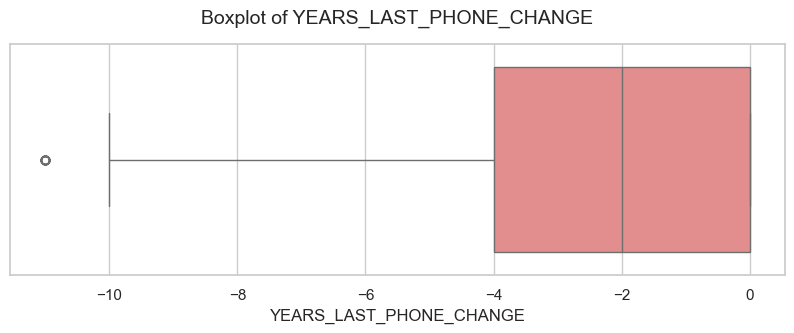

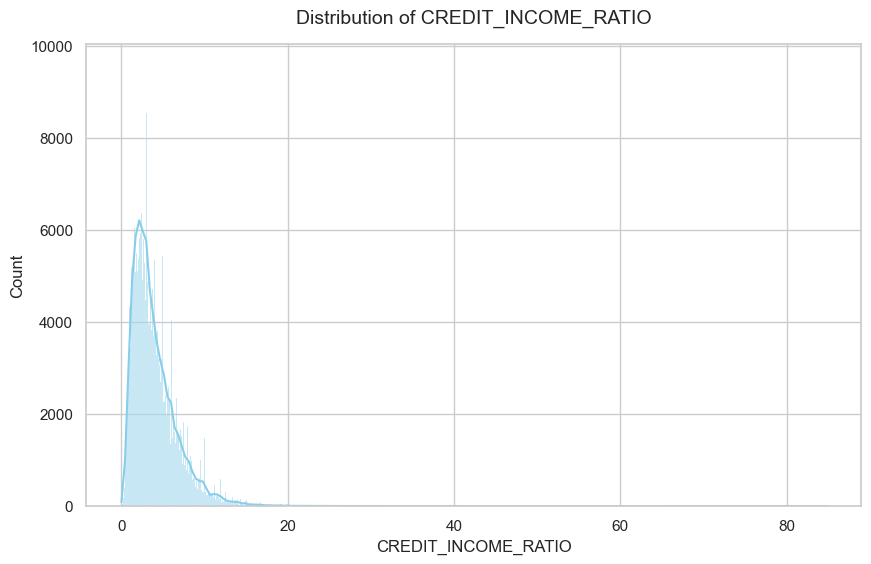

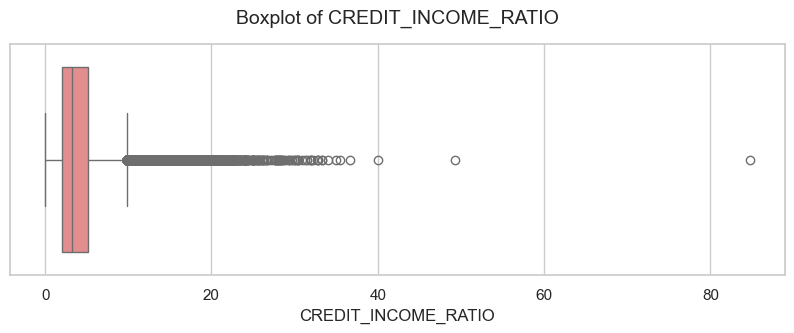

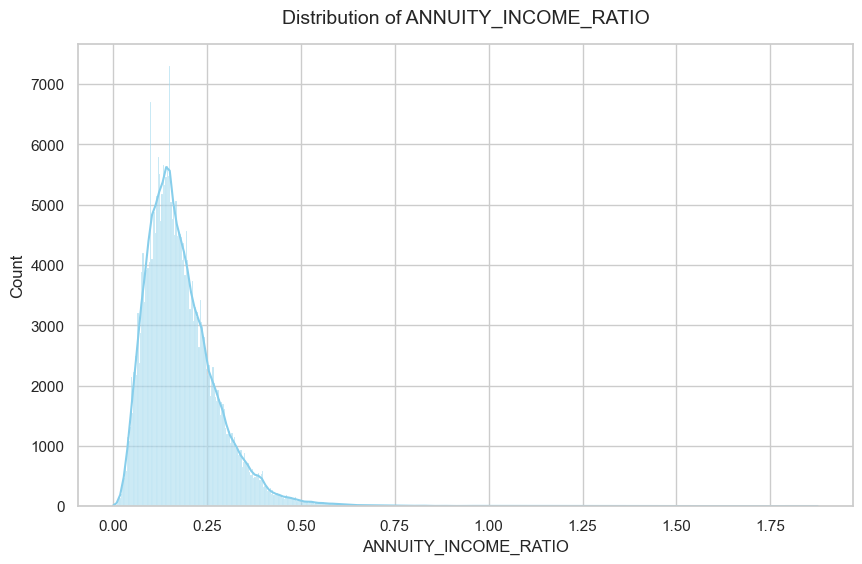

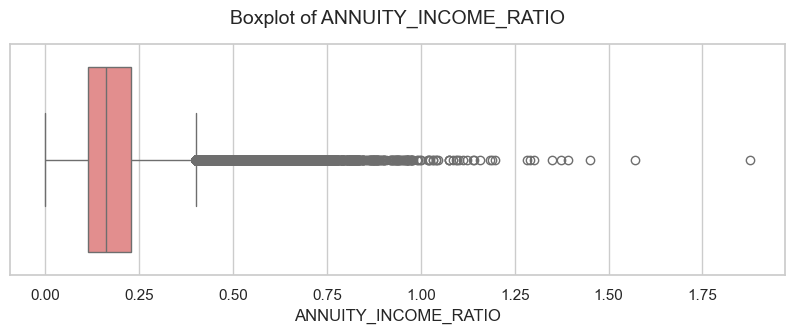

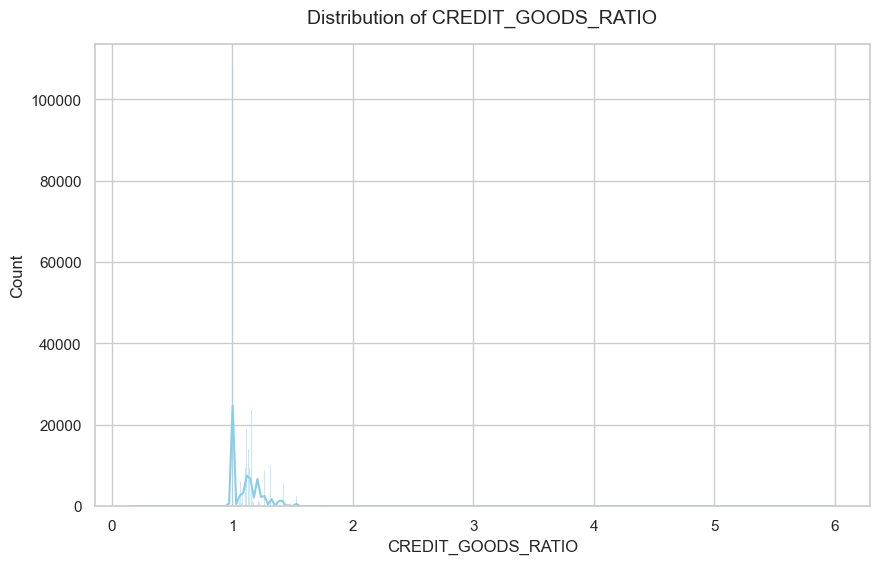

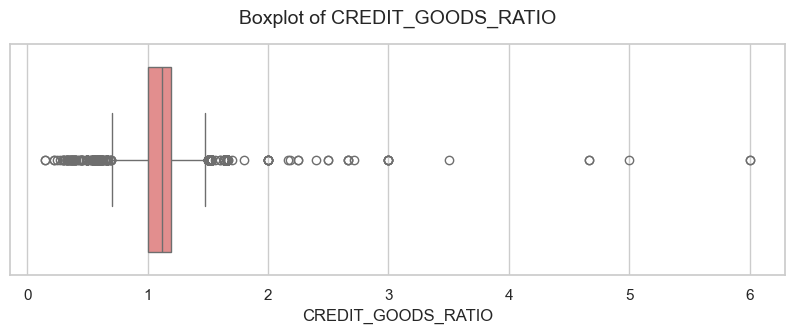

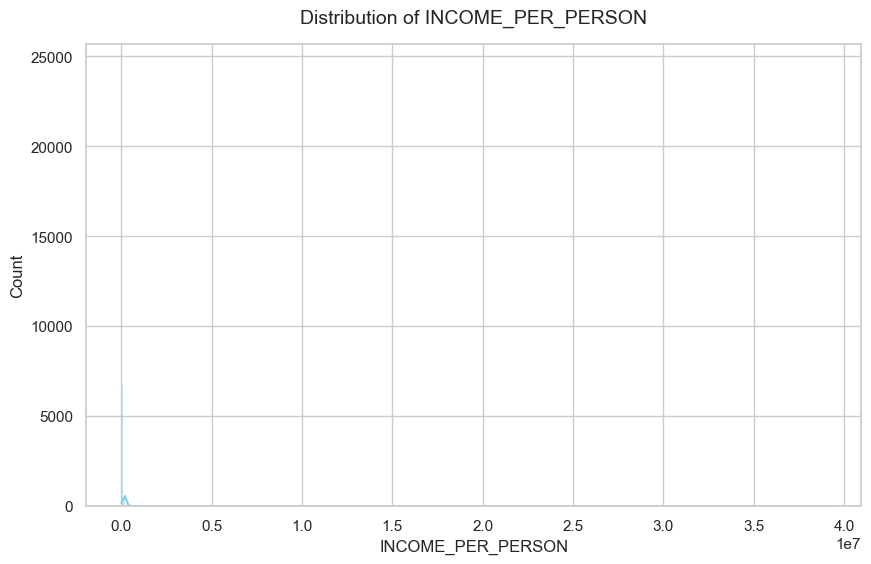

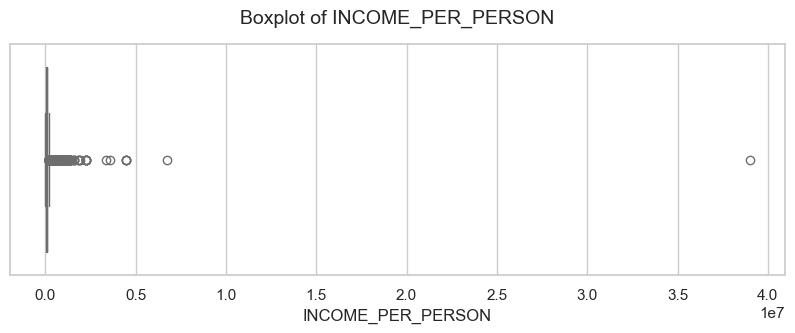

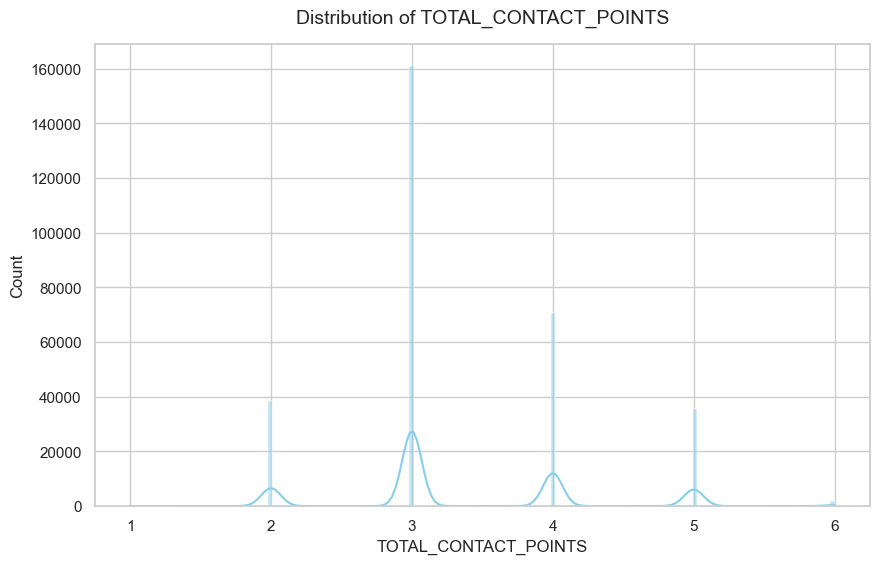

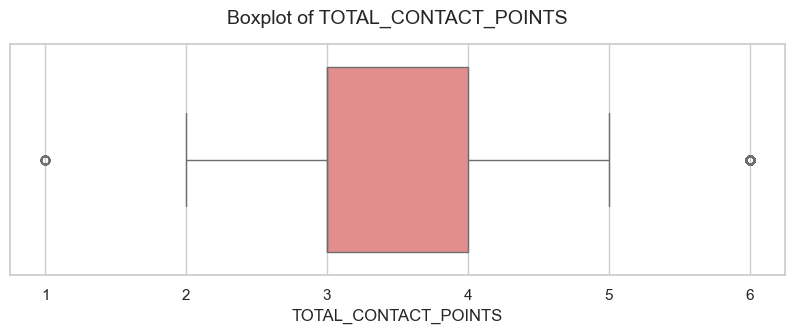

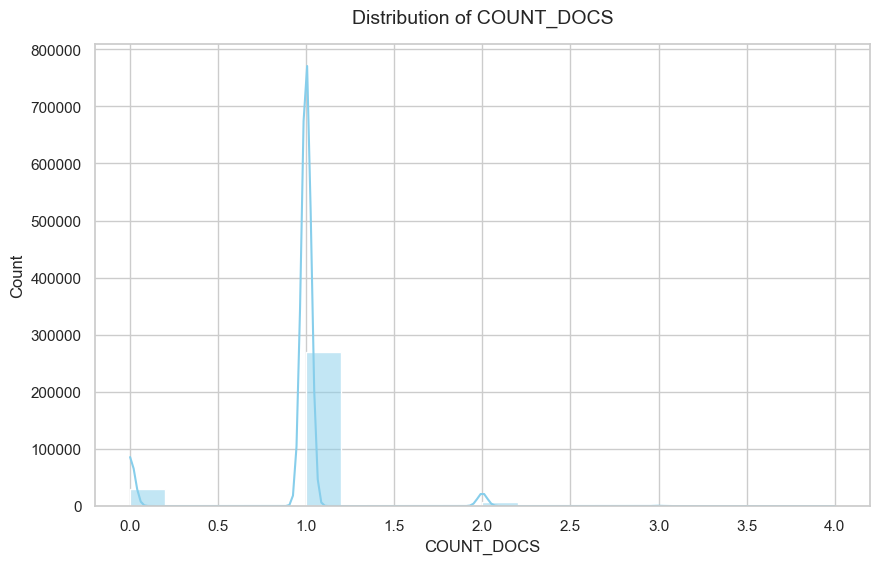

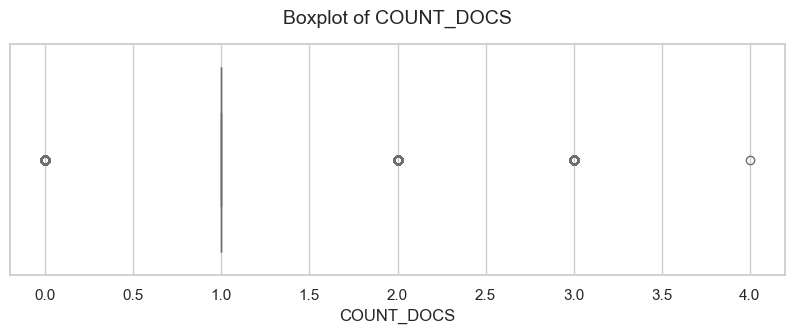

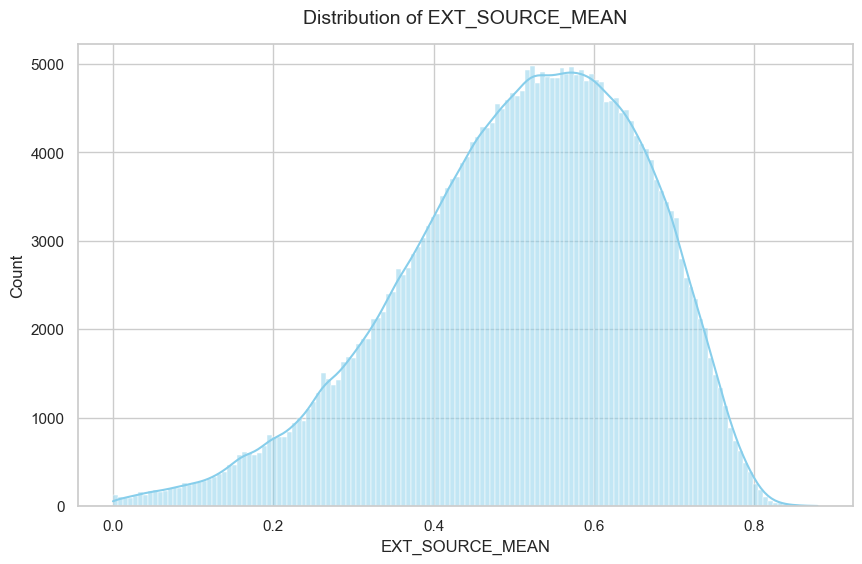

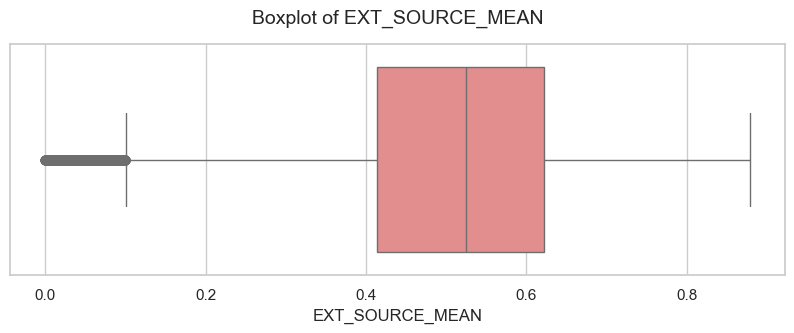

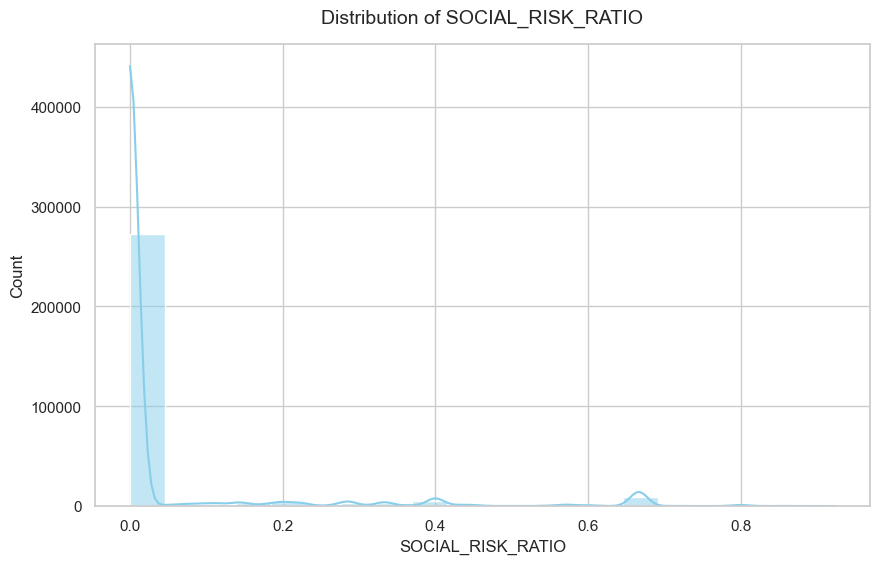

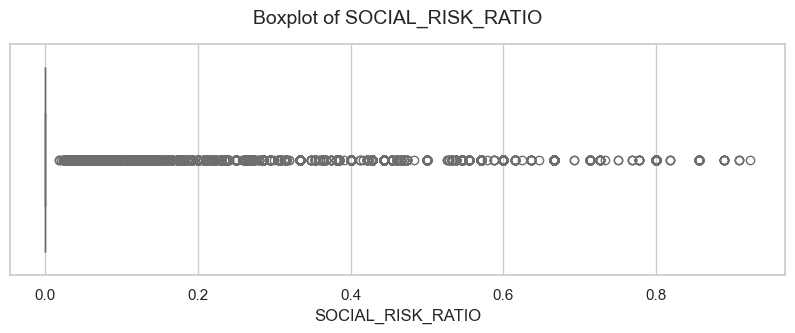

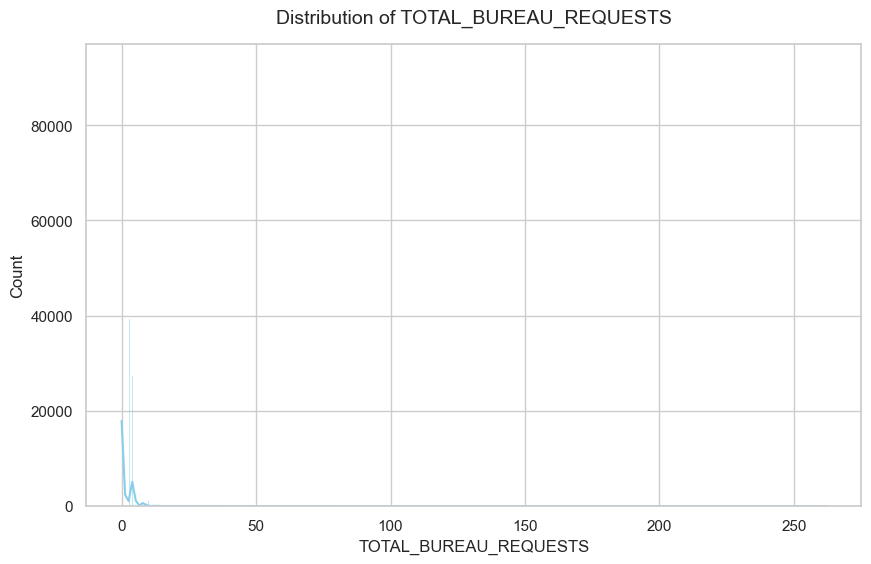

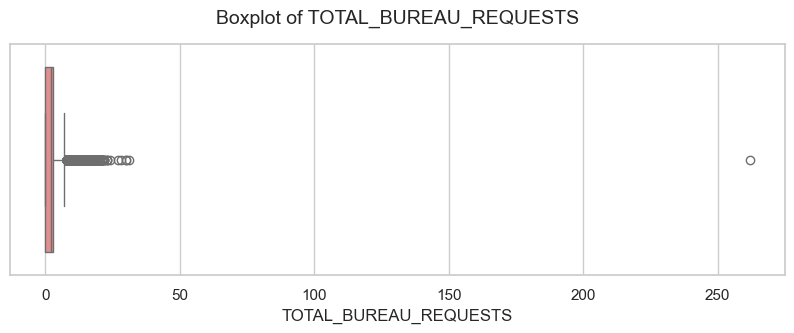

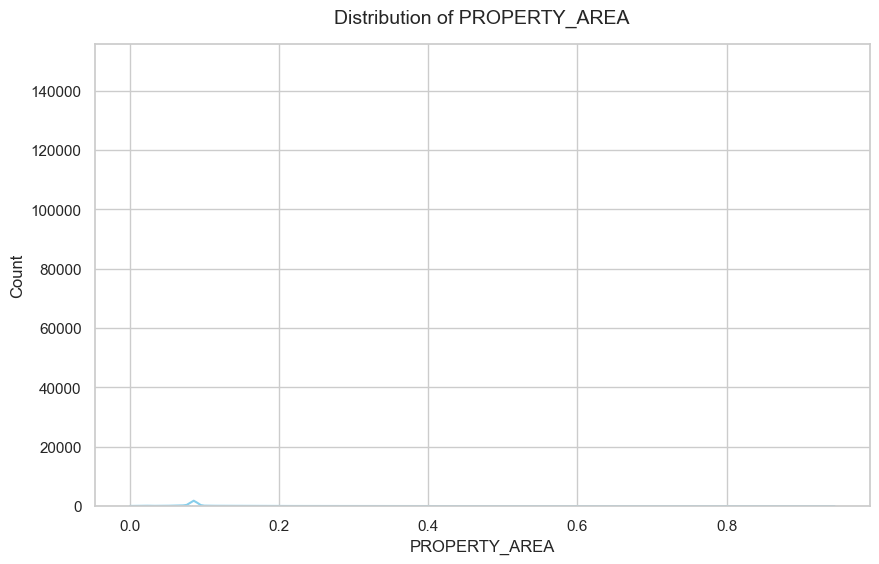

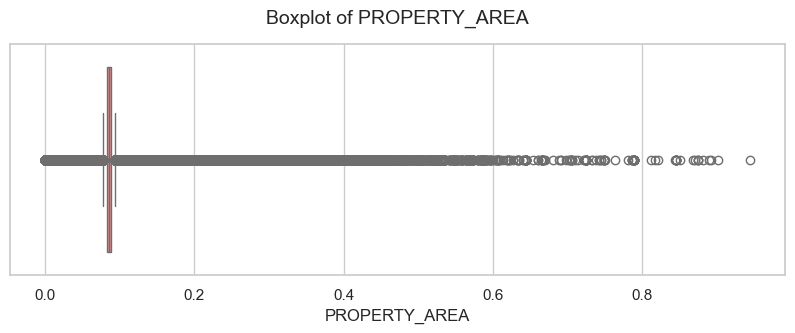

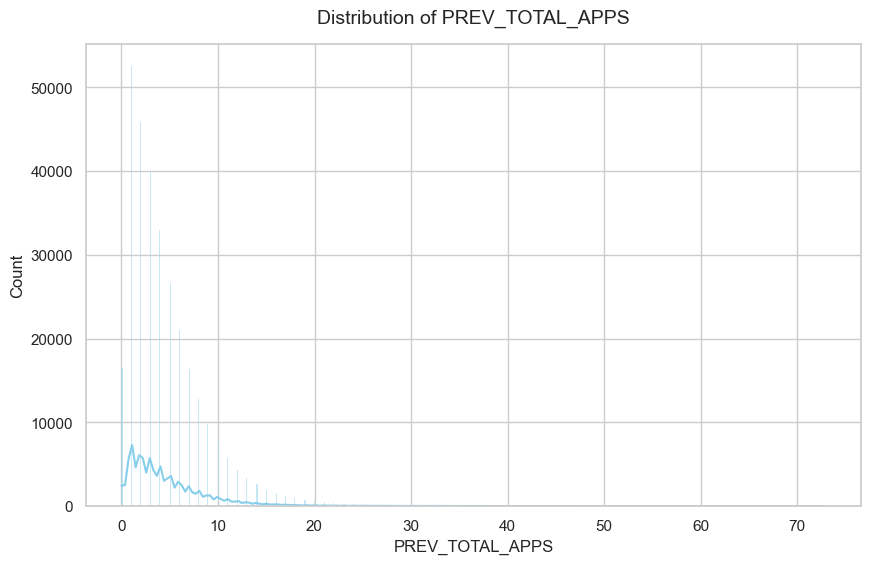

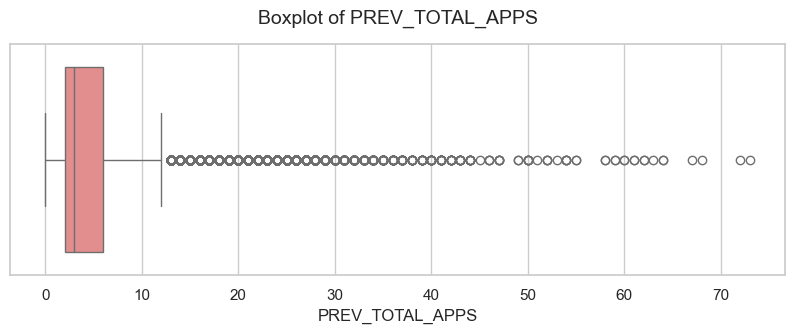

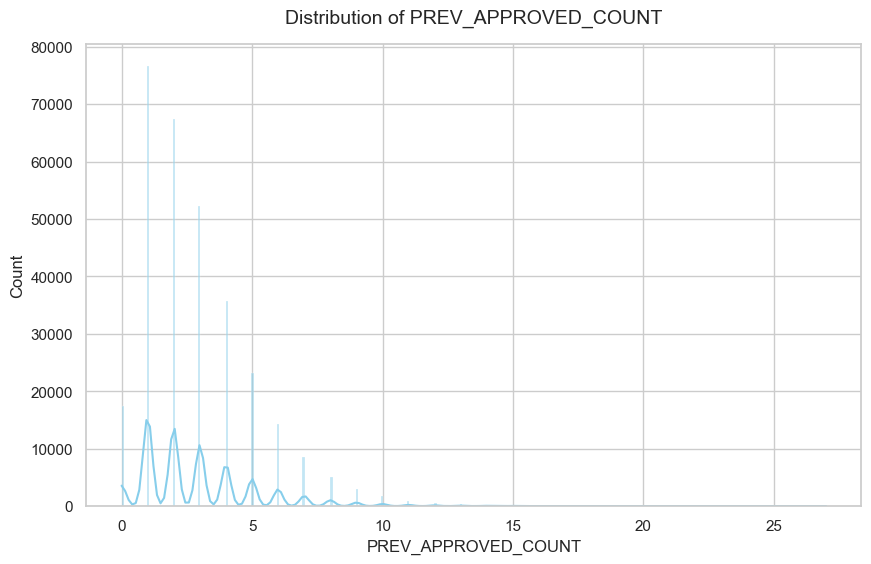

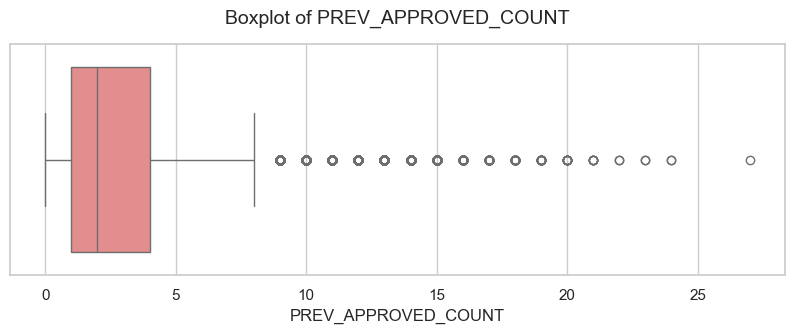

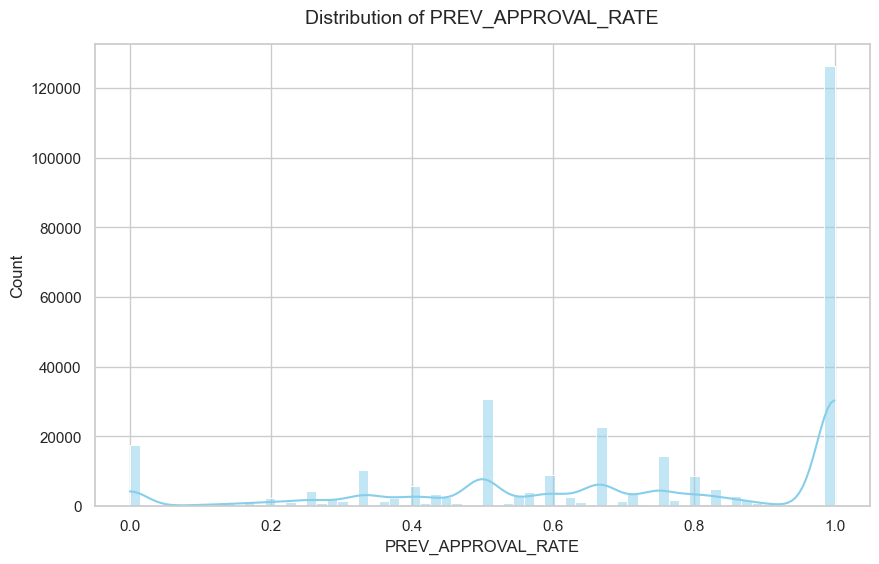

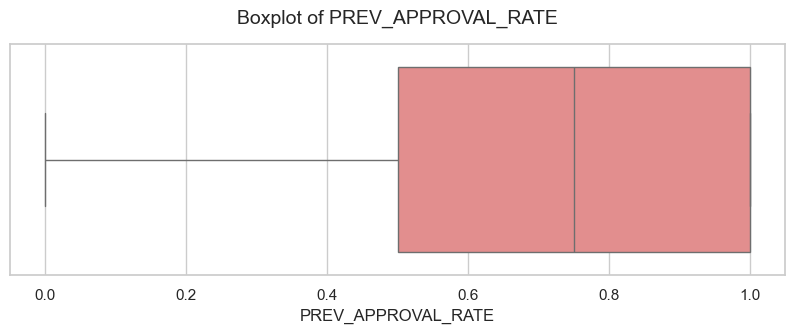

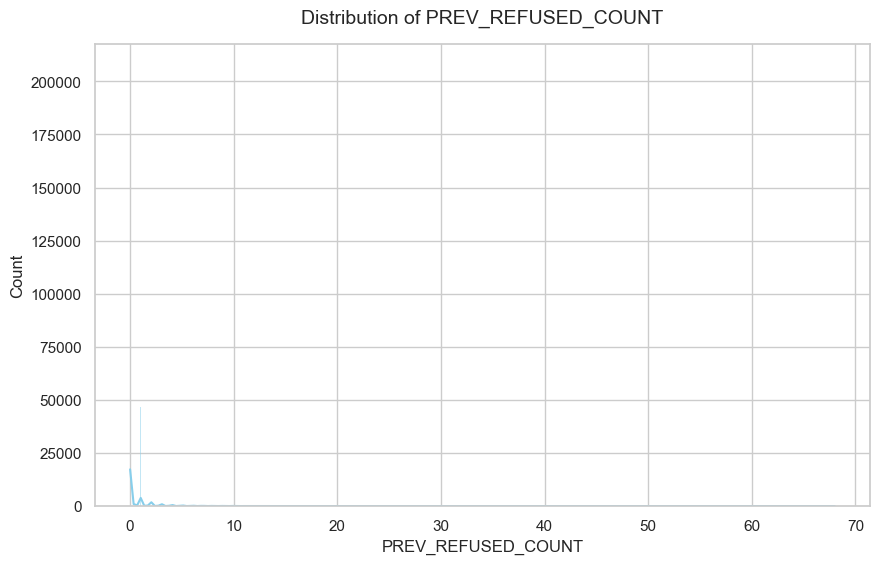

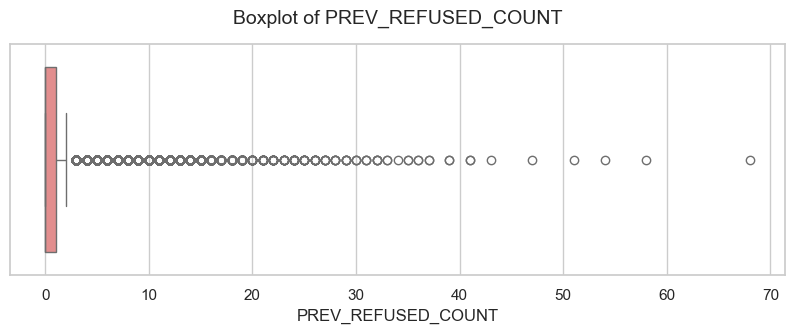

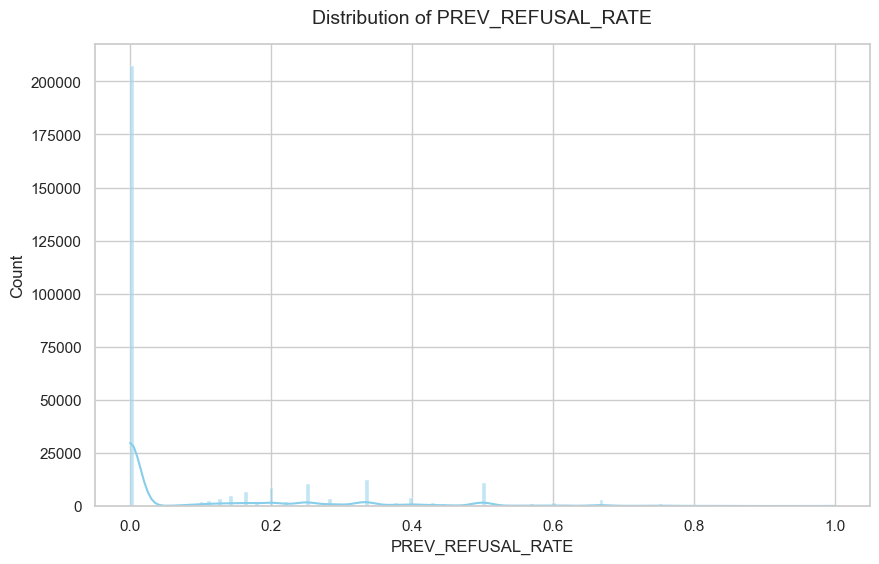

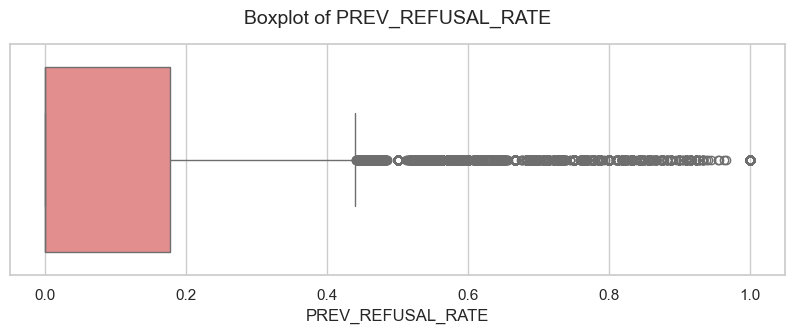

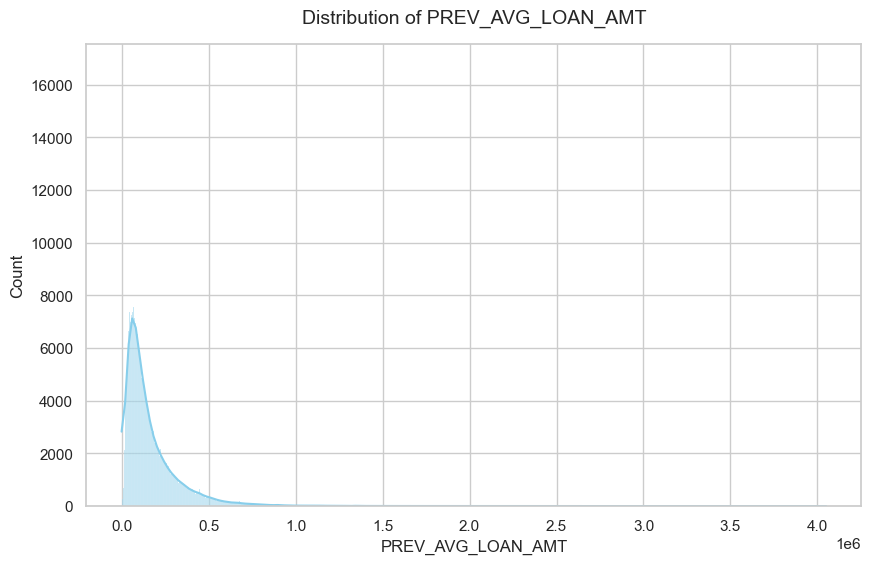

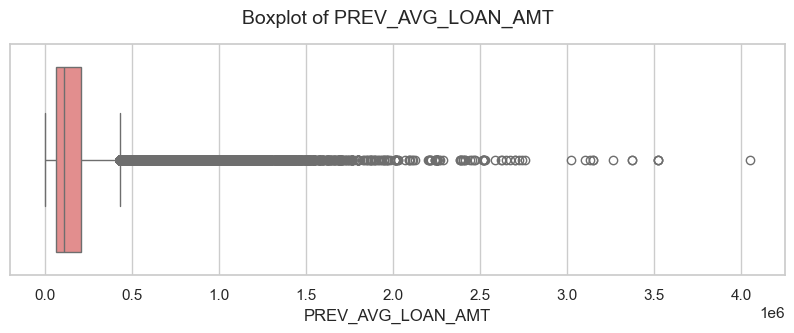

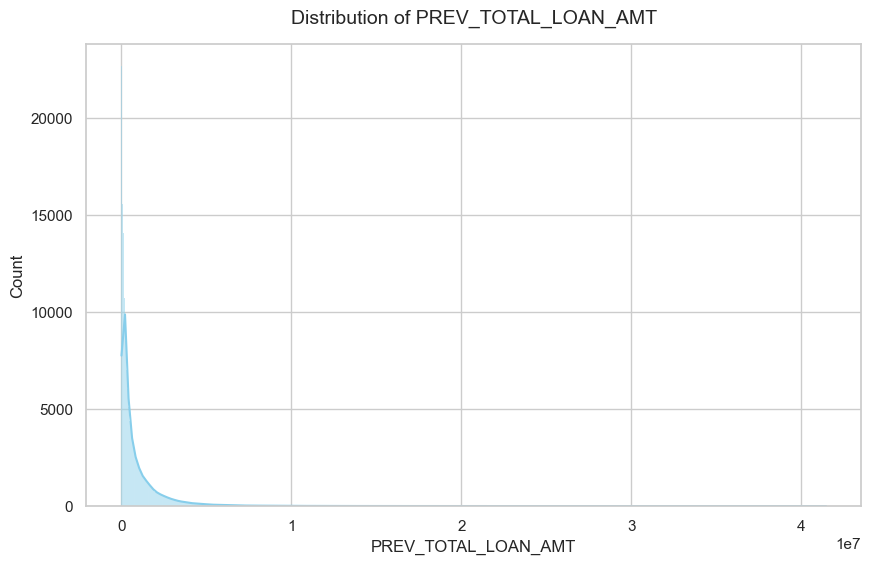

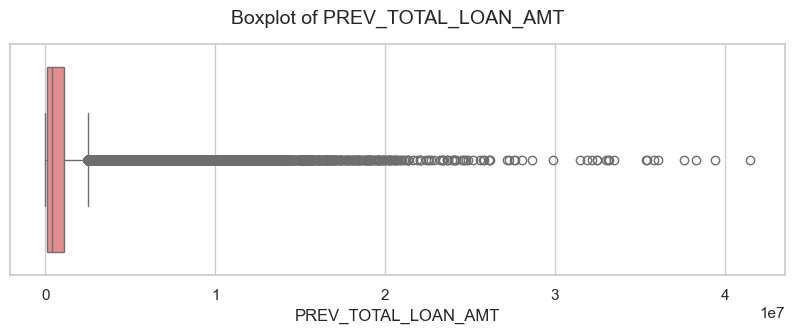

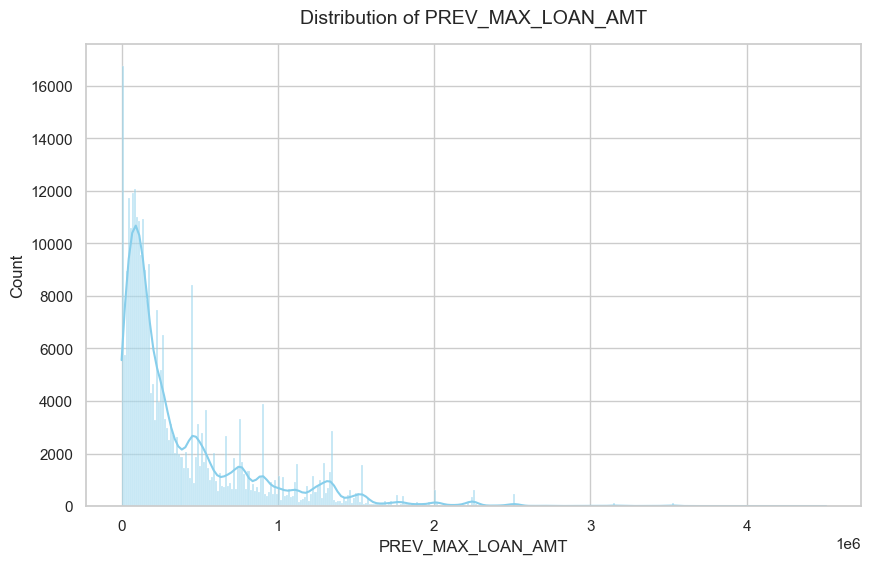

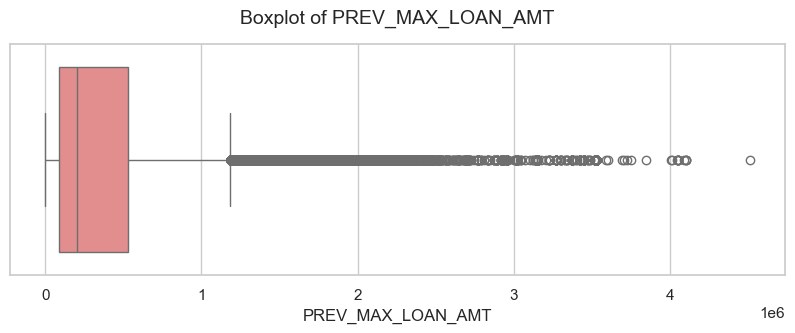

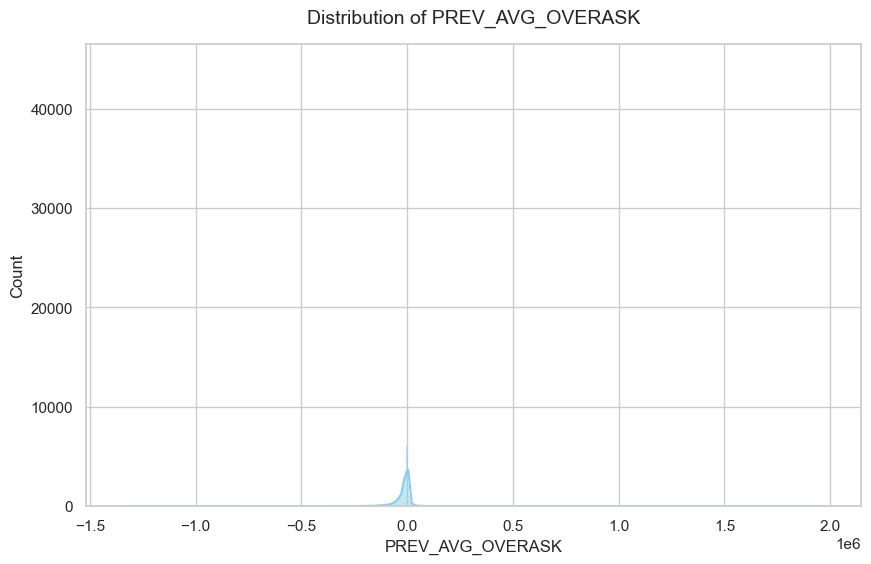

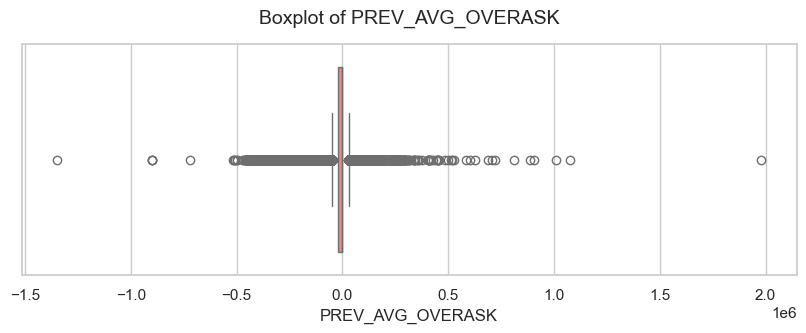

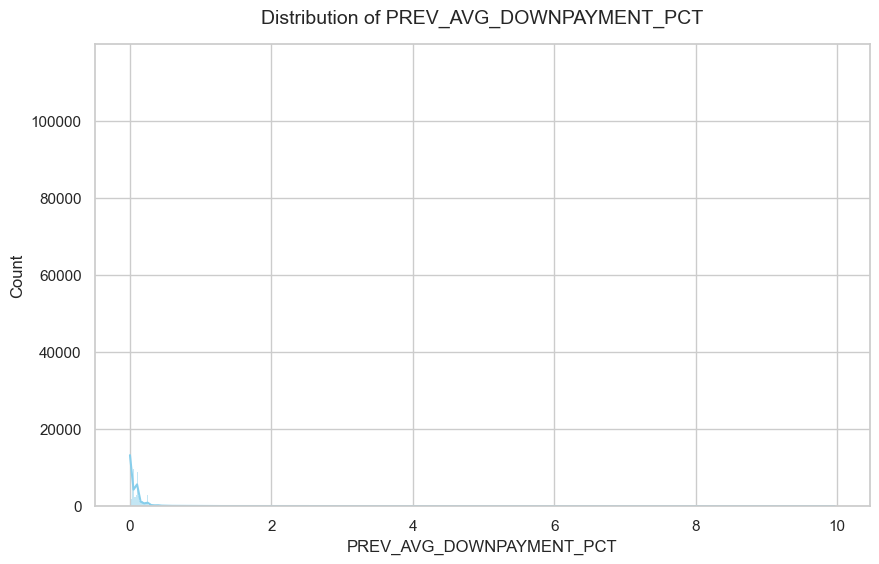

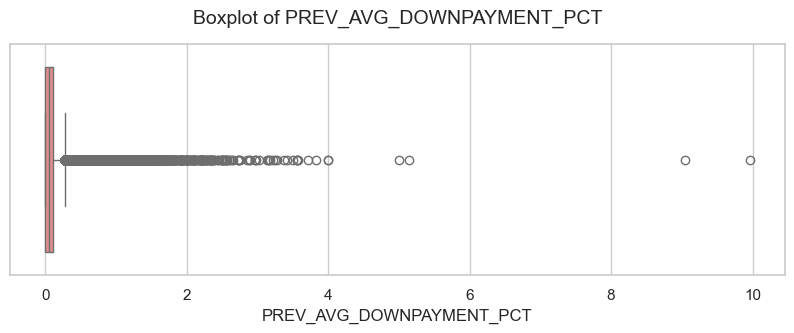

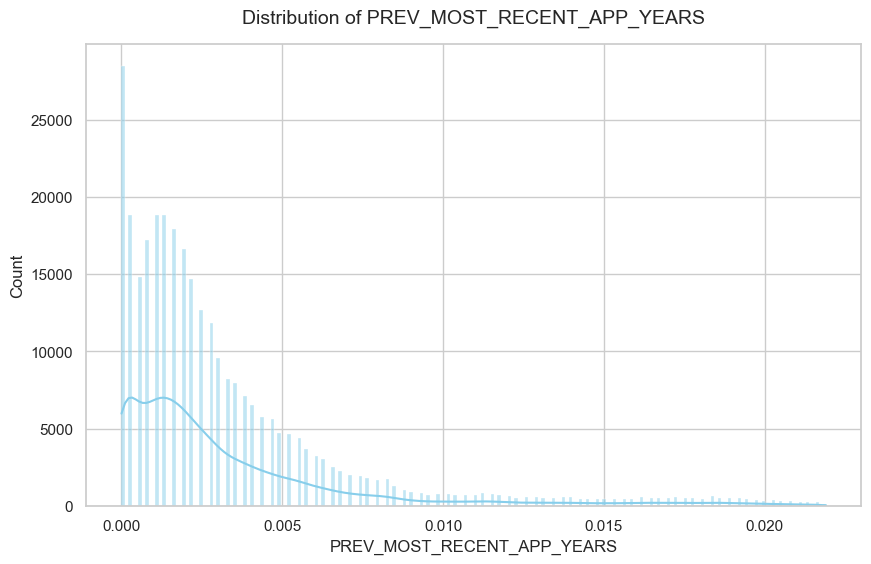

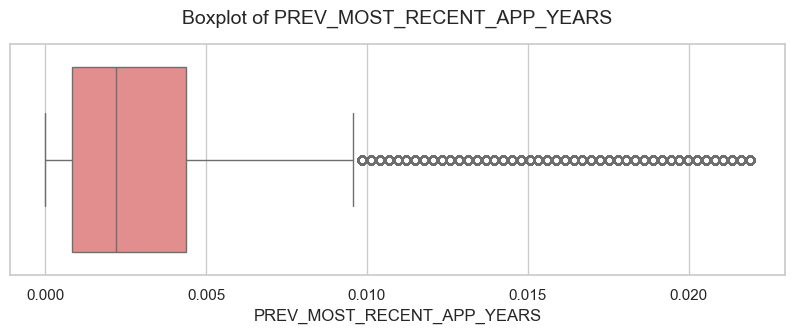

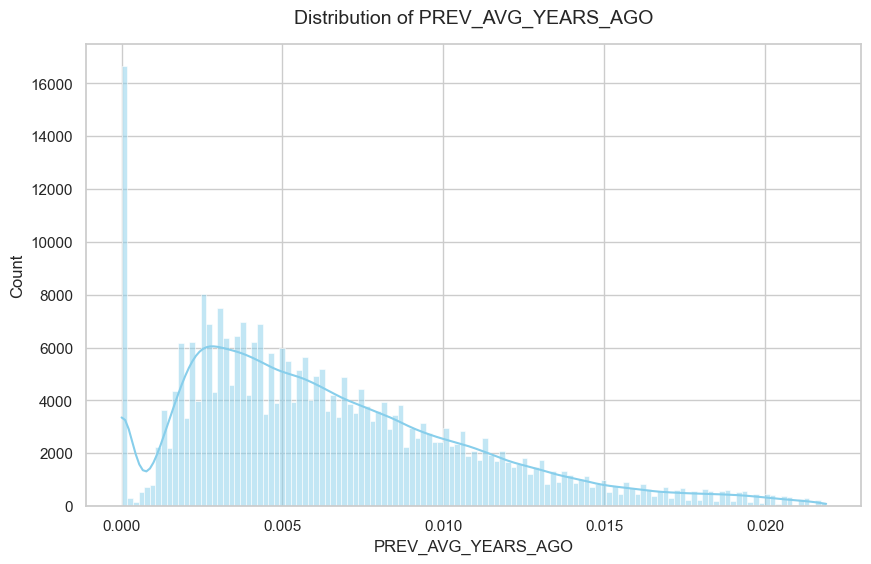

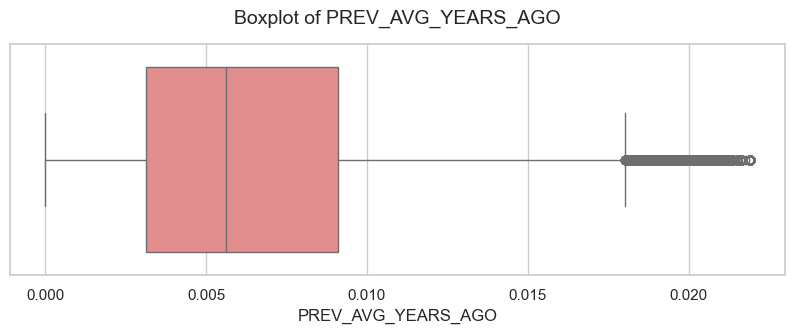

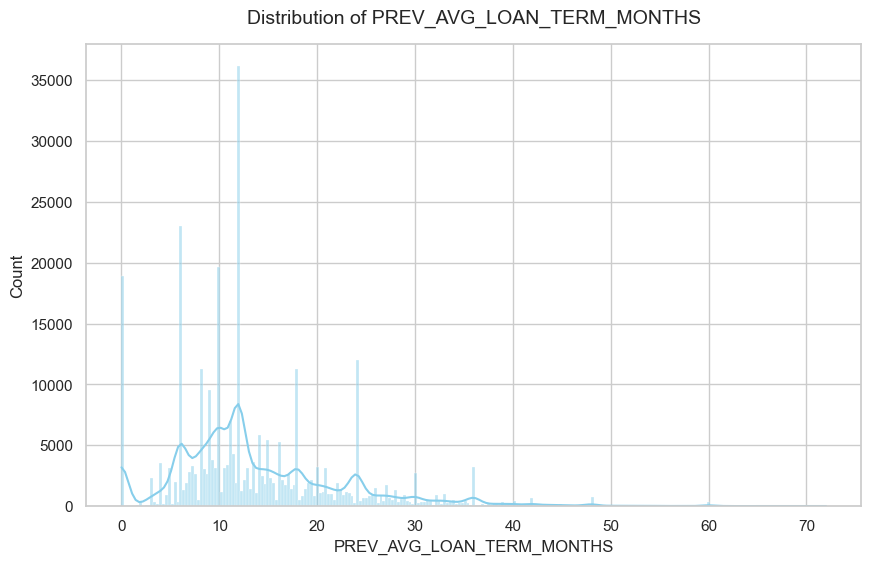

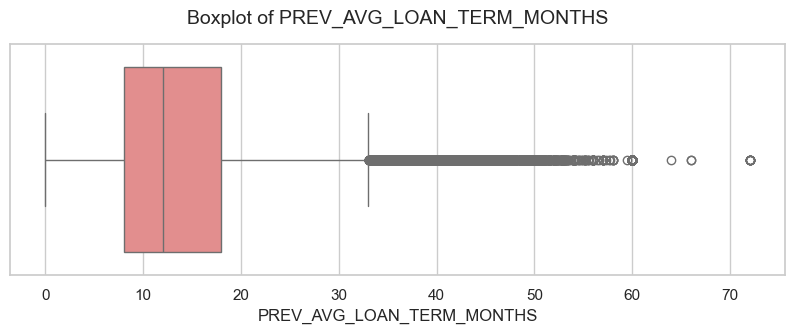

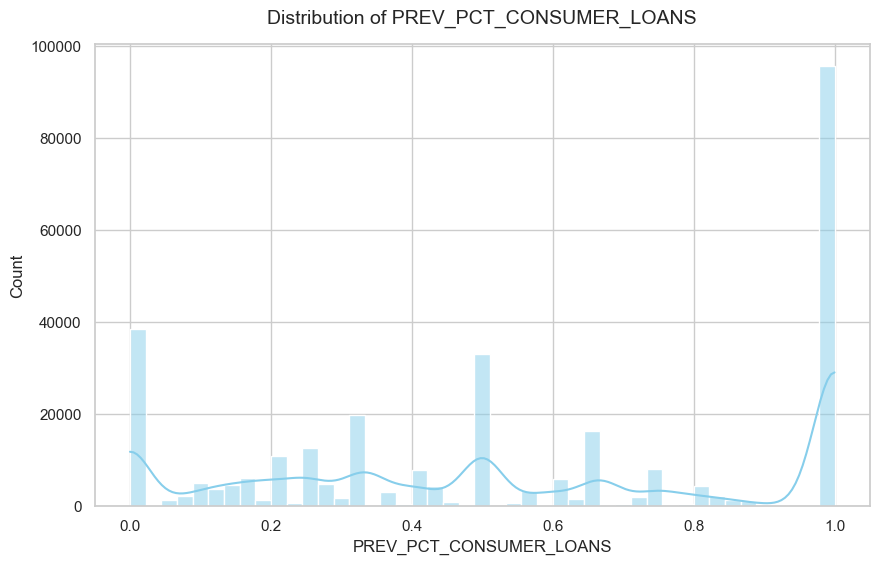

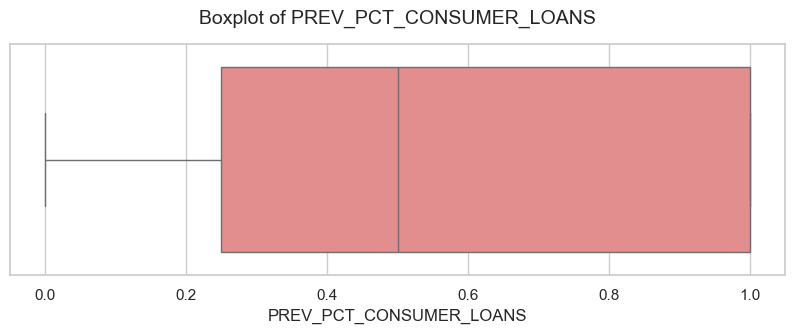

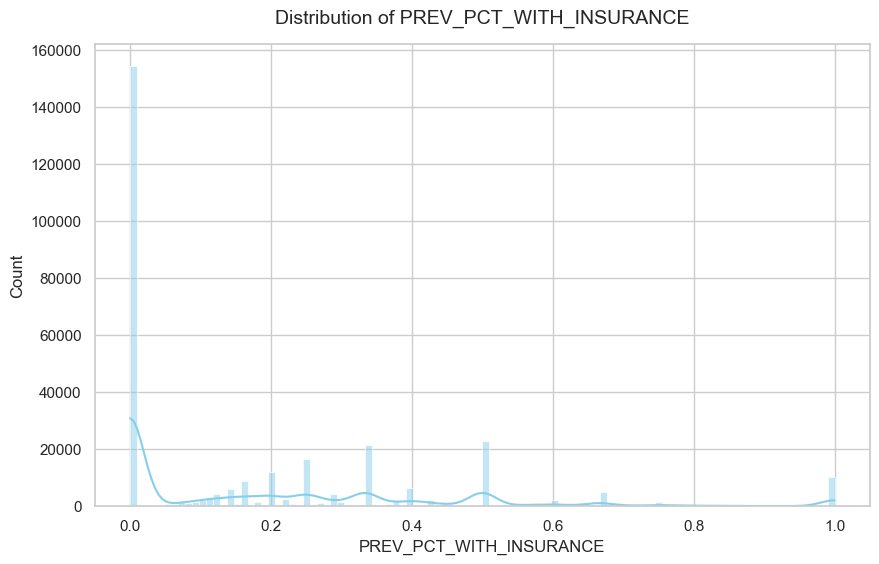

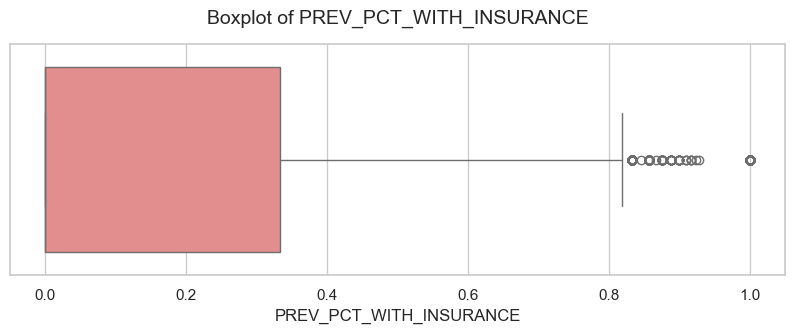

All histograms and boxplots saved!


In [18]:

# Your loop – short and clean, just like you wanted
for col in num_features:
    if col in df.columns:
        
        # ───── Histogram + KDE ─────
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, color="skyblue")
        plt.title(f'Distribution of {col}', fontsize=14, pad=15)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"{col}_histogram.png"), bbox_inches="tight", dpi=300)
        plt.show()         
        plt.close()        
        
        # ───── Boxplot ─────
        plt.figure(figsize=(10, 3))
        sns.boxplot(x=df[col], color="lightcoral")
        plt.title(f'Boxplot of {col}', fontsize=14, pad=15)
        plt.xlabel(col)
        plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"{col}_boxplot.png"), bbox_inches="tight", dpi=300)
        plt.show()
        plt.close()

print("All histograms and boxplots saved!")



#### Categorical features distributions

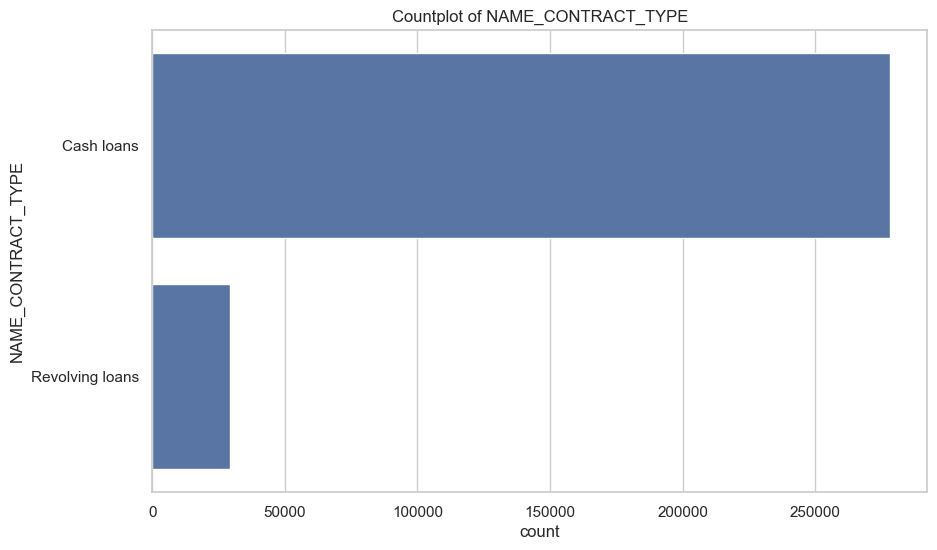

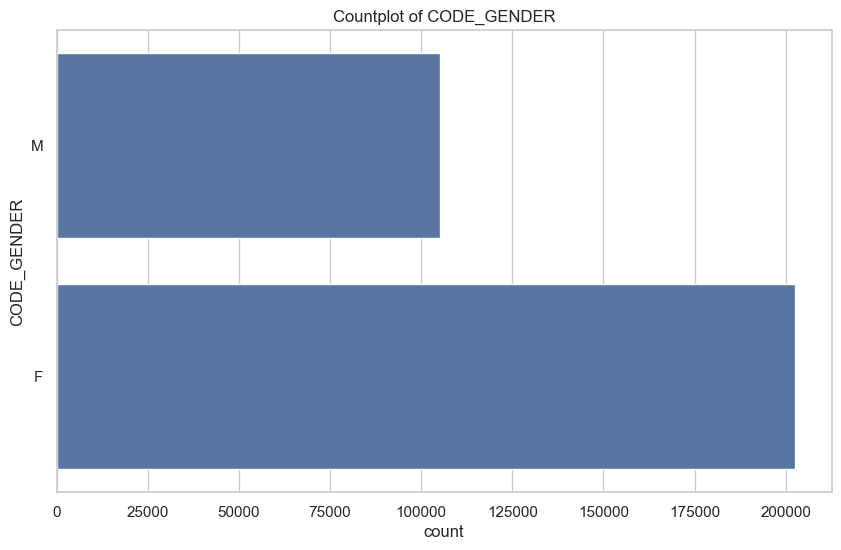

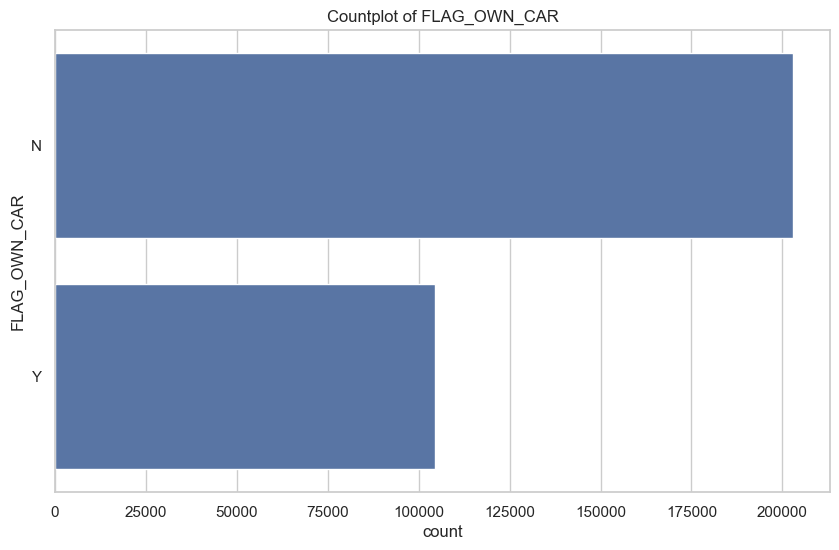

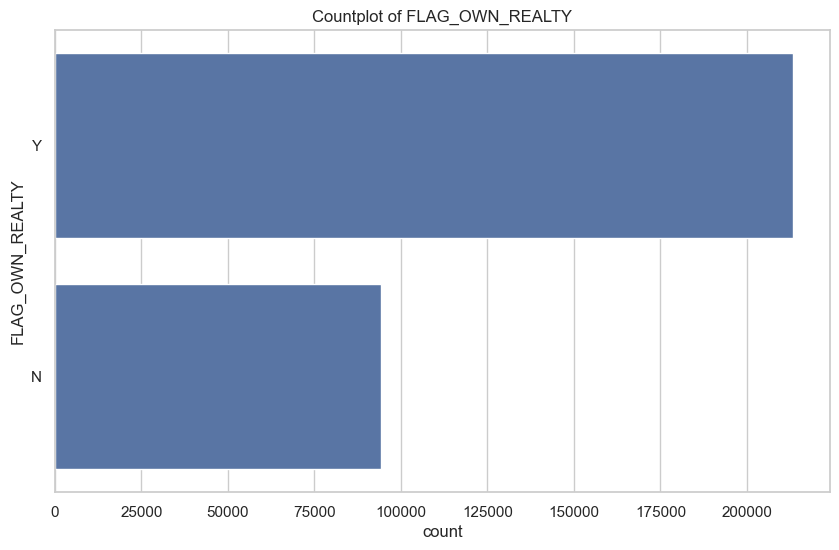

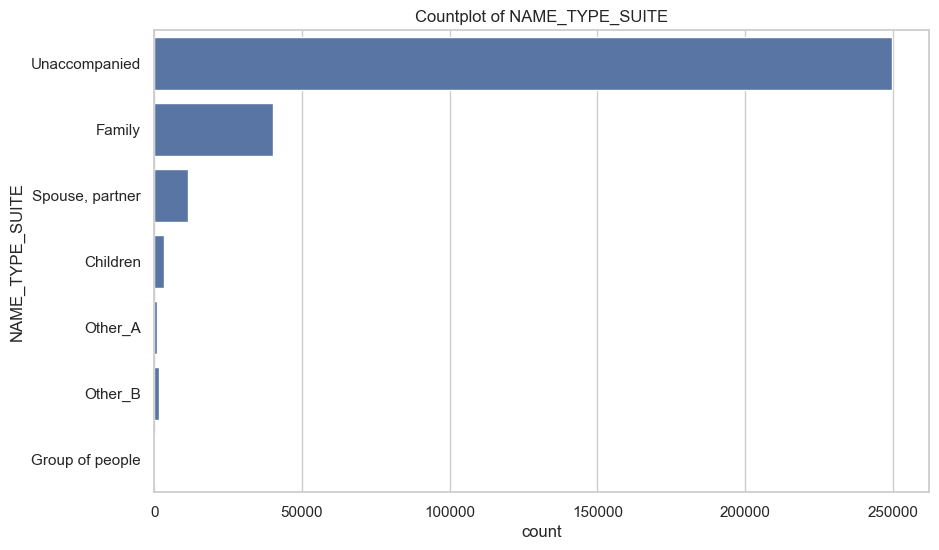

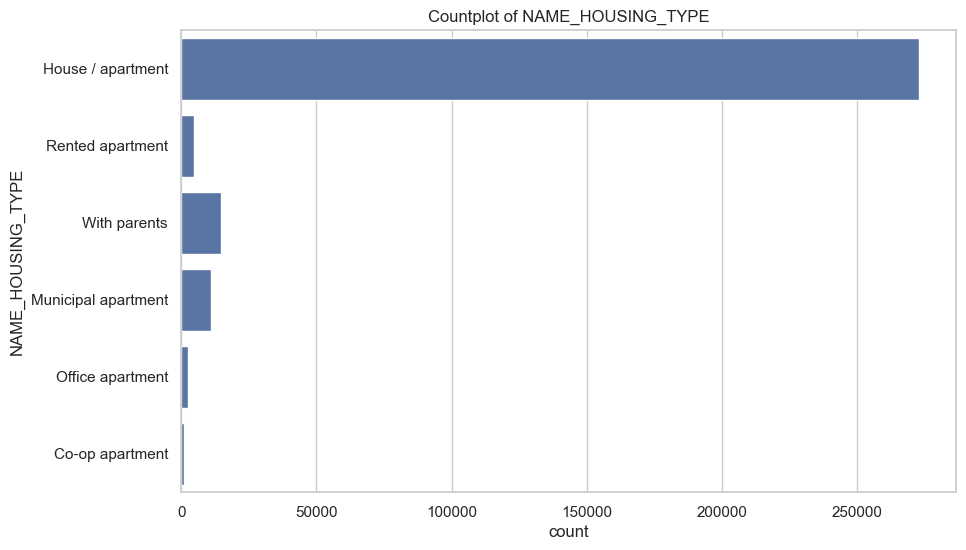

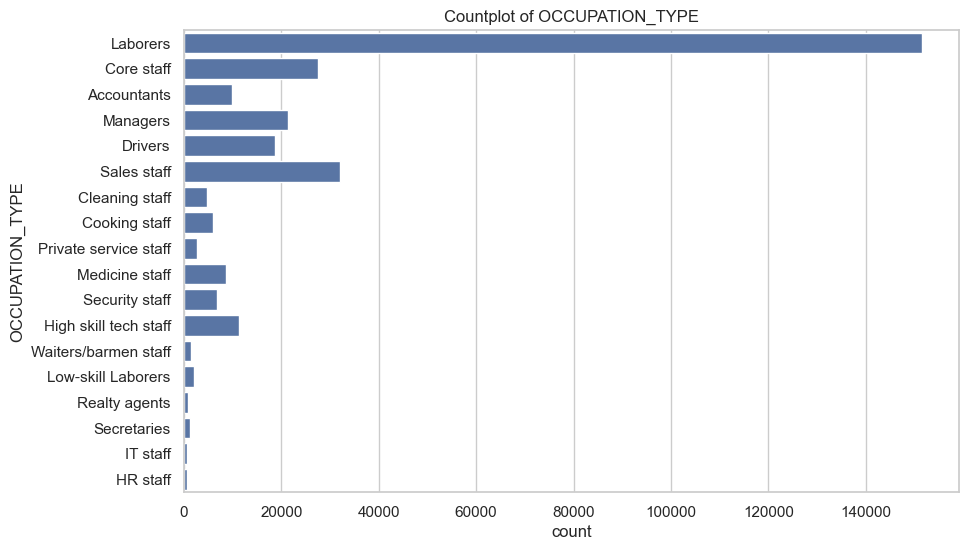

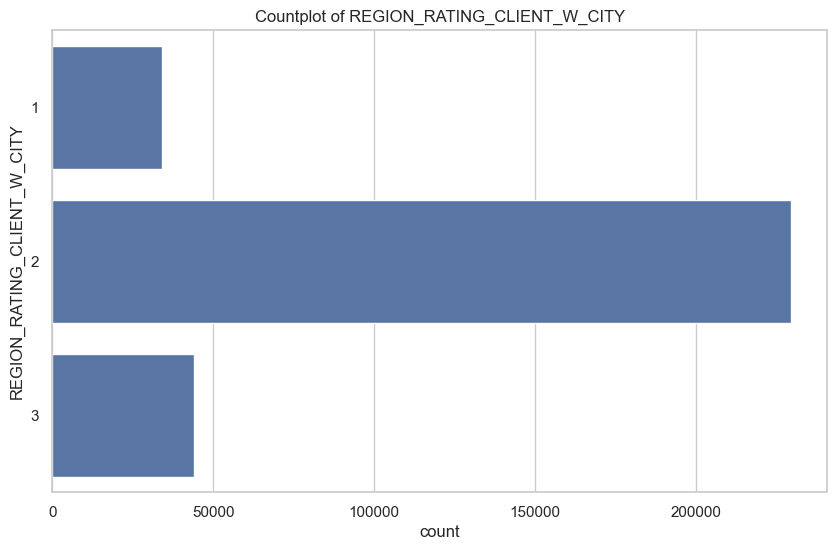

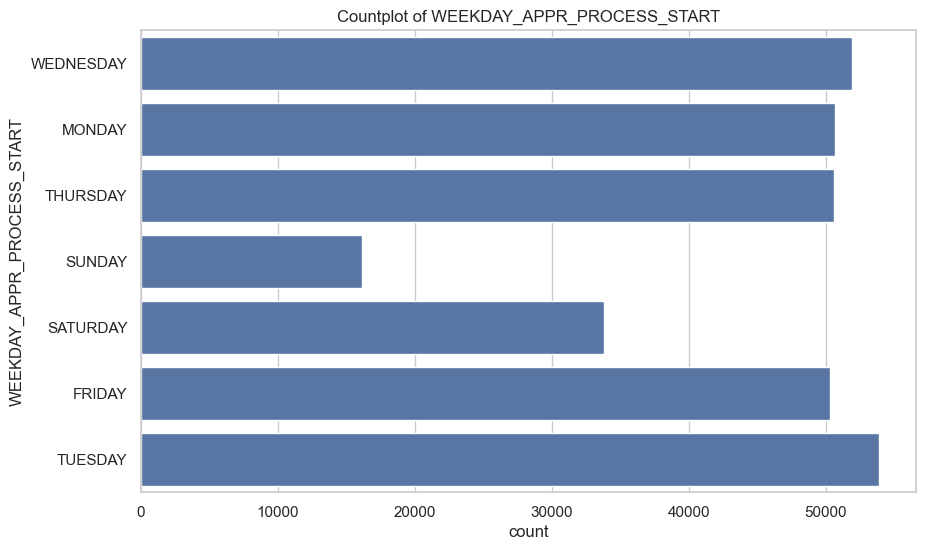

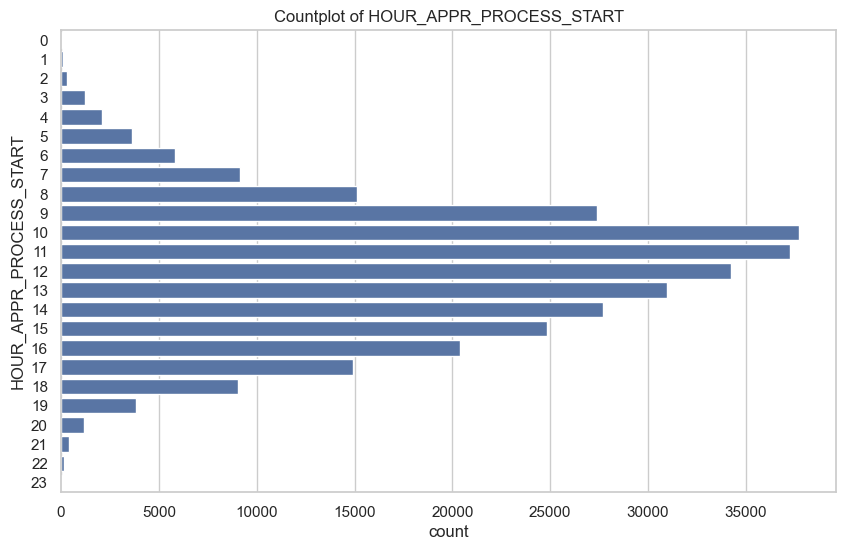

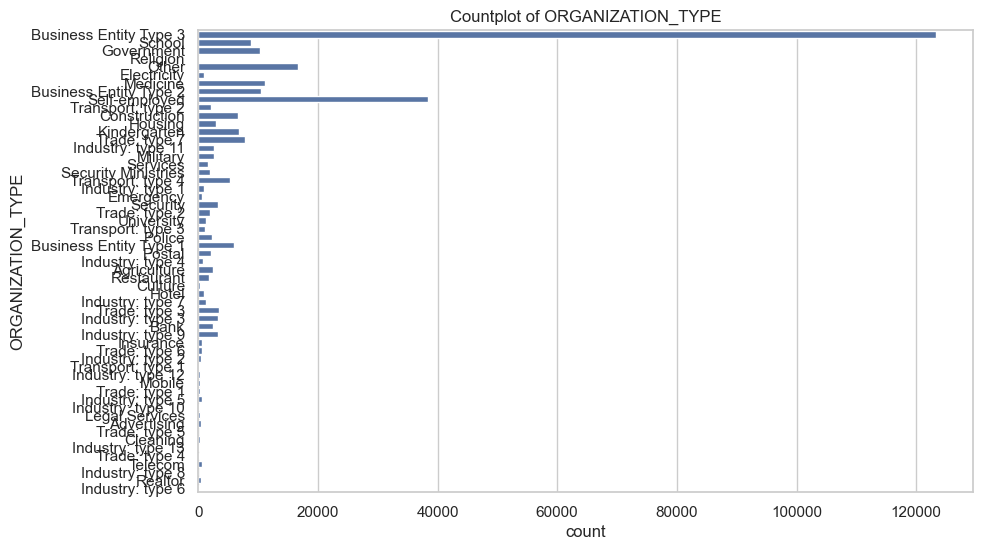

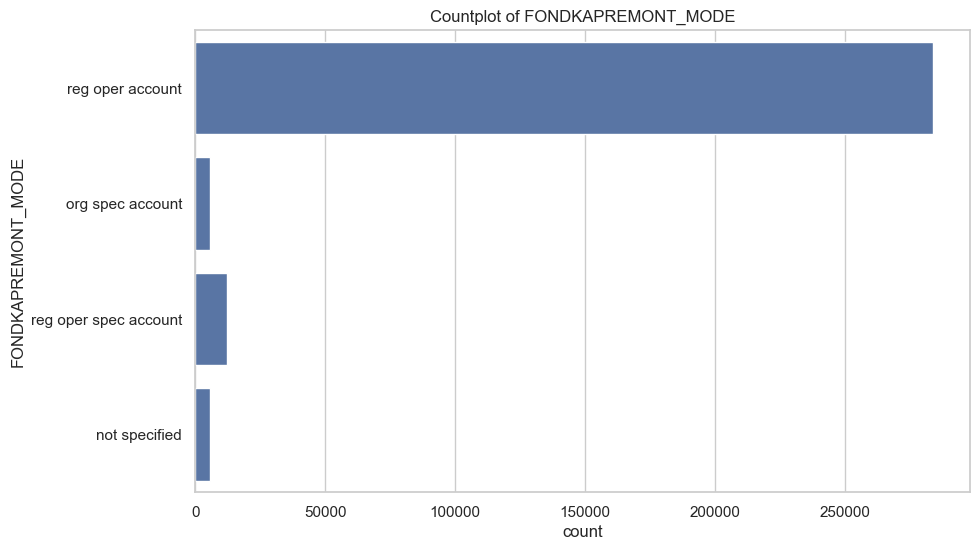

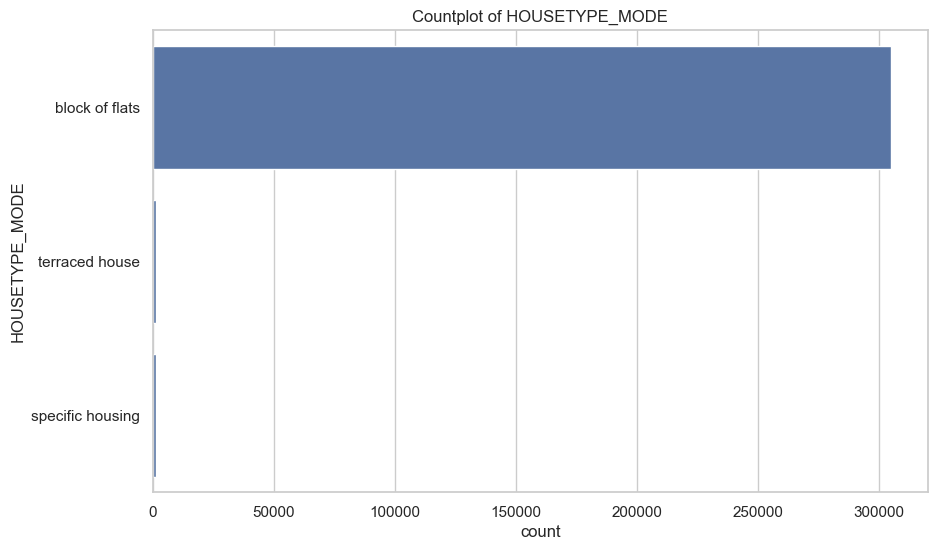

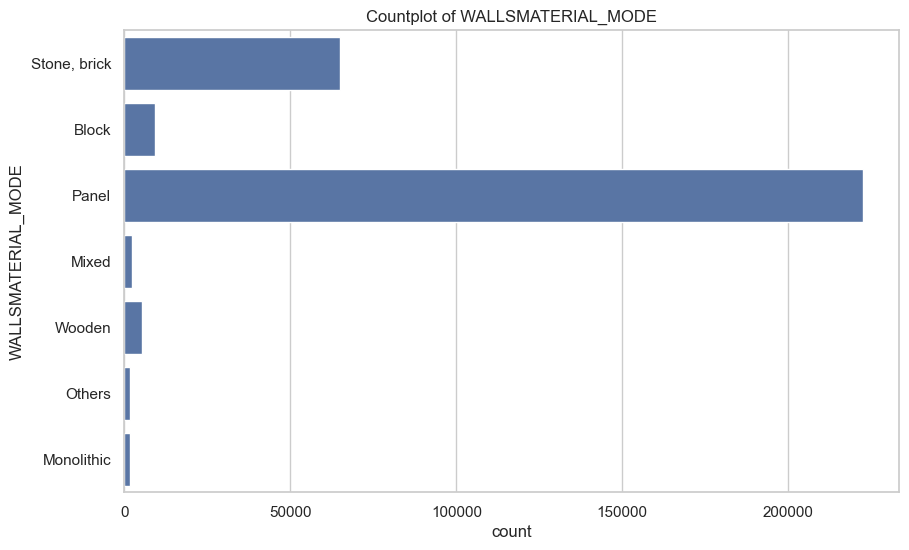

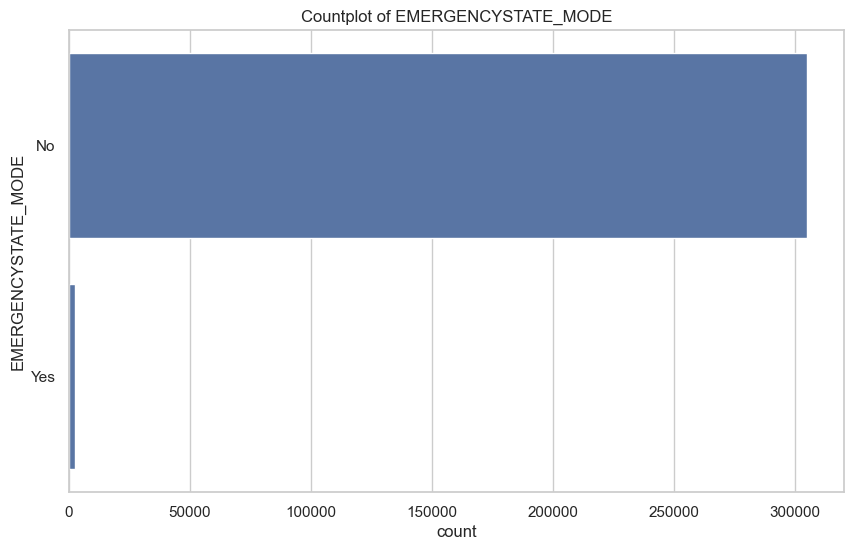

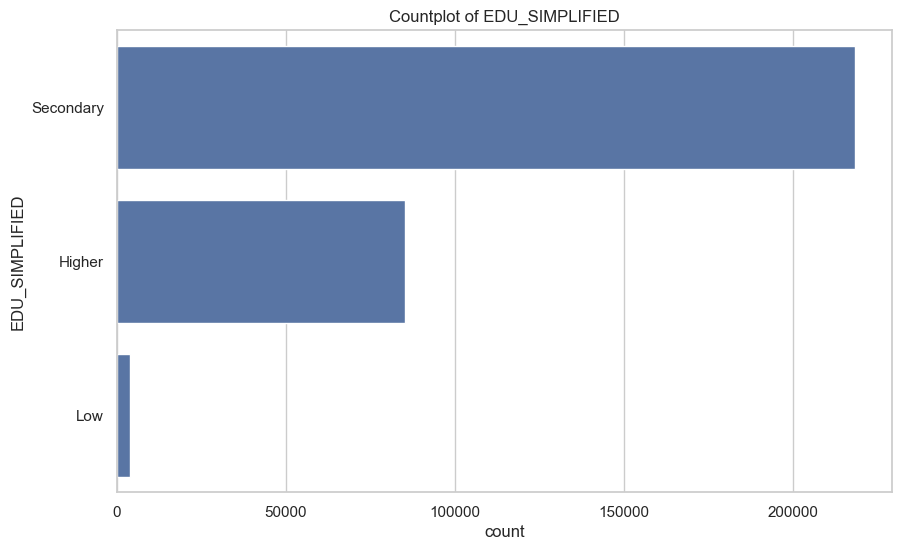

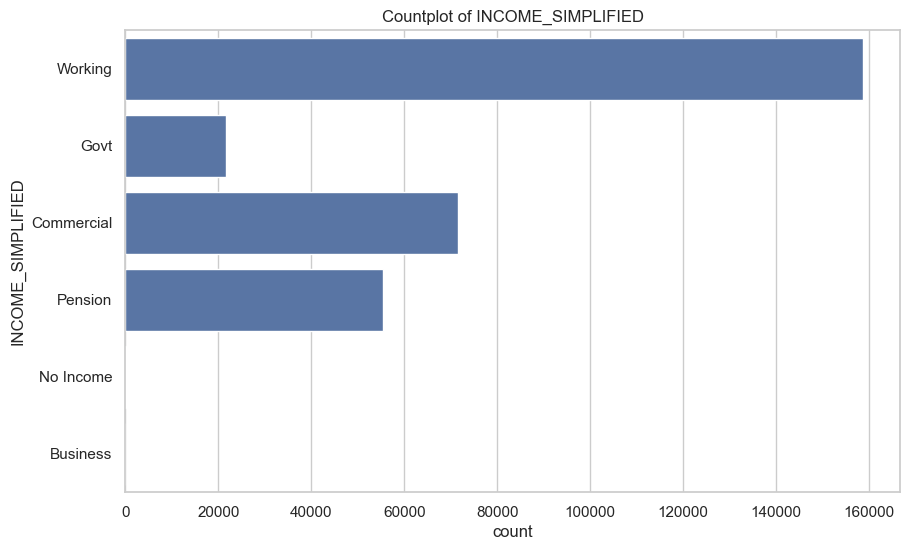

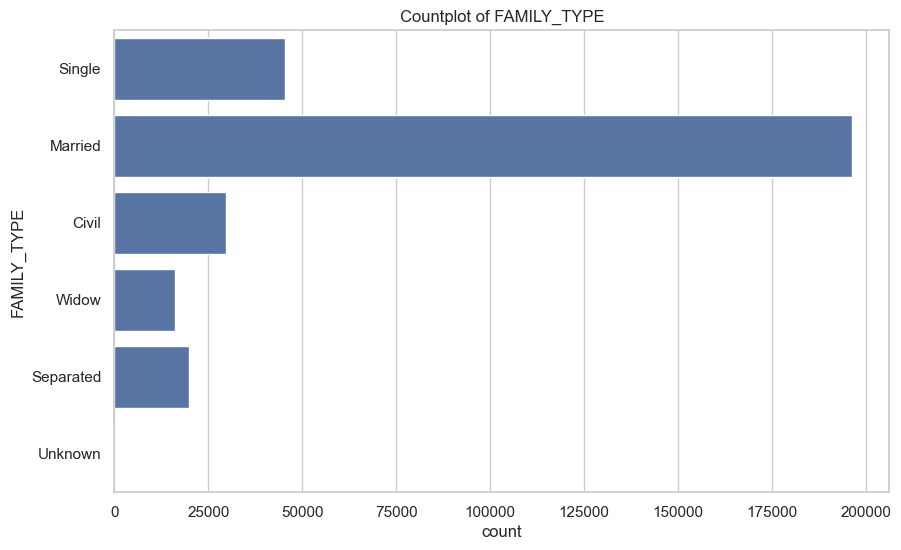

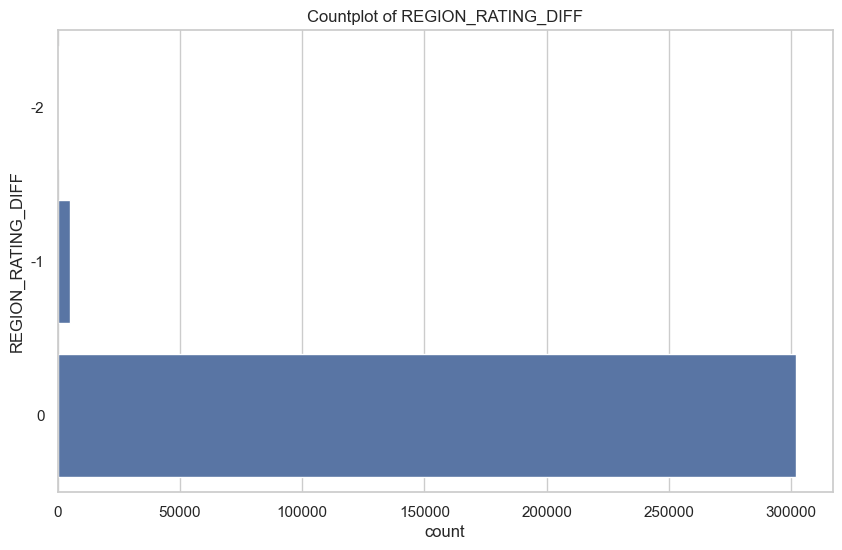

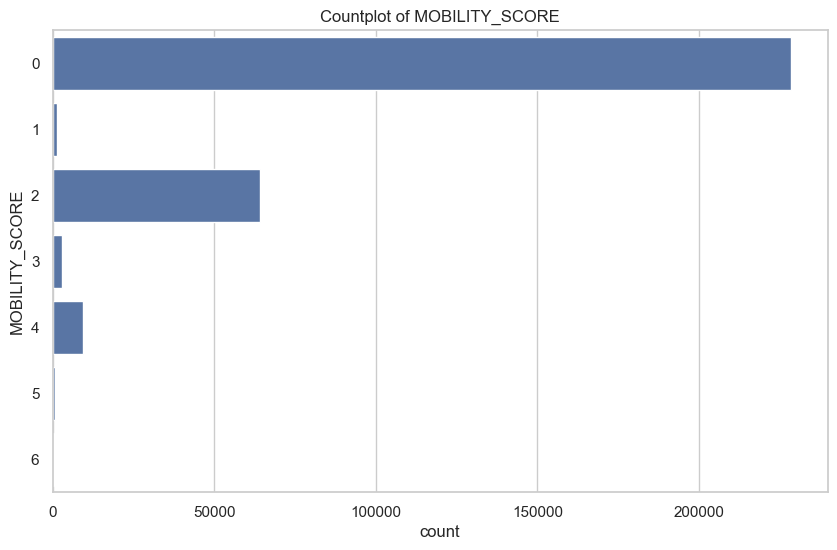

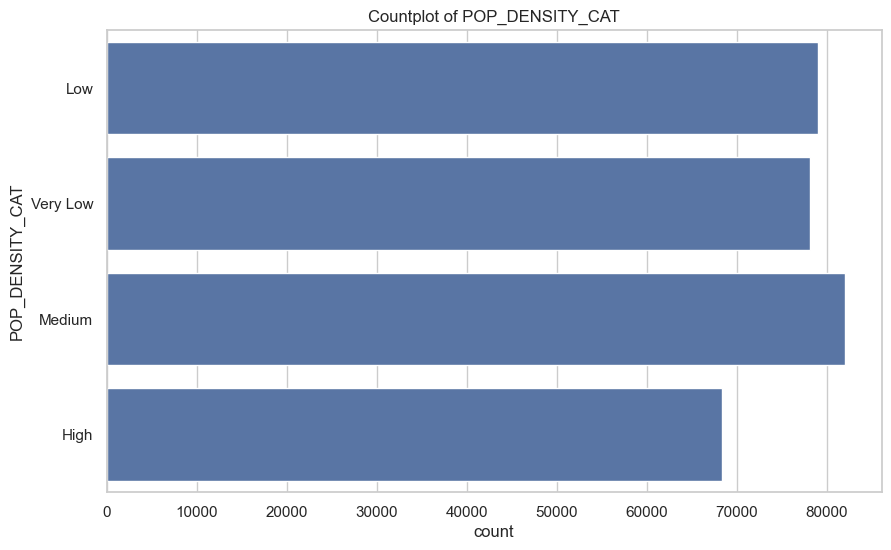

In [20]:
for col in cat_features:
    if col in df.columns:
        plt.figure()
        sns.countplot(y=col, data=df)
        plt.title(f'Countplot of {col}')
        plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"{col}_Countplot.png"), bbox_inches="tight", dpi=300)
        plt.show()

### Bivariate Analysis: Features vs TARGET

#### Numerical features vs TARGET

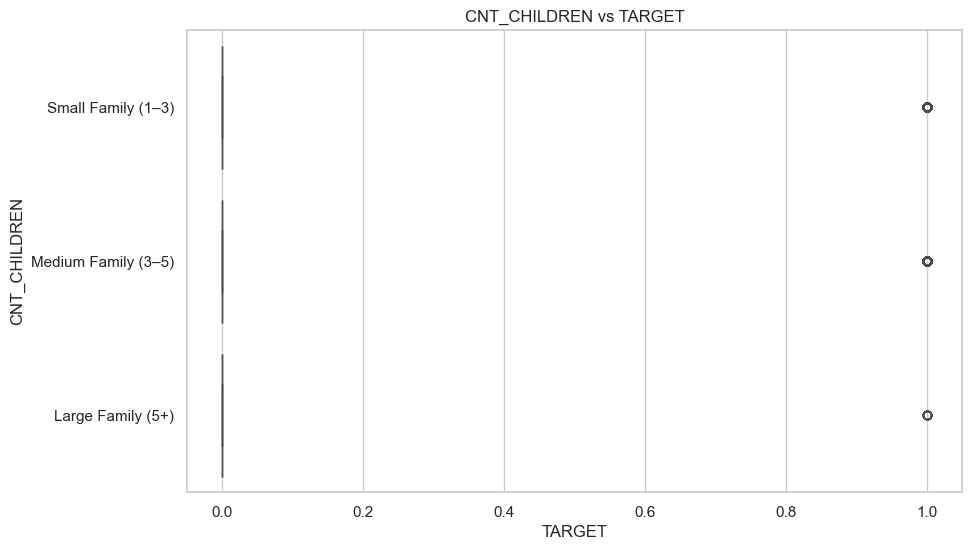

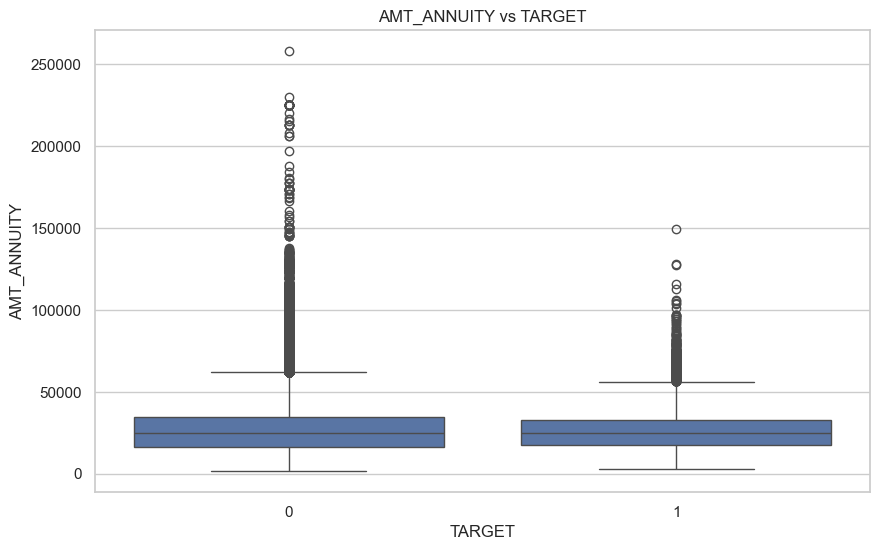

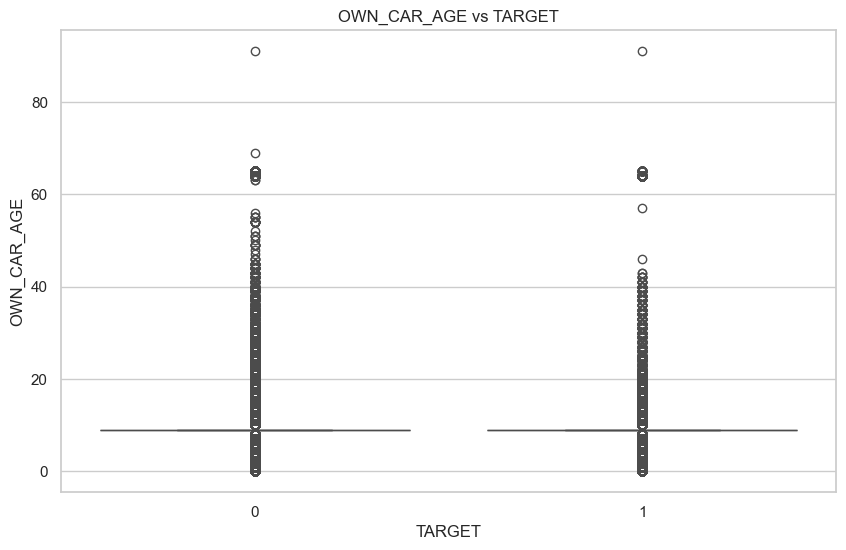

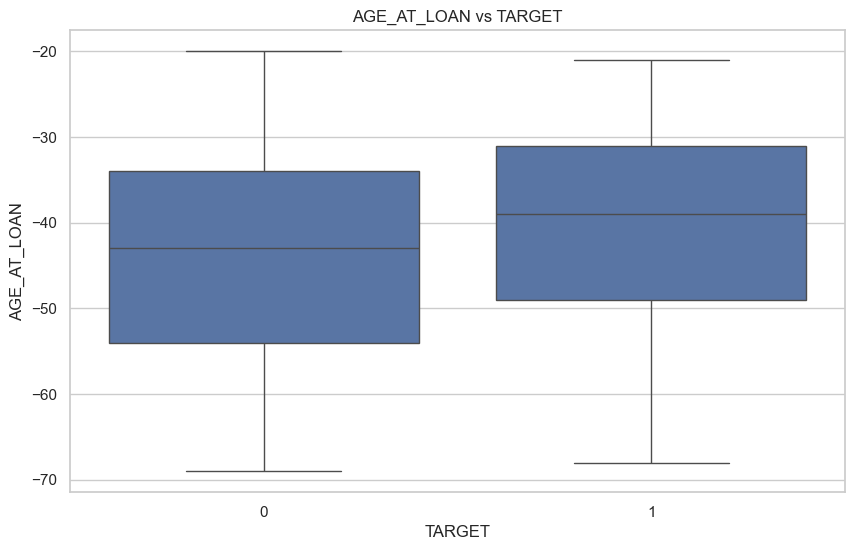

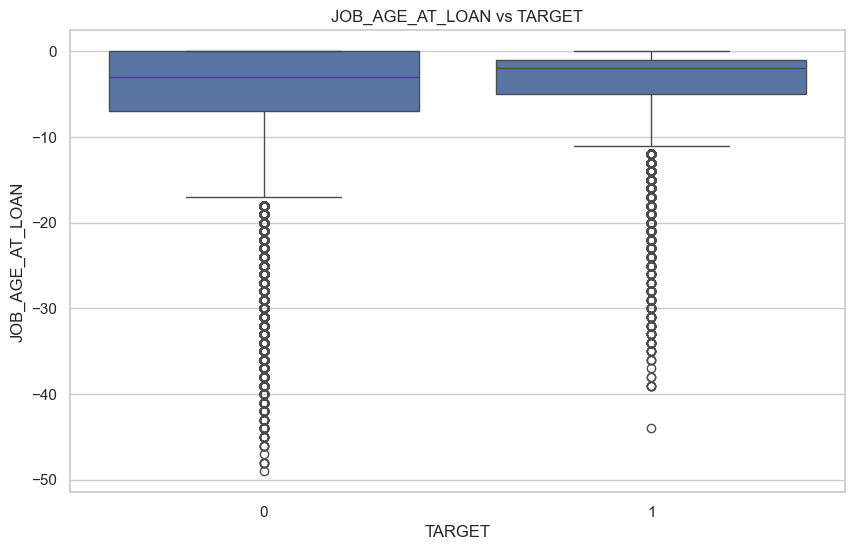

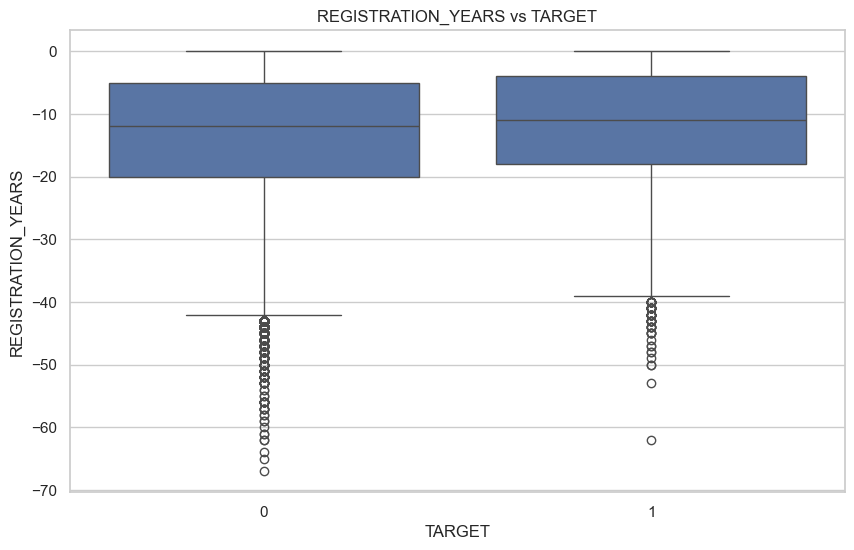

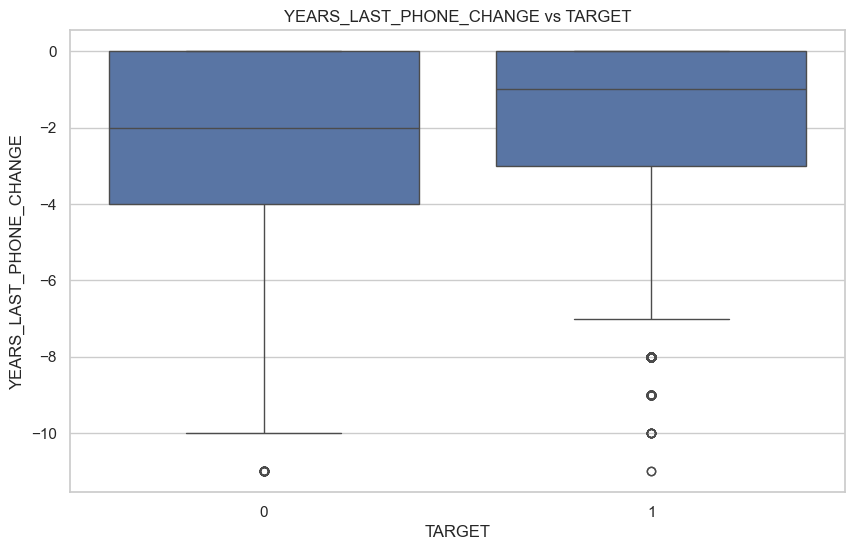

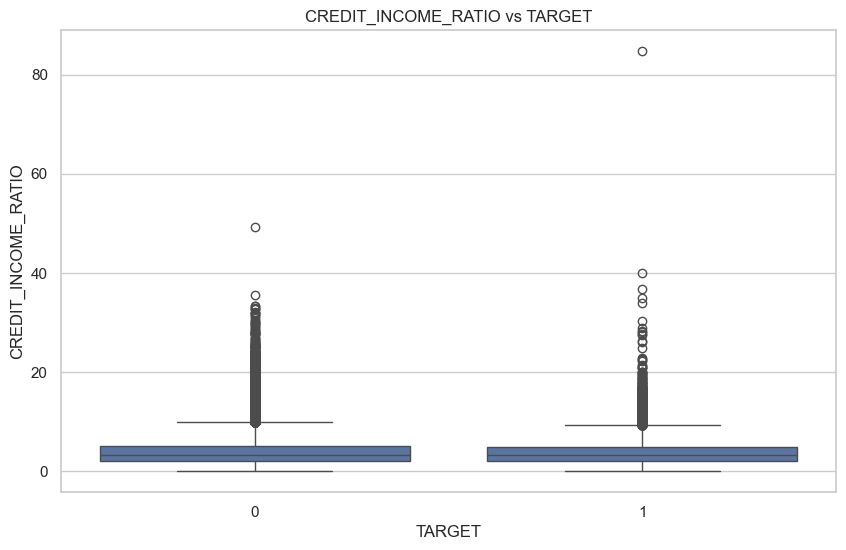

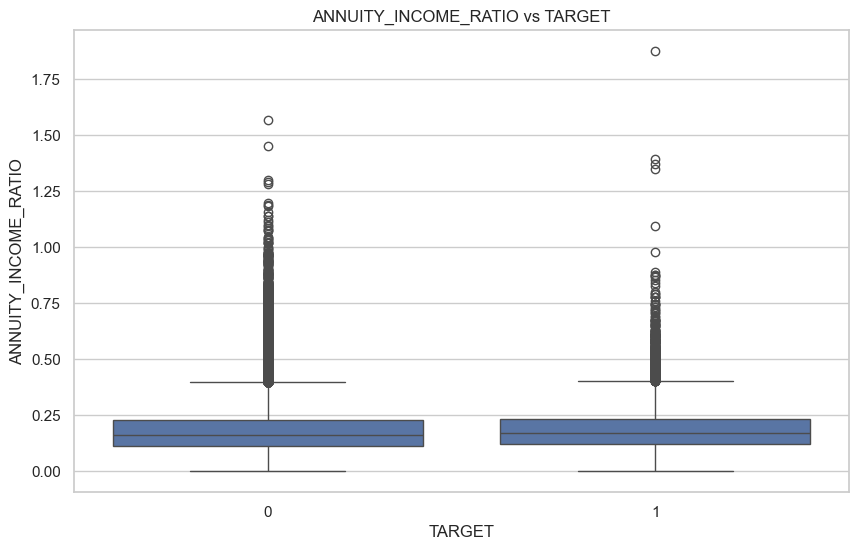

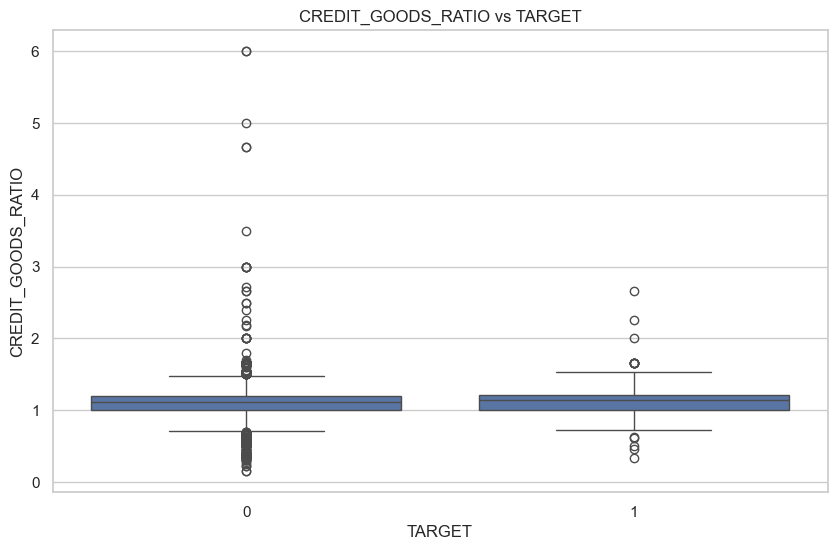

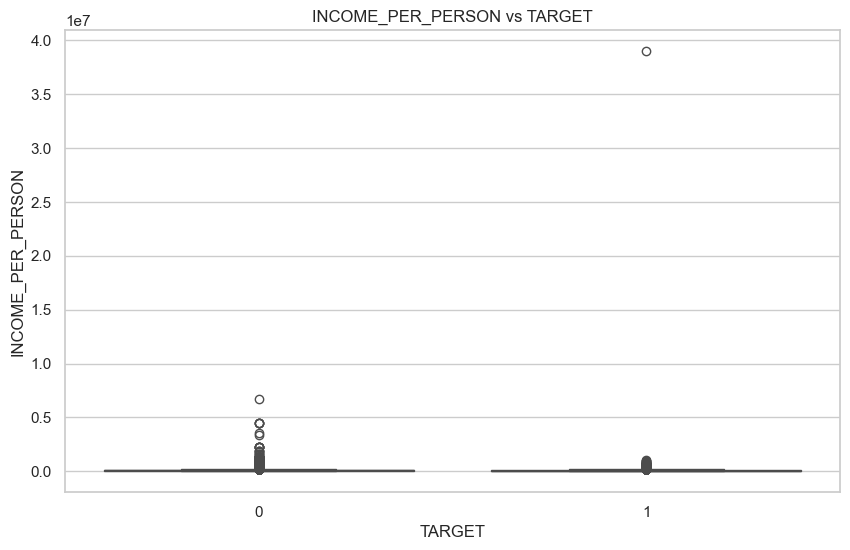

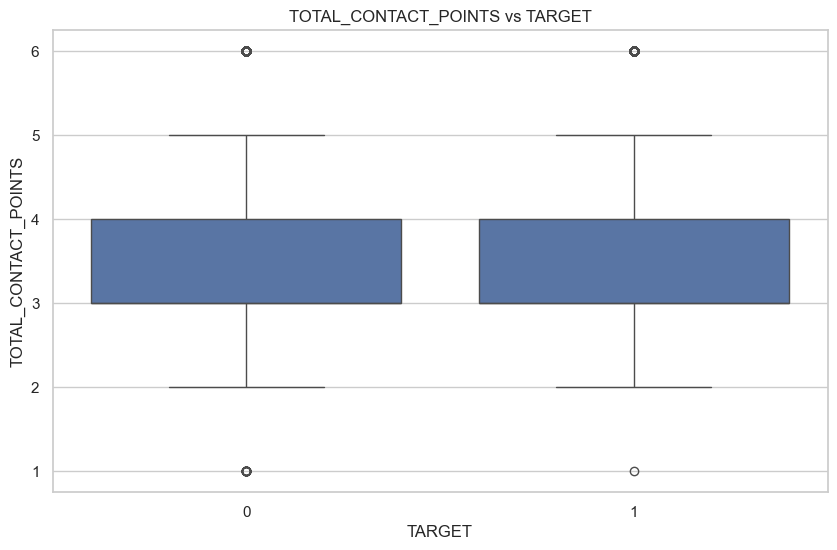

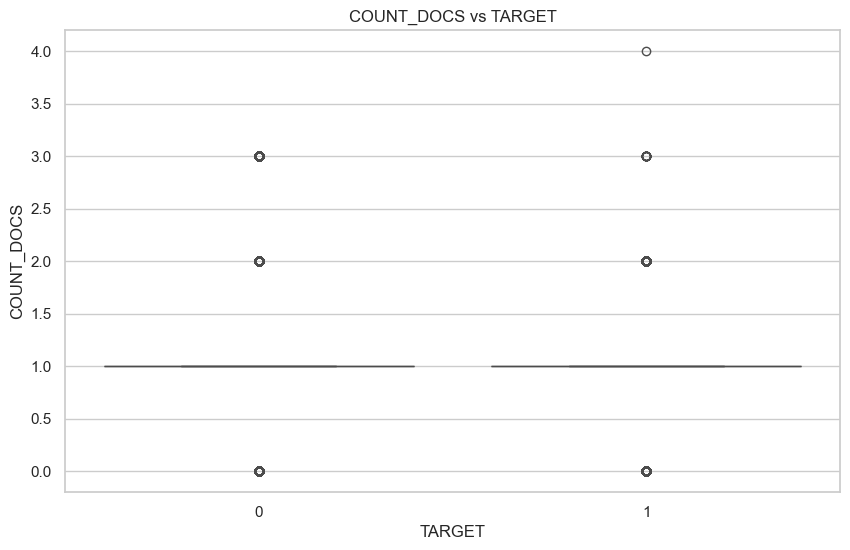

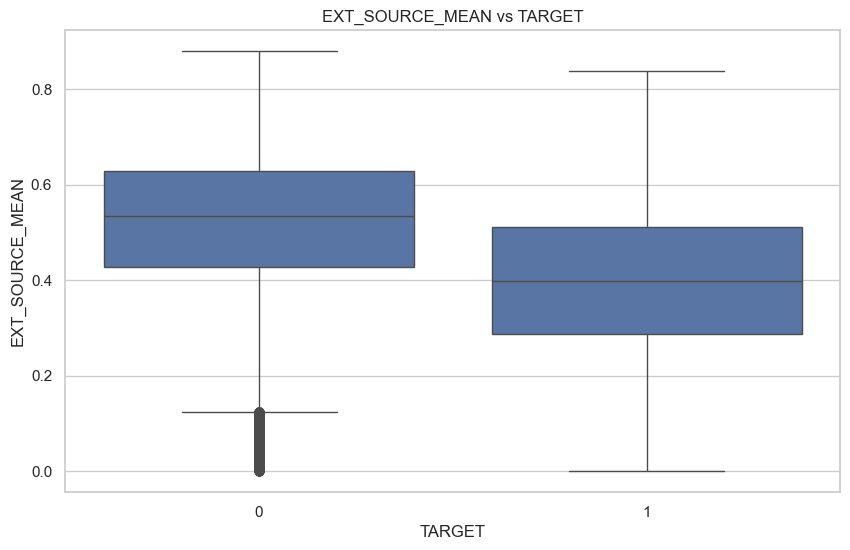

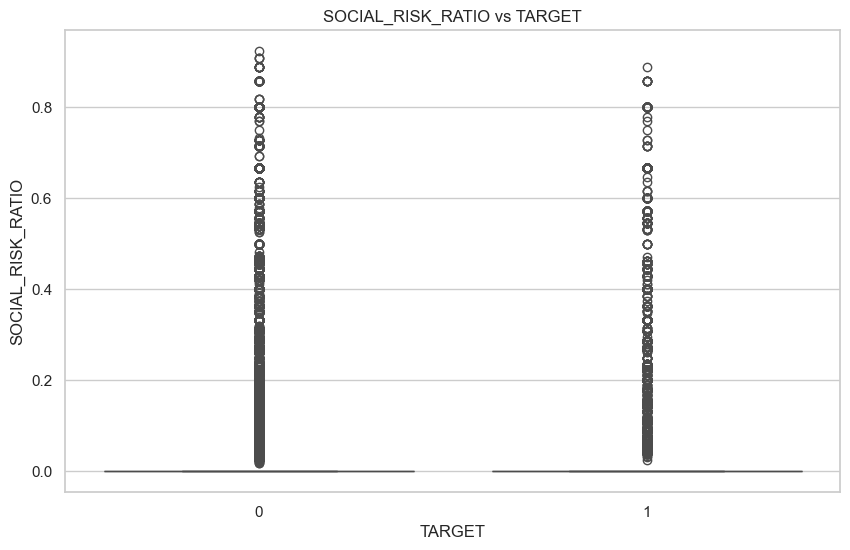

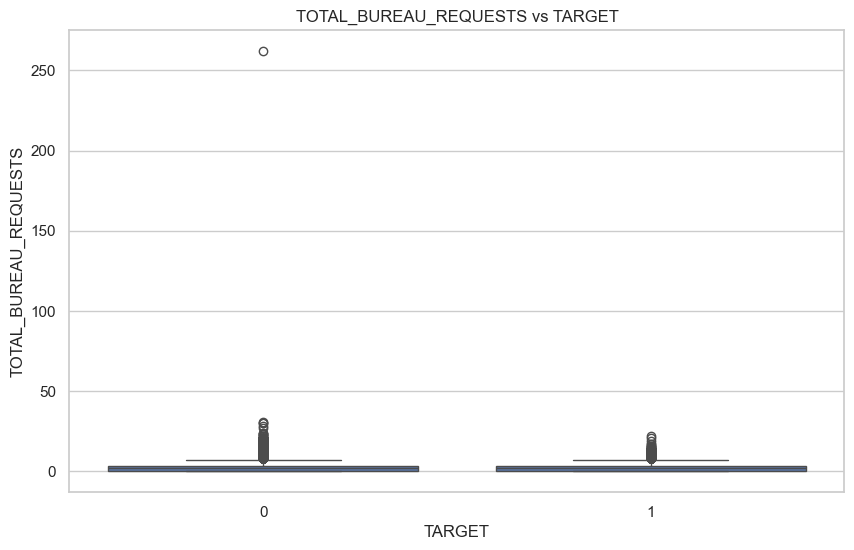

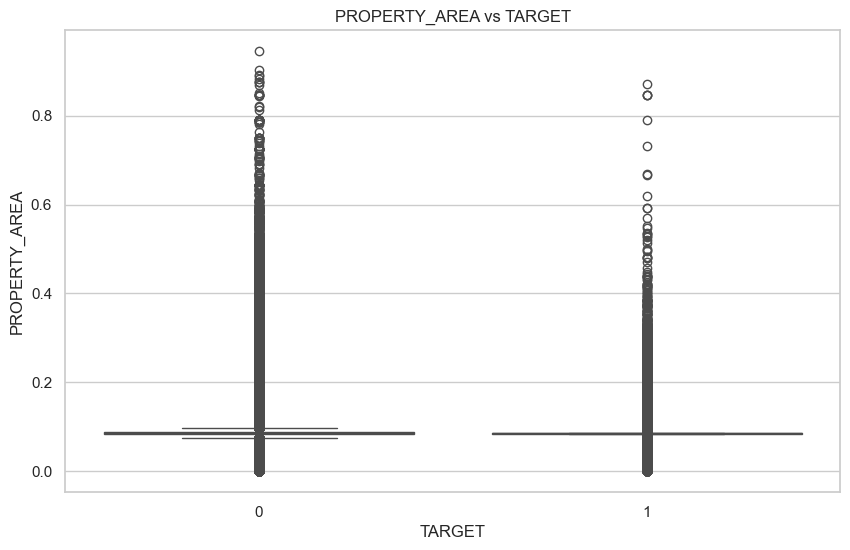

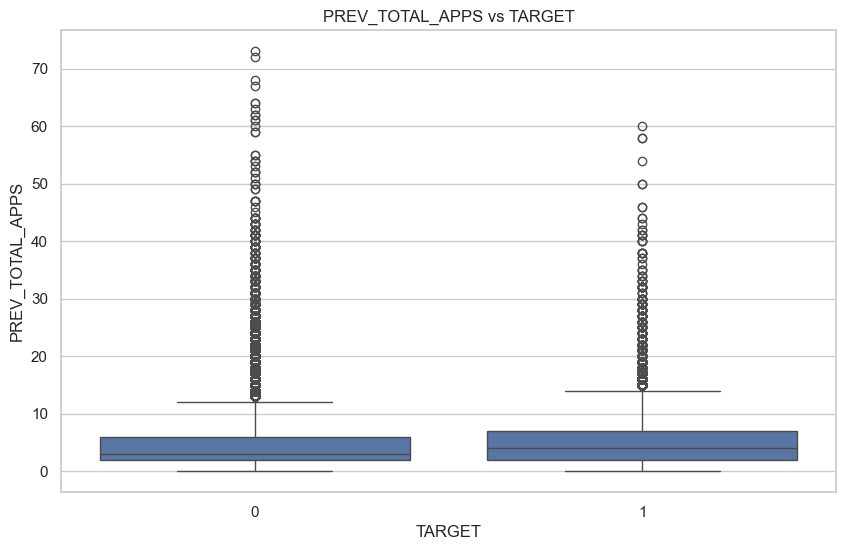

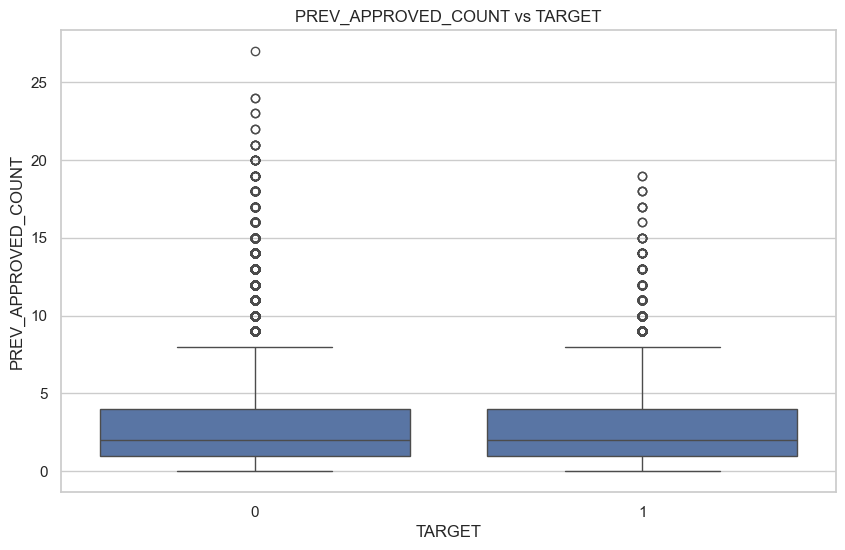

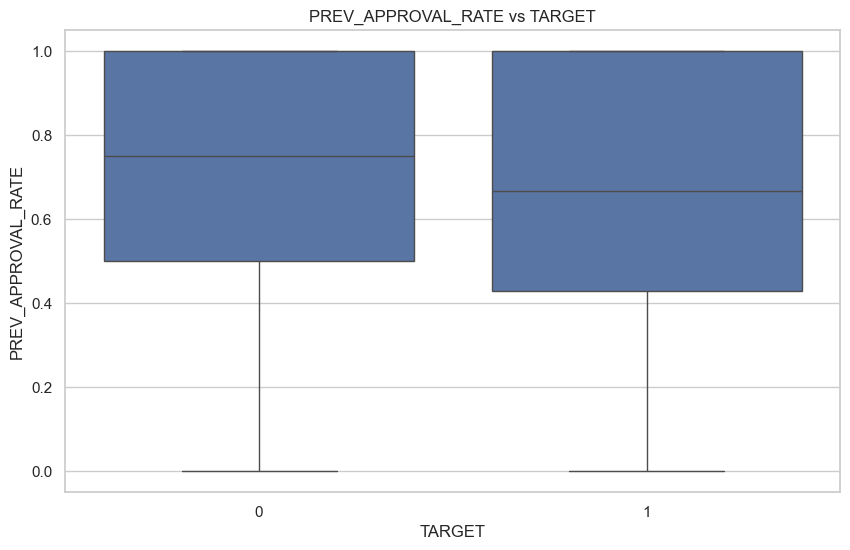

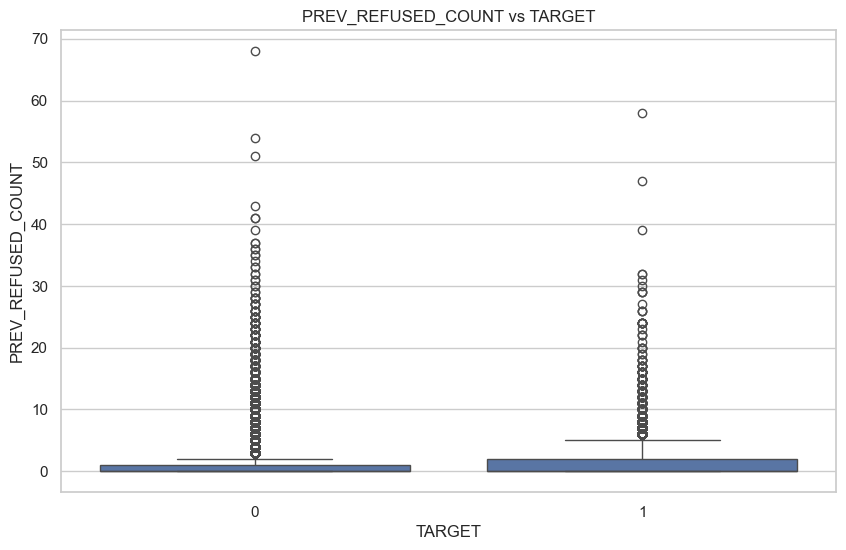

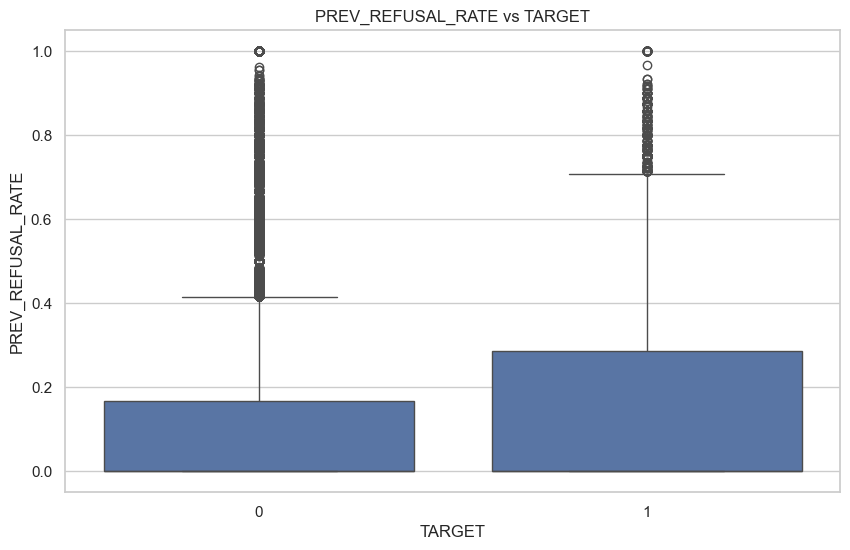

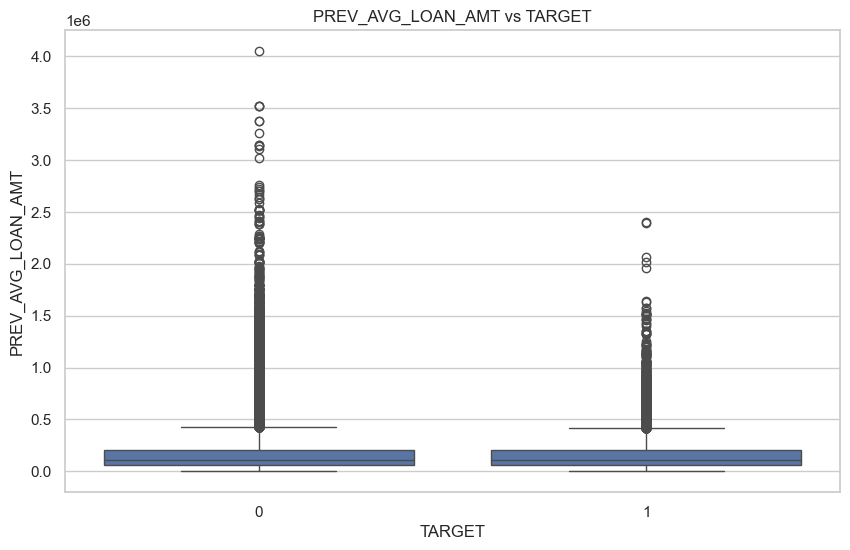

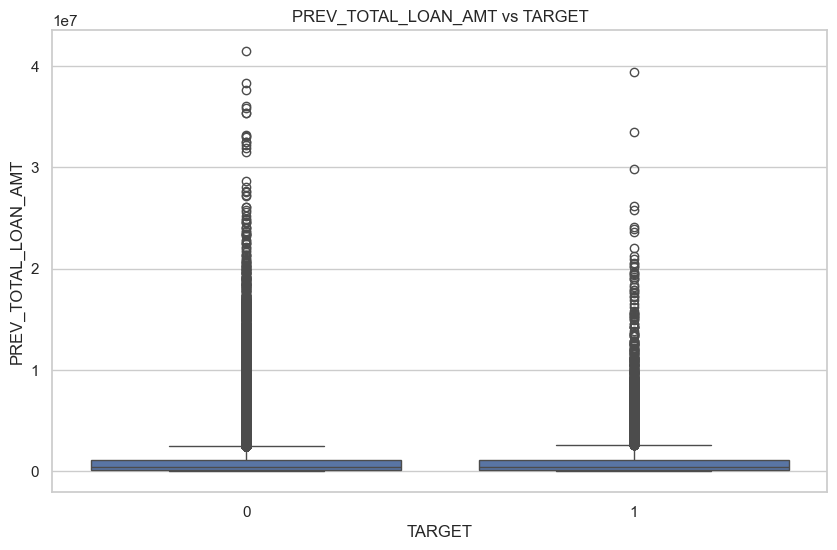

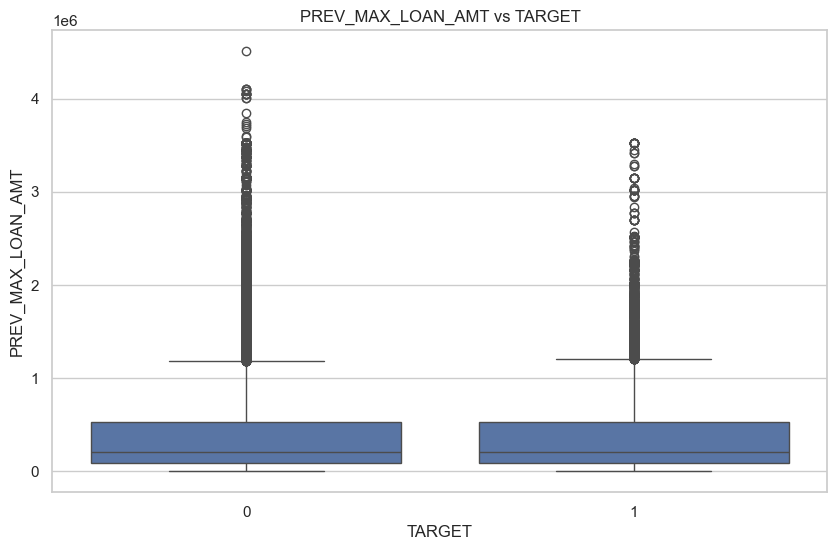

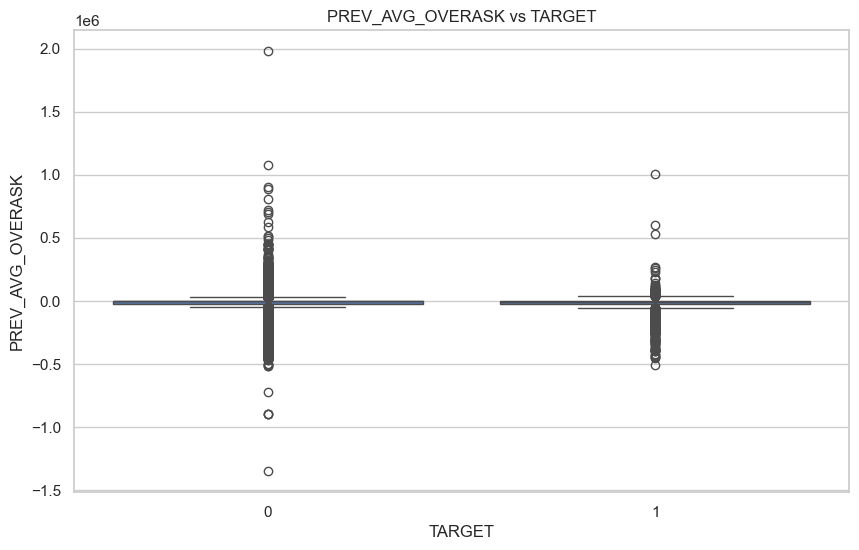

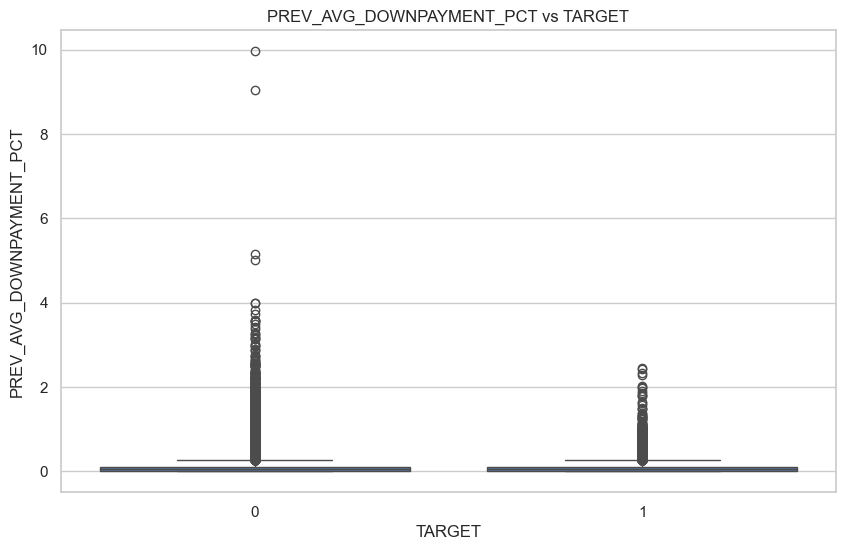

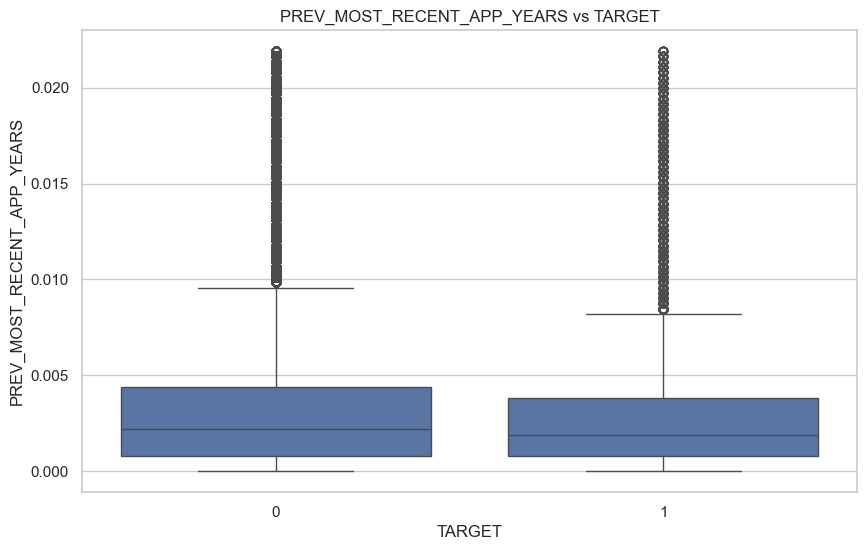

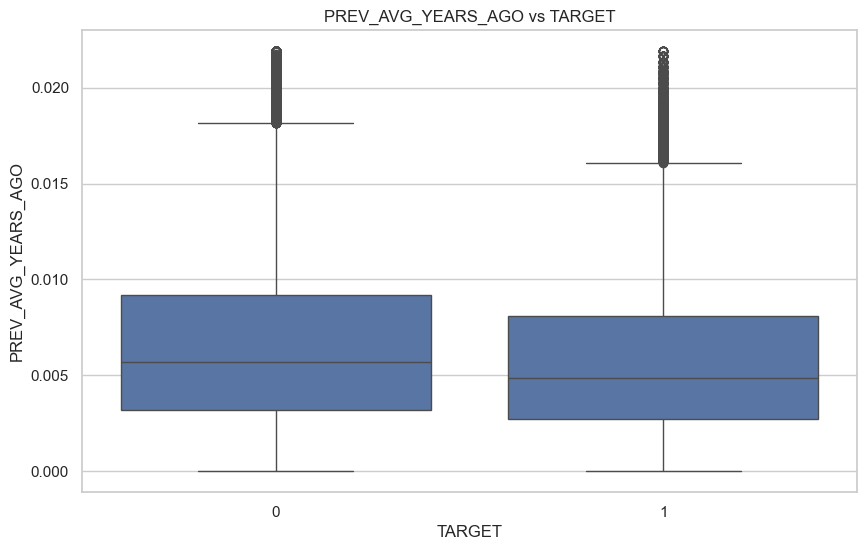

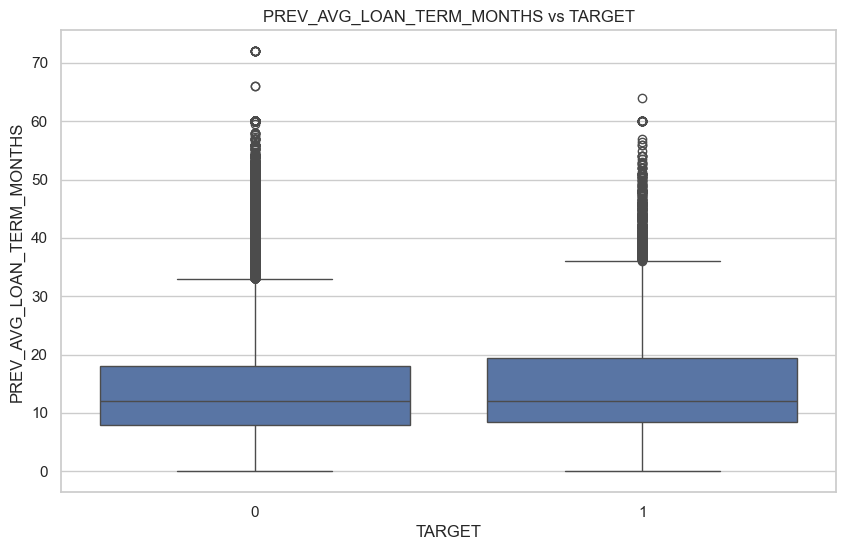

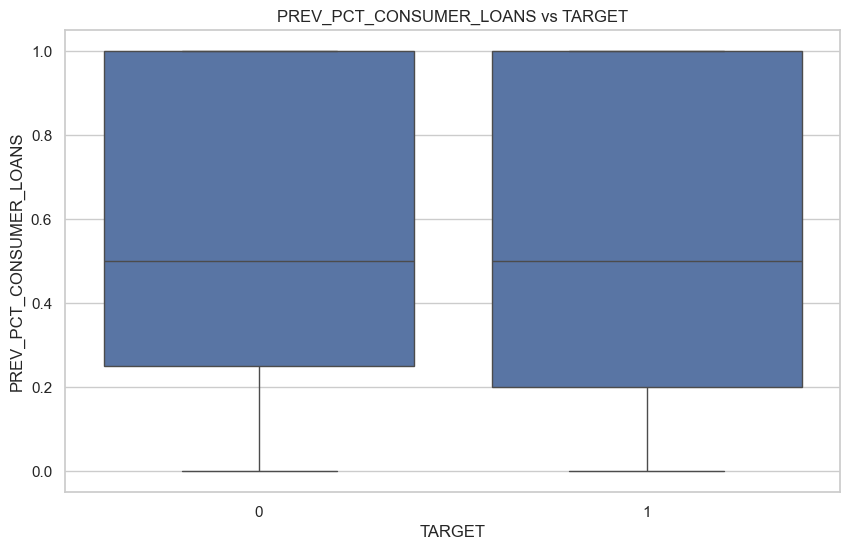

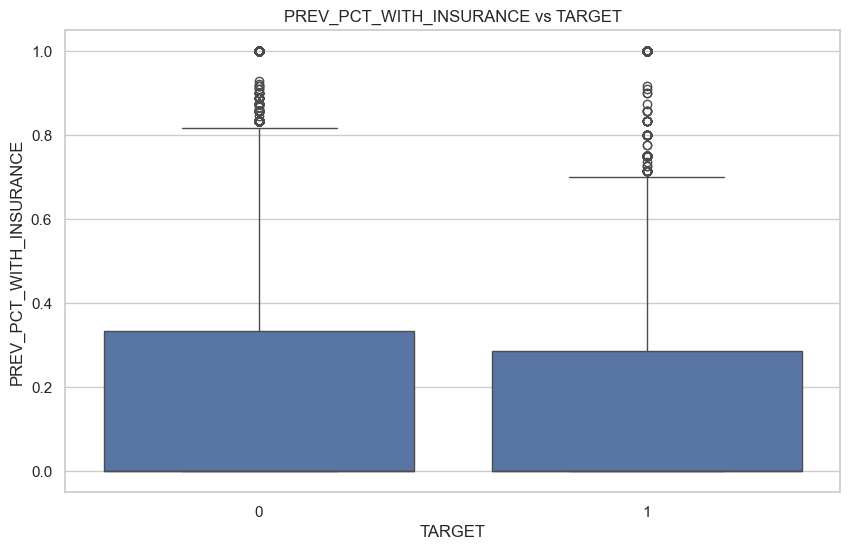

In [21]:
for col in num_features:
    if col in df.columns and col != 'TARGET':
        plt.figure()
        sns.boxplot(x='TARGET', y=col, data=df)
        plt.title(f'{col} vs TARGET')
        plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"countplot_{col}_vs_target.png"), bbox_inches="tight", dpi=300)
        plt.show()
        
        # # Statistical test: t-test for difference in means
        # group0 = df[df['TARGET'] == 0][col]
        # group1 = df[df['TARGET'] == 1][col]
        # t_stat, p_val = stats.ttest_ind(group0, group1, nan_policy='omit')
        # print(f'{col} vs TARGET: t-stat={t_stat:.2f}, p-value={p_val:.4f}')


#### Categorical features vs TARGET

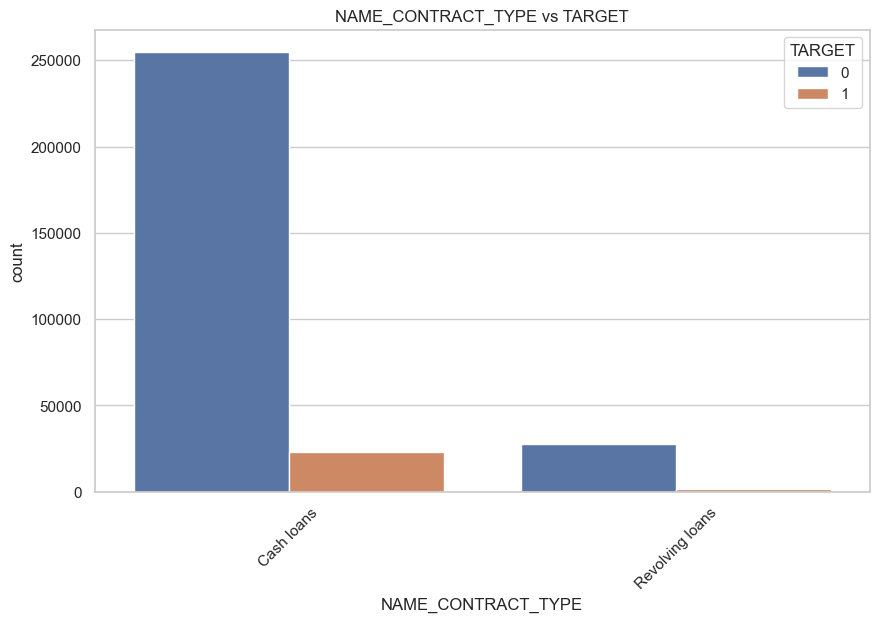

NAME_CONTRACT_TYPE vs TARGET: chi2=293.15, p-value=0.0000


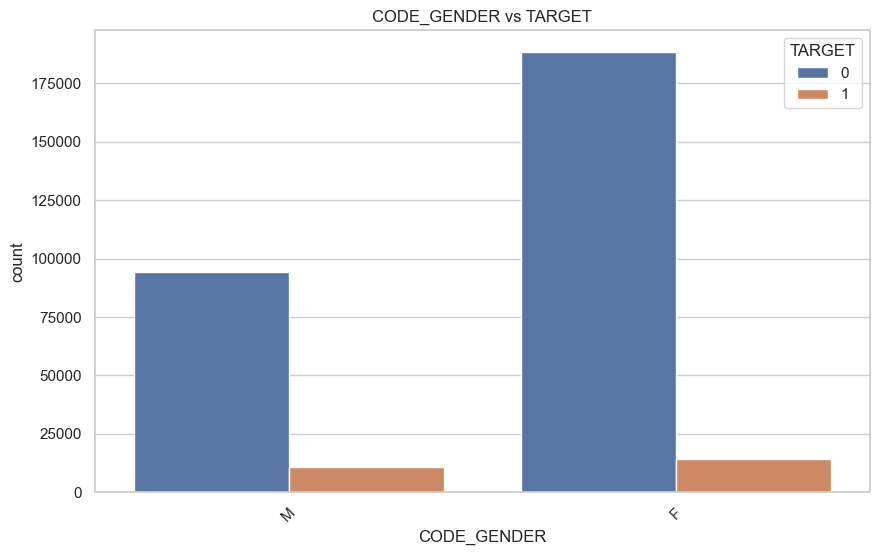

CODE_GENDER vs TARGET: chi2=920.10, p-value=0.0000


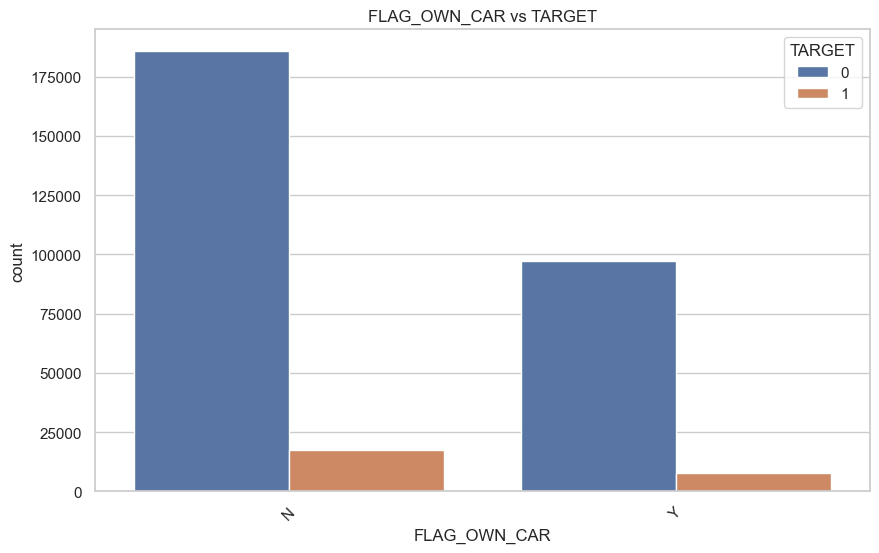

FLAG_OWN_CAR vs TARGET: chi2=146.66, p-value=0.0000


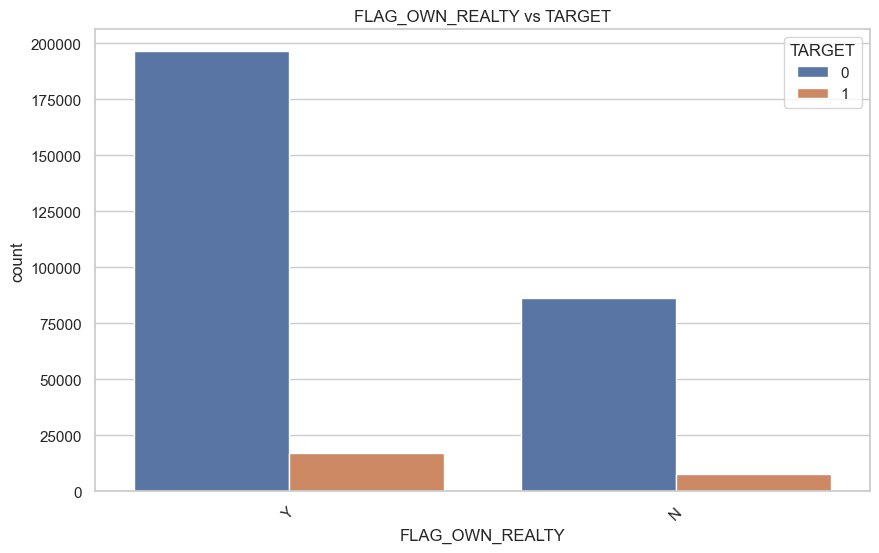

FLAG_OWN_REALTY vs TARGET: chi2=11.58, p-value=0.0007


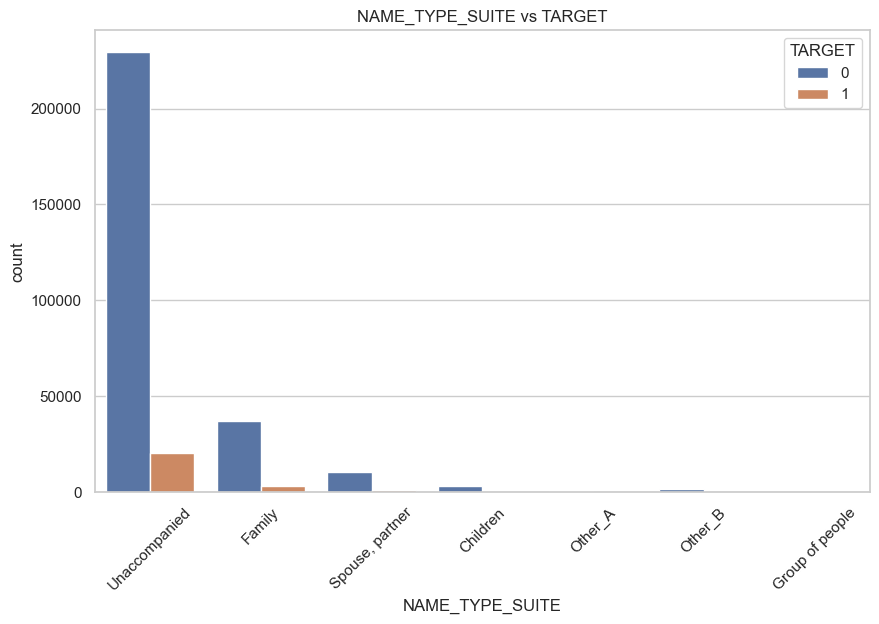

NAME_TYPE_SUITE vs TARGET: chi2=31.95, p-value=0.0000


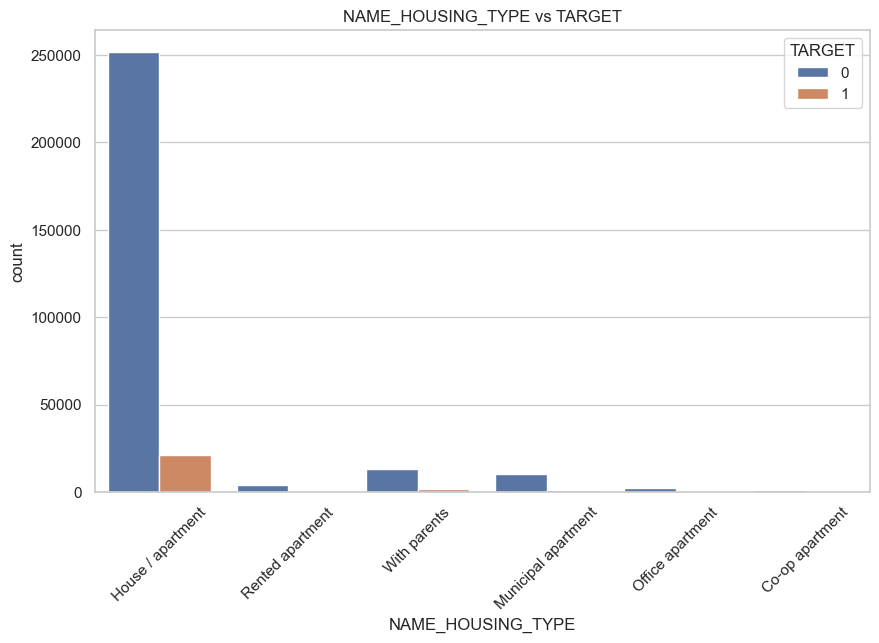

NAME_HOUSING_TYPE vs TARGET: chi2=420.56, p-value=0.0000


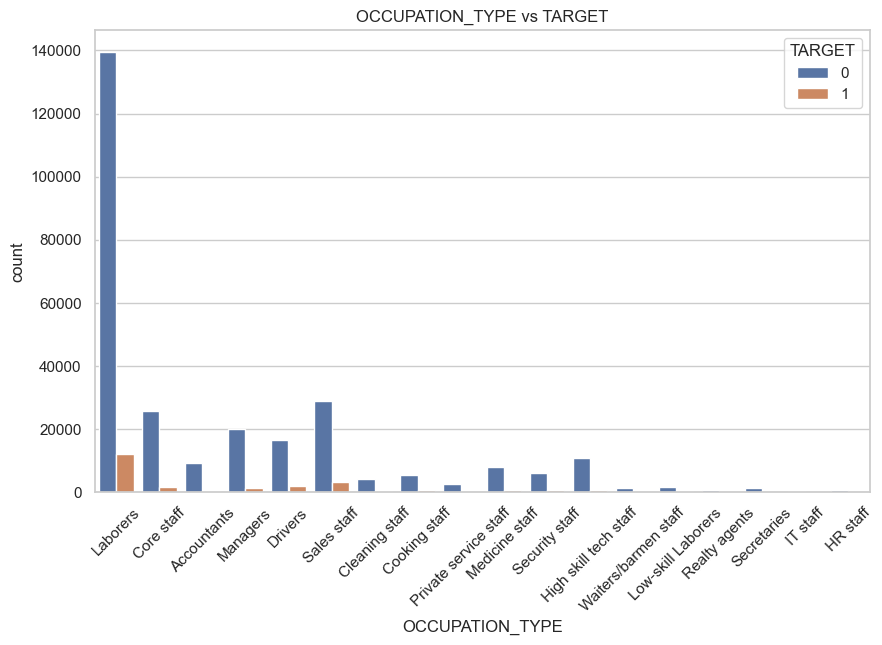

OCCUPATION_TYPE vs TARGET: chi2=1193.39, p-value=0.0000


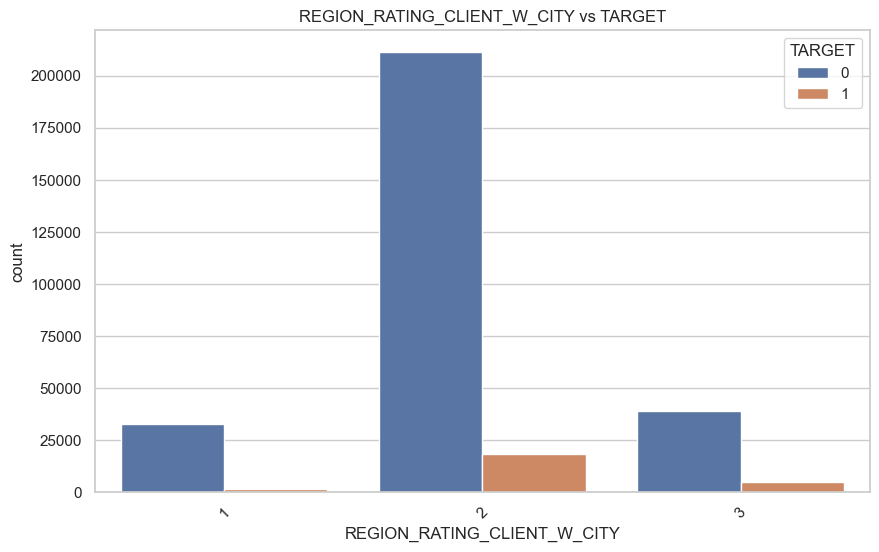

REGION_RATING_CLIENT_W_CITY vs TARGET: chi2=1143.45, p-value=0.0000


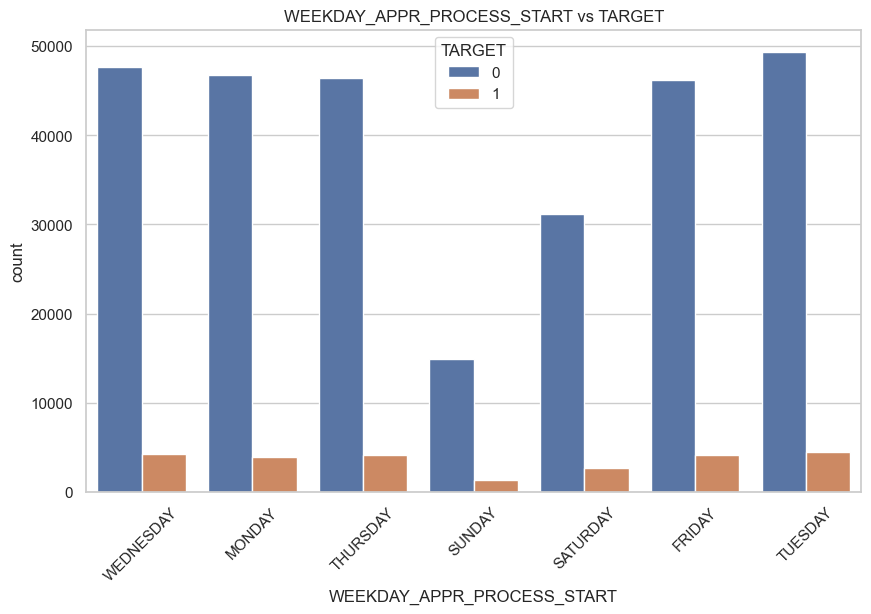

WEEKDAY_APPR_PROCESS_START vs TARGET: chi2=15.39, p-value=0.0174


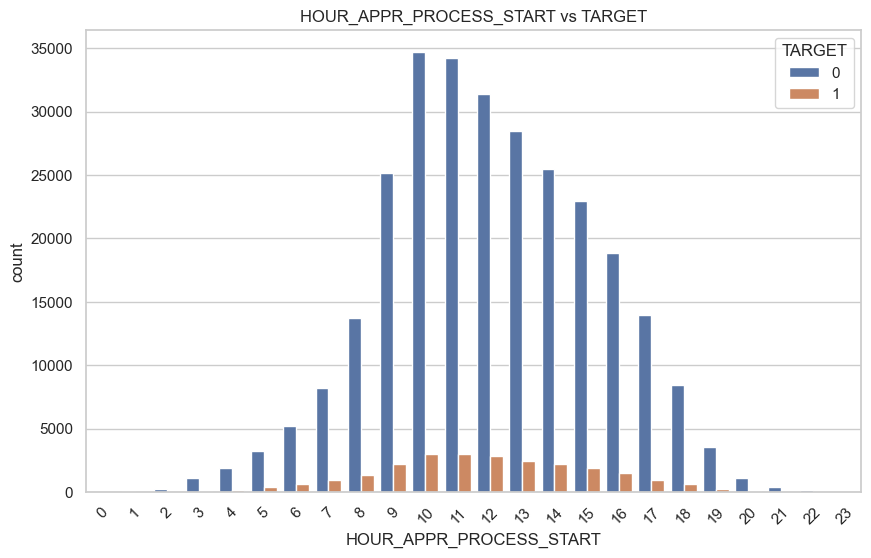

HOUR_APPR_PROCESS_START vs TARGET: chi2=271.53, p-value=0.0000


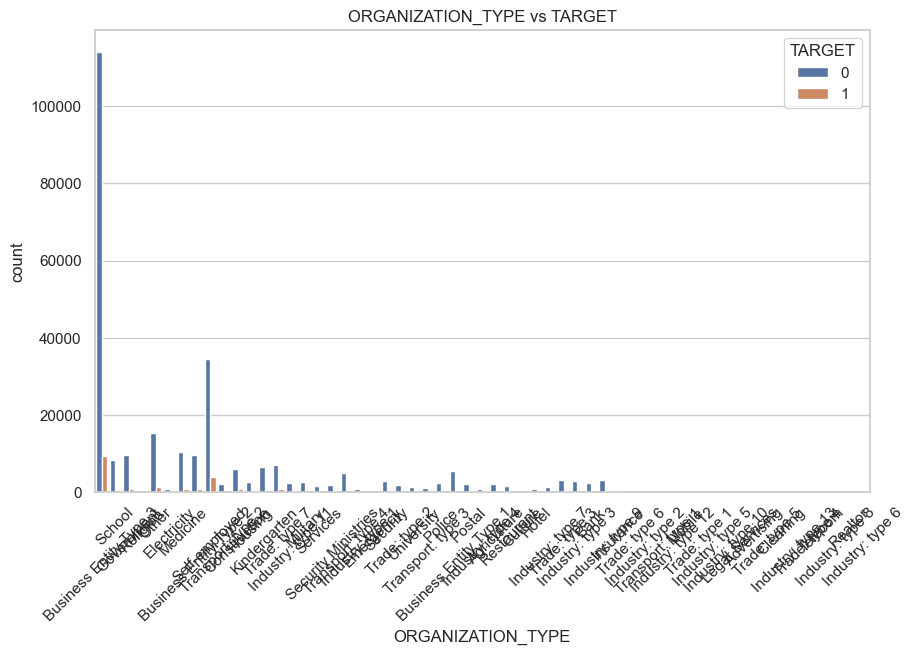

ORGANIZATION_TYPE vs TARGET: chi2=983.75, p-value=0.0000


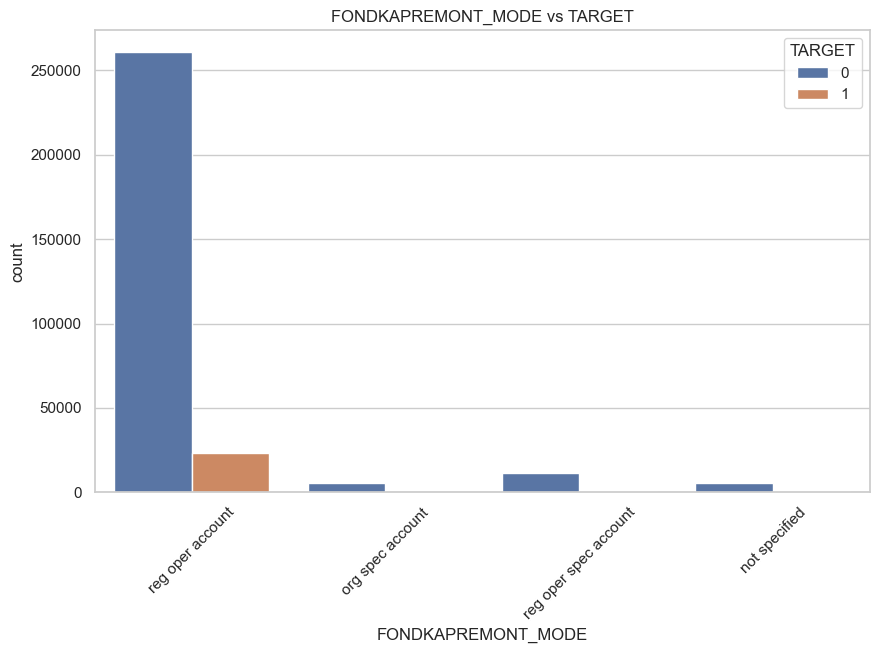

FONDKAPREMONT_MODE vs TARGET: chi2=83.51, p-value=0.0000


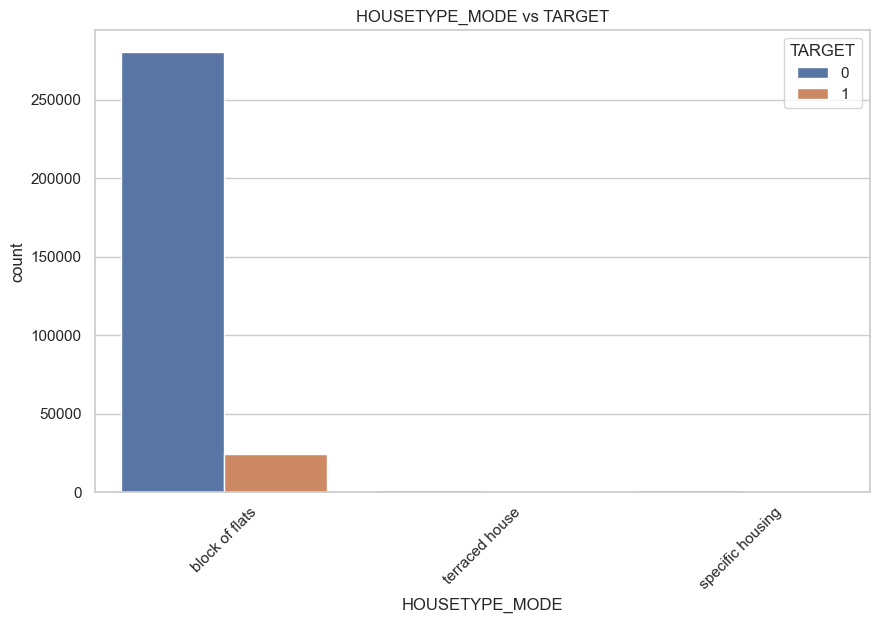

HOUSETYPE_MODE vs TARGET: chi2=8.99, p-value=0.0112


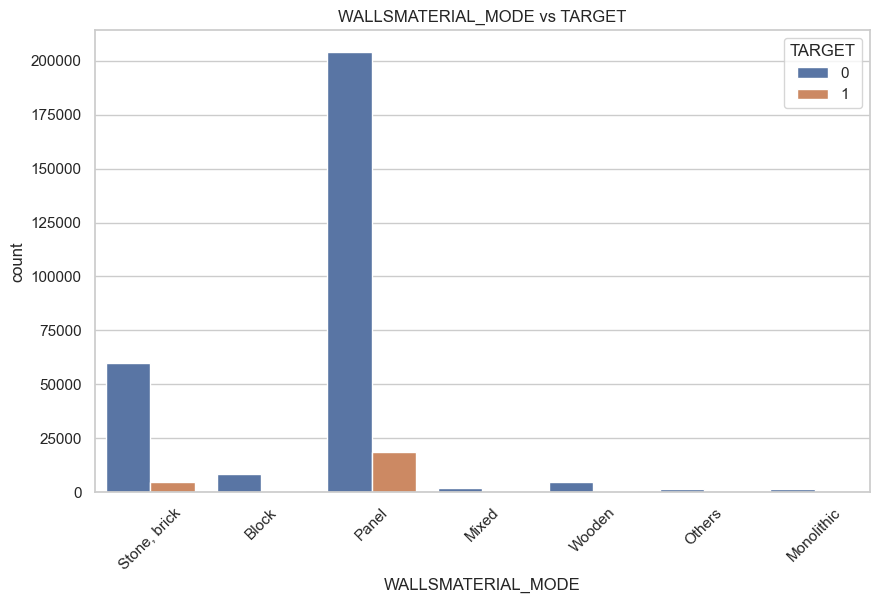

WALLSMATERIAL_MODE vs TARGET: chi2=115.38, p-value=0.0000


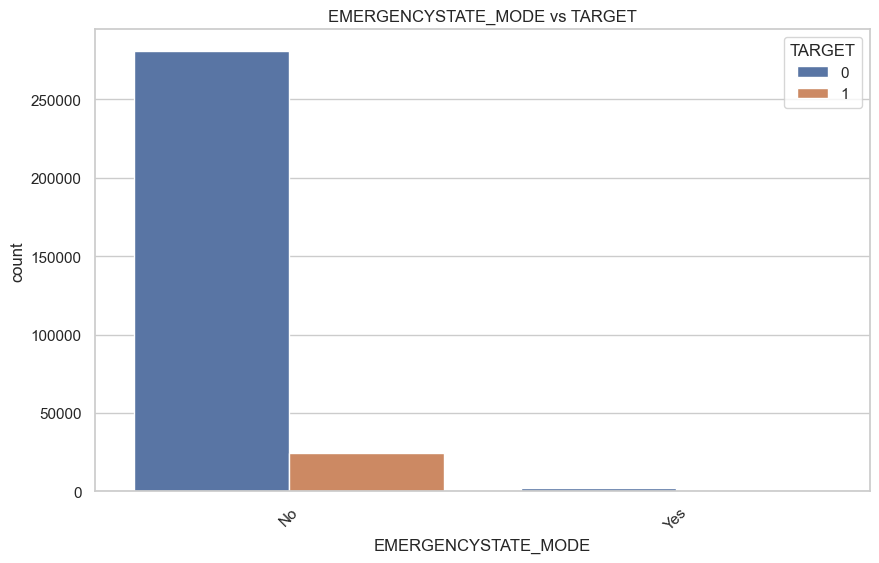

EMERGENCYSTATE_MODE vs TARGET: chi2=6.97, p-value=0.0083


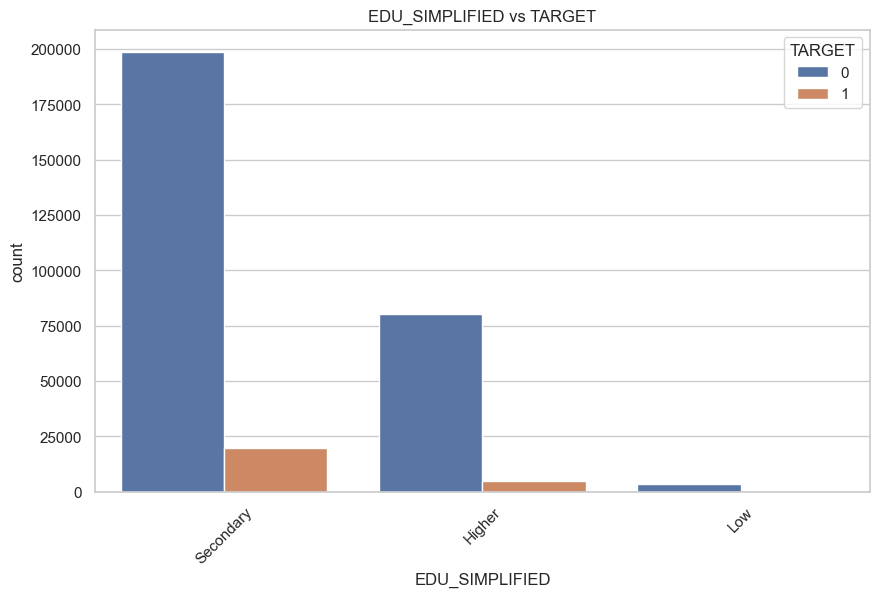

EDU_SIMPLIFIED vs TARGET: chi2=896.57, p-value=0.0000


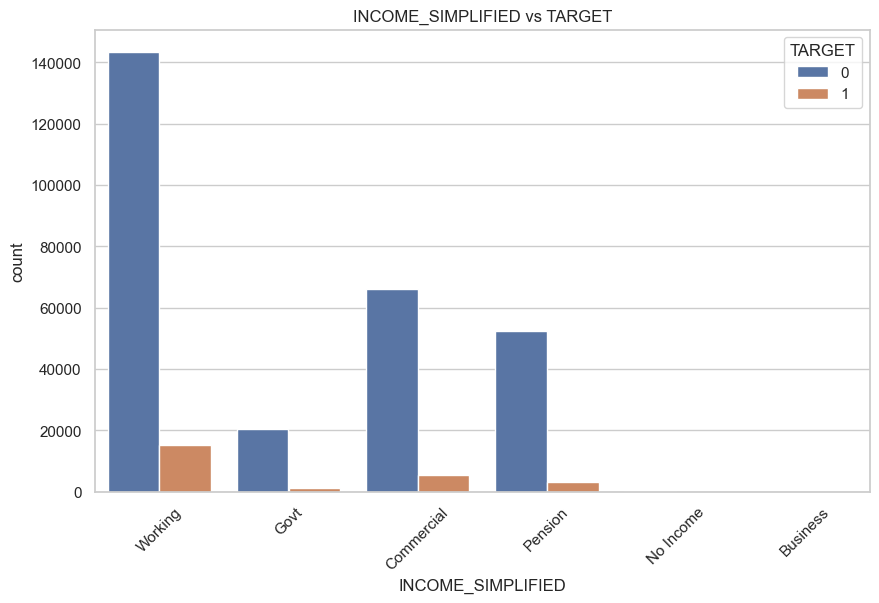

INCOME_SIMPLIFIED vs TARGET: chi2=1233.44, p-value=0.0000


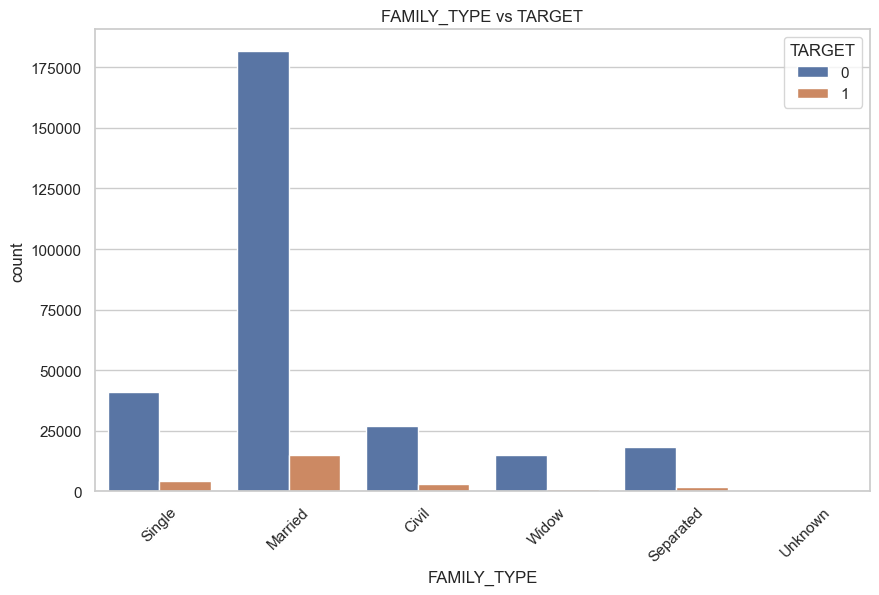

FAMILY_TYPE vs TARGET: chi2=504.69, p-value=0.0000


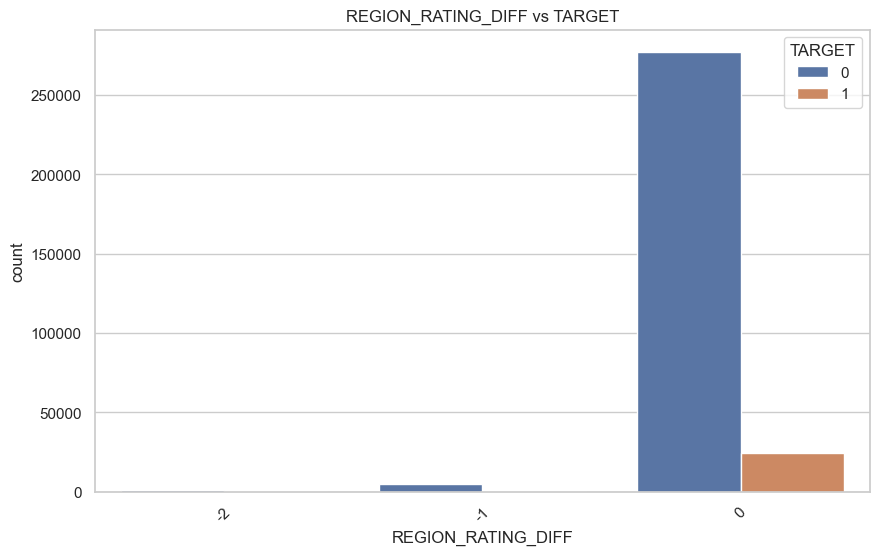

REGION_RATING_DIFF vs TARGET: chi2=5.77, p-value=0.0559


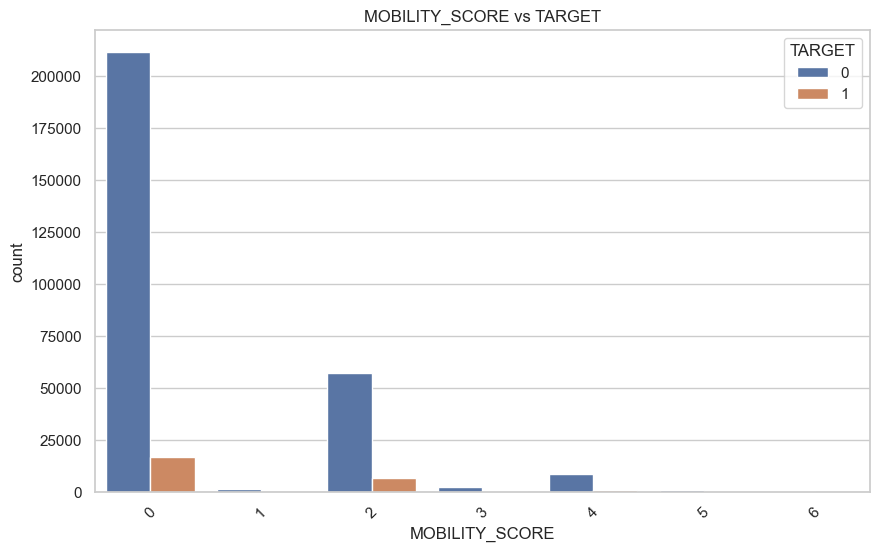

MOBILITY_SCORE vs TARGET: chi2=732.32, p-value=0.0000


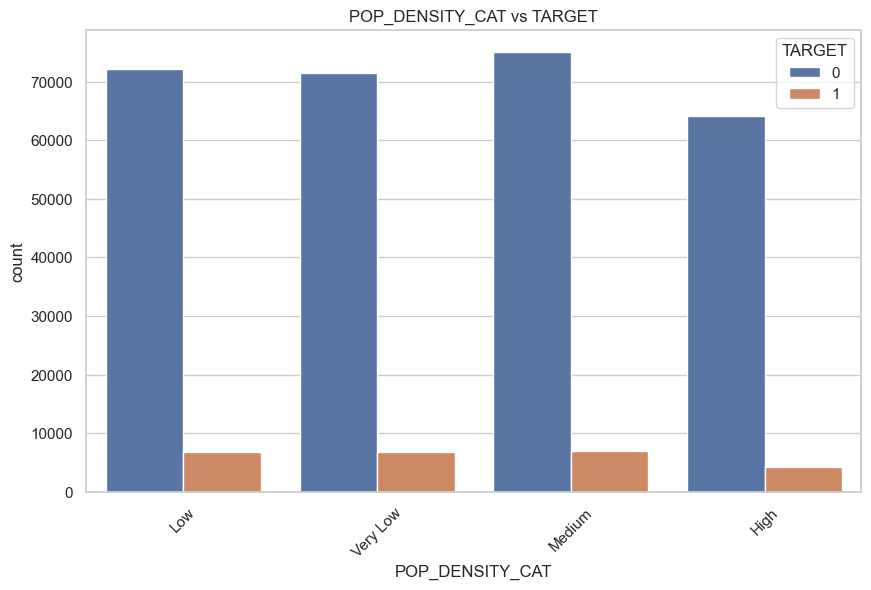

POP_DENSITY_CAT vs TARGET: chi2=368.61, p-value=0.0000


In [22]:
for col in cat_features:
    if col in df.columns:
        plt.figure()
        sns.countplot(x=col, hue='TARGET', data=df)
        plt.title(f'{col} vs TARGET')
        plt.xticks(rotation=45)
        plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"countplot_{col}_vs_target.png"), bbox_inches="tight", dpi=300)
        plt.show()
        
        # Chi-square test for independence
        contingency = pd.crosstab(df[col], df['TARGET'])
        chi2, p_val, _, _ = stats.chi2_contingency(contingency)
        print(f'{col} vs TARGET: chi2={chi2:.2f}, p-value={p_val:.4f}')

### Correlation Analysis

Number of numerical columns: 49


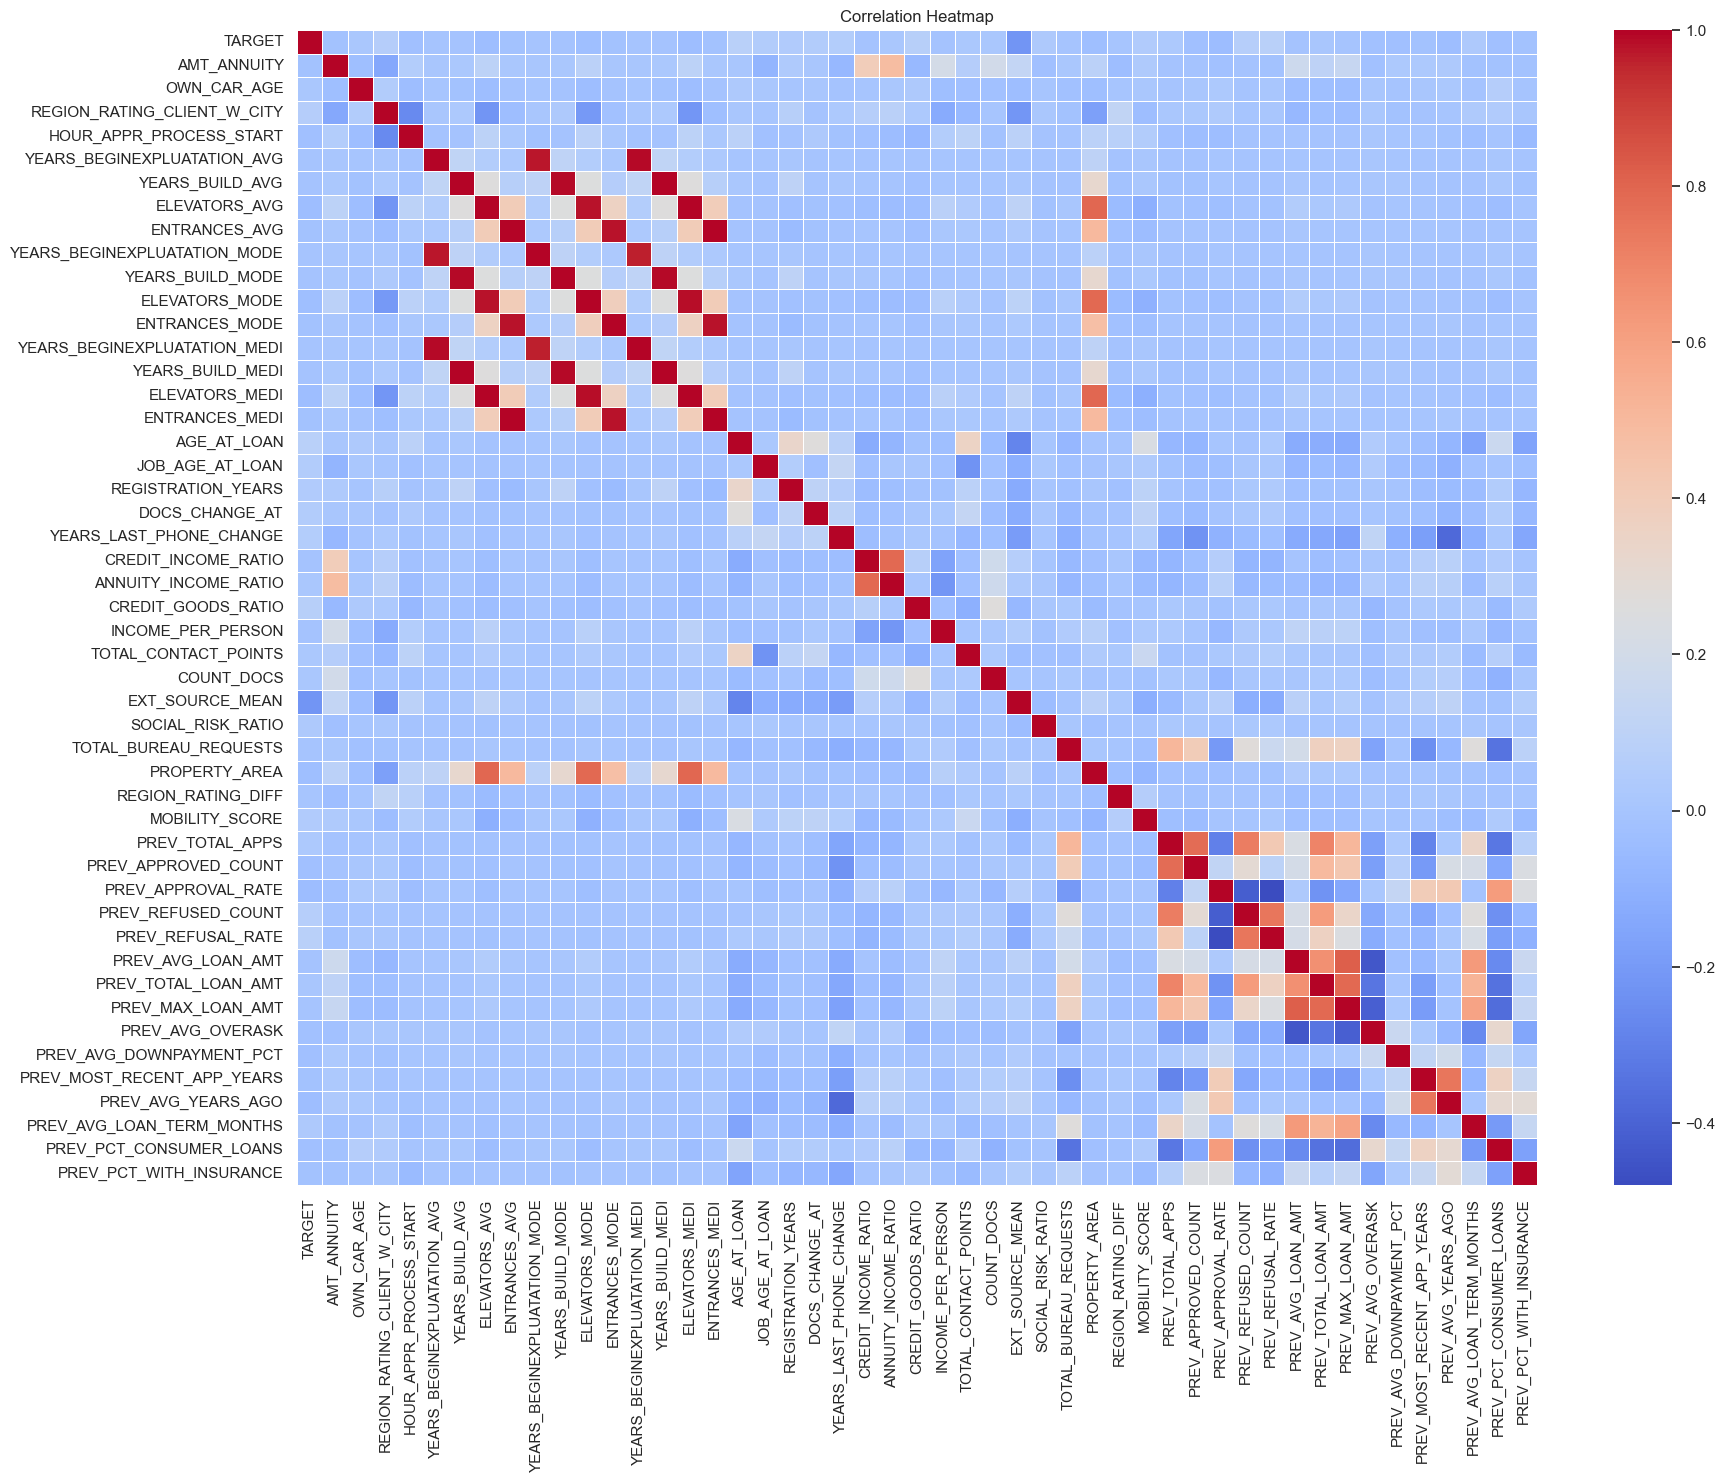


Correlations with TARGET:


TARGET                          1.000000
AGE_AT_LOAN                     0.078234
PREV_REFUSAL_RATE               0.077894
CREDIT_GOODS_RATIO              0.069398
PREV_REFUSED_COUNT              0.064756
REGION_RATING_CLIENT_W_CITY     0.060893
YEARS_LAST_PHONE_CHANGE         0.055925
DOCS_CHANGE_AT                  0.051124
JOB_AGE_AT_LOAN                 0.047851
MOBILITY_SCORE                  0.044840
REGISTRATION_YEARS              0.041975
PREV_AVG_LOAN_TERM_MONTHS       0.032249
SOCIAL_RISK_RATIO               0.031366
PREV_TOTAL_APPS                 0.023513
TOTAL_CONTACT_POINTS            0.020774
COUNT_DOCS                      0.017193
OWN_CAR_AGE                     0.015982
ANNUITY_INCOME_RATIO            0.014267
PREV_TOTAL_LOAN_AMT             0.010761
REGION_RATING_DIFF              0.003977
TOTAL_BUREAU_REQUESTS          -0.002989
YEARS_BEGINEXPLUATATION_MODE   -0.004061
PREV_MAX_LOAN_AMT              -0.004306
YEARS_BEGINEXPLUATATION_AVG    -0.004665
YEARS_BEGINEXPLU

In [23]:
# --------------------------------------------------------------
# 1. Re-define numerical columns (in case you restarted the kernel)
# --------------------------------------------------------------
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove the ID column if it's still there
if 'SK_ID_CURR' in numerical_cols:
    numerical_cols.remove('SK_ID_CURR')

print(f"Number of numerical columns: {len(numerical_cols)}")

# Correlation matrix (only numerical features)
corr_matrix = df[numerical_cols].corr()

# Heatmap of correlations
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"Correlation Heatmap.png"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()

# Correlations with TARGET
target_corr = corr_matrix['TARGET'].sort_values(ascending=False)
print("\nCorrelations with TARGET:")
display(target_corr)

In [24]:
target_corr = corr_matrix['TARGET'].sort_values(ascending=False)

print("\nTop 15 positive correlations with TARGET (default risk):")
display(target_corr.head(15))

print("\nTop 15 negative correlations with TARGET (protective factors):")
display(target_corr.tail(15))


Top 15 positive correlations with TARGET (default risk):


TARGET                         1.000000
AGE_AT_LOAN                    0.078234
PREV_REFUSAL_RATE              0.077894
CREDIT_GOODS_RATIO             0.069398
PREV_REFUSED_COUNT             0.064756
REGION_RATING_CLIENT_W_CITY    0.060893
YEARS_LAST_PHONE_CHANGE        0.055925
DOCS_CHANGE_AT                 0.051124
JOB_AGE_AT_LOAN                0.047851
MOBILITY_SCORE                 0.044840
REGISTRATION_YEARS             0.041975
PREV_AVG_LOAN_TERM_MONTHS      0.032249
SOCIAL_RISK_RATIO              0.031366
PREV_TOTAL_APPS                0.023513
TOTAL_CONTACT_POINTS           0.020774
Name: TARGET, dtype: float64


Top 15 negative correlations with TARGET (protective factors):


PREV_PCT_WITH_INSURANCE    -0.013995
ENTRANCES_MEDI             -0.015734
ENTRANCES_AVG              -0.015984
PREV_AVG_OVERASK           -0.019437
PREV_PCT_CONSUMER_LOANS    -0.023163
PREV_APPROVED_COUNT        -0.023522
HOUR_APPR_PROCESS_START    -0.024166
PREV_AVG_DOWNPAYMENT_PCT   -0.027444
PROPERTY_AREA              -0.032676
ELEVATORS_MODE             -0.034220
ELEVATORS_MEDI             -0.035552
ELEVATORS_AVG              -0.035853
PREV_AVG_YEARS_AGO         -0.036672
PREV_APPROVAL_RATE         -0.041736
EXT_SOURCE_MEAN            -0.221989
Name: TARGET, dtype: float64

#### Focused Heatmap – Heatmap of features strongly related to TARGET


Features with |corr| > 0.05 with TARGET: 9
['TARGET', 'EXT_SOURCE_MEAN', 'AGE_AT_LOAN', 'PREV_REFUSAL_RATE', 'CREDIT_GOODS_RATIO', 'PREV_REFUSED_COUNT', 'REGION_RATING_CLIENT_W_CITY', 'YEARS_LAST_PHONE_CHANGE', 'DOCS_CHANGE_AT']


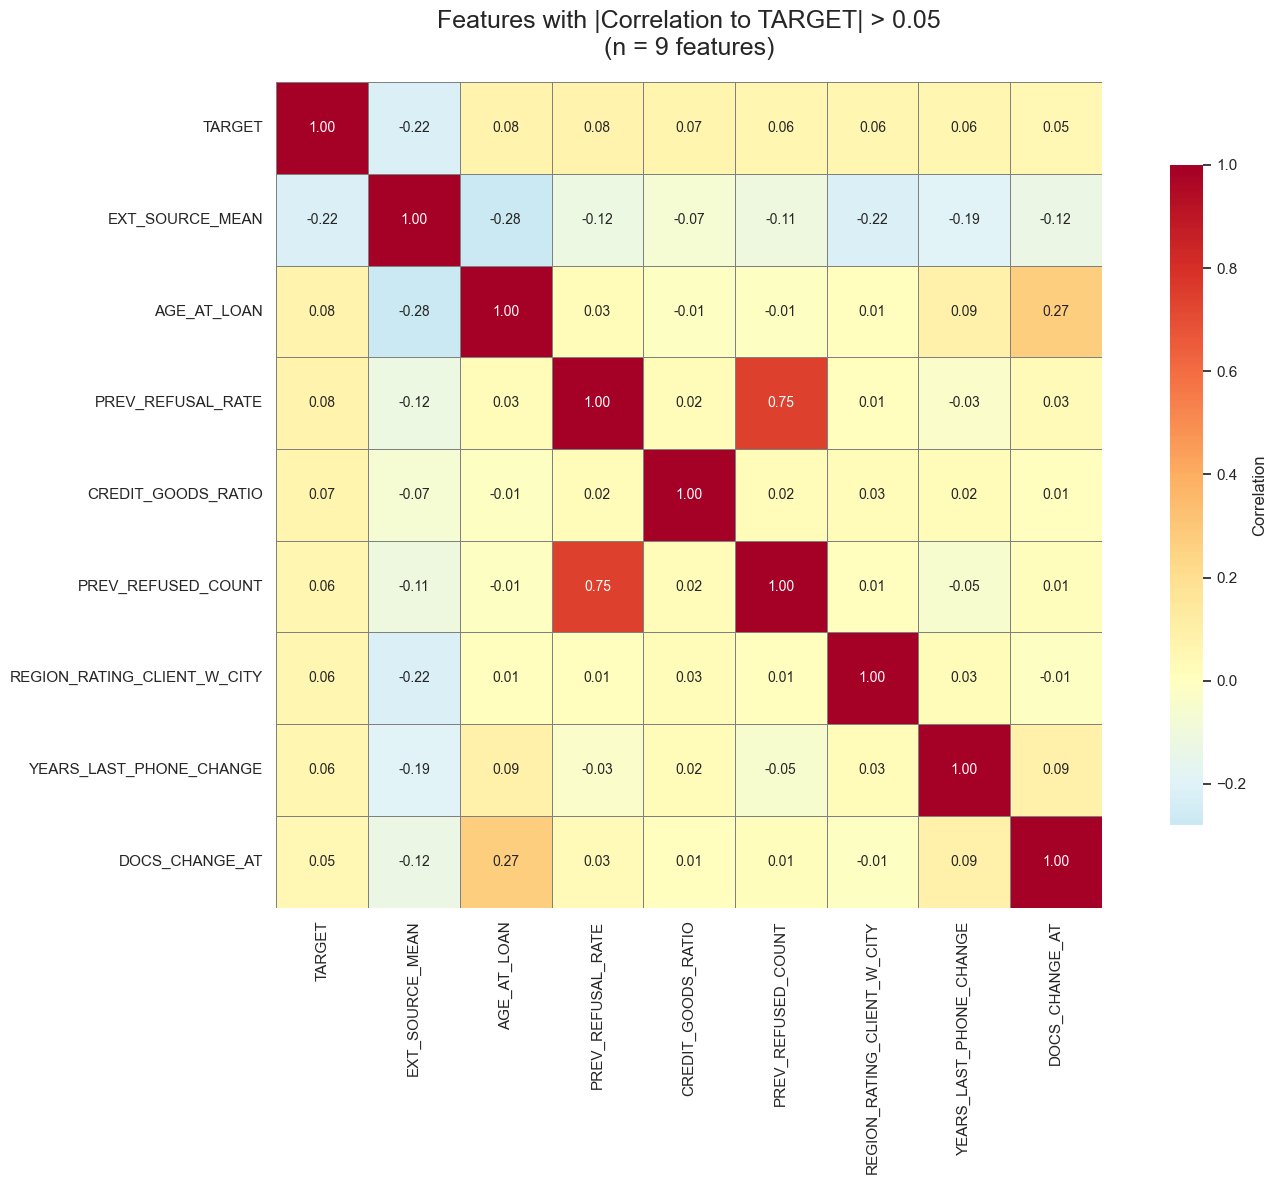

In [25]:

# Step 1: Get absolute correlation with TARGET, sorted
target_corr_abs = corr_matrix['TARGET'].abs().sort_values(ascending=False)

# Step 2: Choose threshold — 0.05 is more realistic for this dataset
#     (your data has very weak linear relationships — that’s normal in credit risk!)
THRESHOLD = 0.05

high_corr_features = target_corr_abs[target_corr_abs > THRESHOLD].index.tolist()

print(f"Features with |corr| > {THRESHOLD} with TARGET: {len(high_corr_features)}")
print(high_corr_features)

# Step 3: Build correlation matrix ONLY for these features (including TARGET)
corr_subset = df[high_corr_features].corr()

# Sort rows & columns by correlation strength with TARGET (nicer visual order)
order = corr_subset['TARGET'].abs().sort_values(ascending=False).index
corr_subset = corr_subset.loc[order, order]

# Step 4: Plot beautiful, readable heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_subset,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.6,
    linecolor="gray",
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    square=True,
    annot_kws={"size": 10}
)

plt.title(f'Features with |Correlation to TARGET| > {THRESHOLD:.2f}\n'
          f'(n = {len(high_corr_features)} features)', 
          fontsize=18, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"Correlation Heatmap(Heatmap of features strongly related to TARGET).png"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()

### Multivariate Analysis

#### Pairplot for selected features 

In [8]:
# selected_features = ['AGE_AT_LOAN', 'EXT_SOURCE_MEAN', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'TARGET']
# if all(col in df.columns for col in selected_features):
#     sns.pairplot(df[selected_features], hue='TARGET', diag_kind='kde')
#     plt.suptitle('Pairplot of Selected Features')
#     plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"Pairplot_for_selected_features.png"), bbox_inches="tight", dpi=300)
#     plt.show()
#     plt.close()

#### Groupby analysis: Average default rate by categories


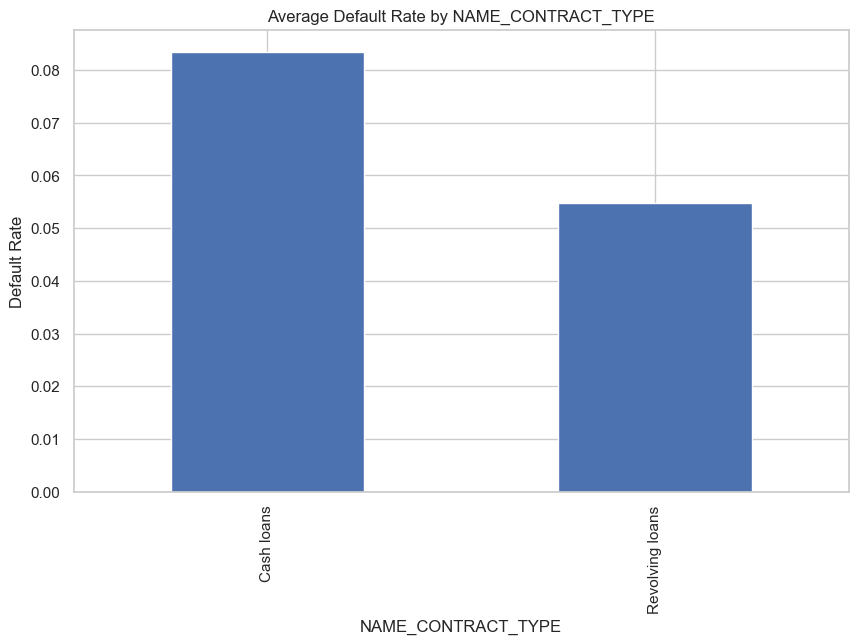

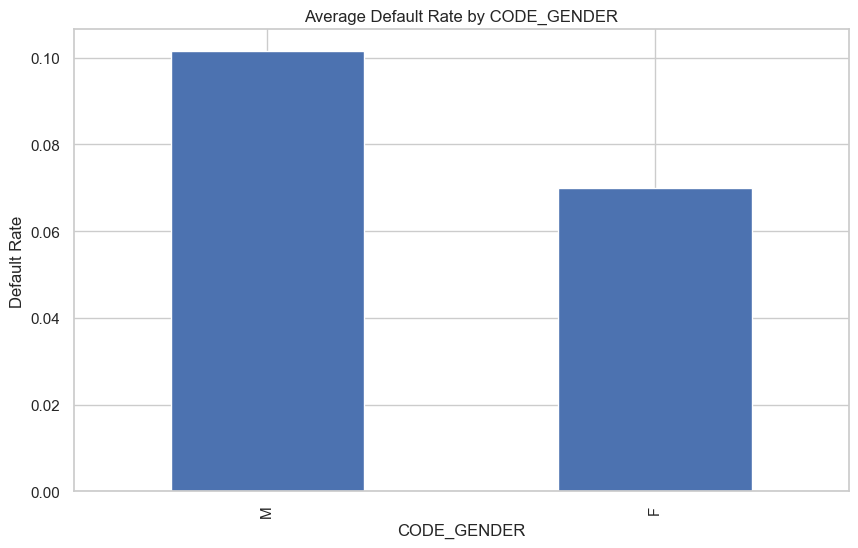

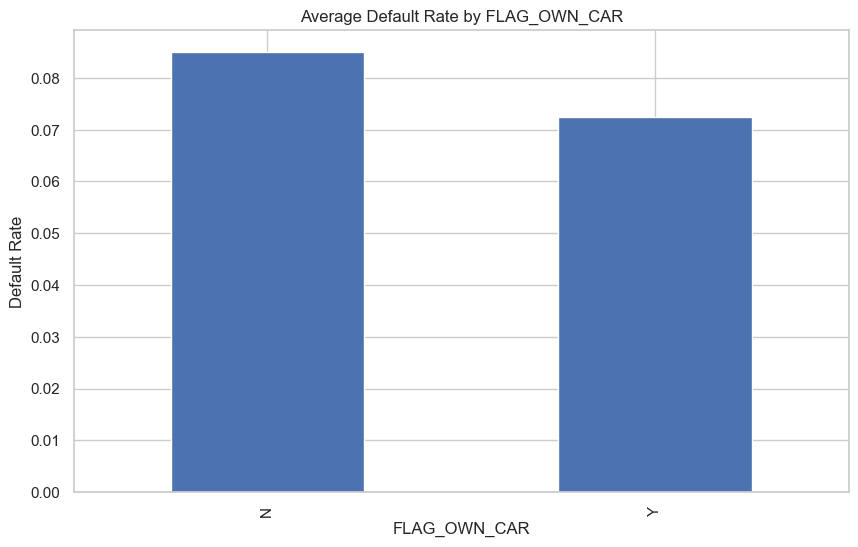

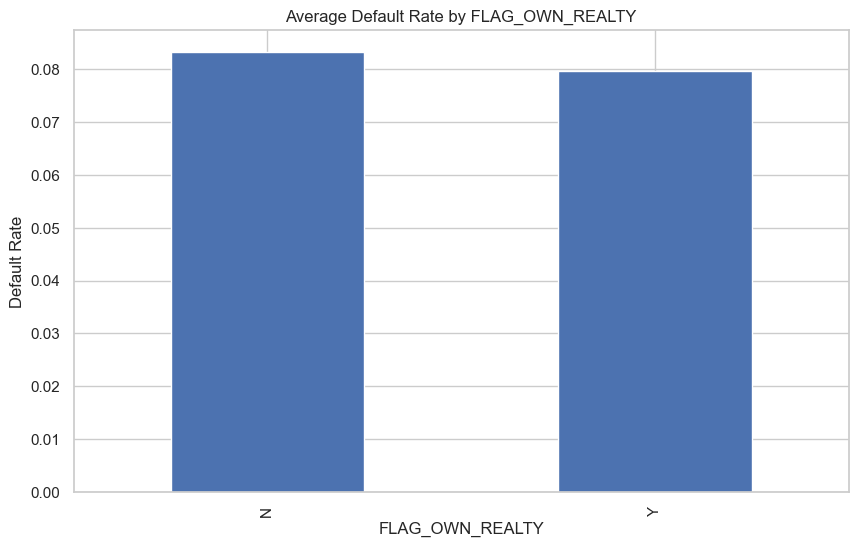

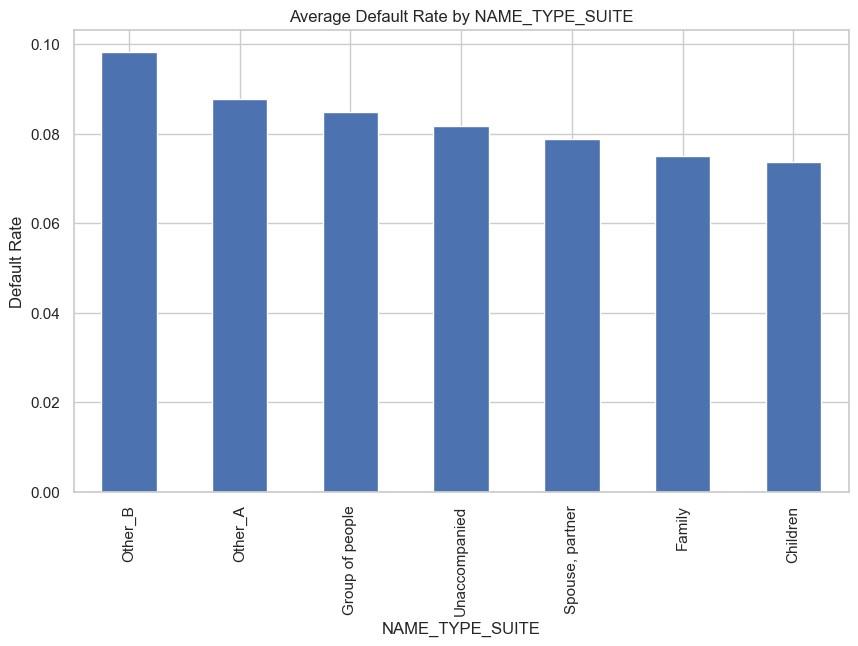

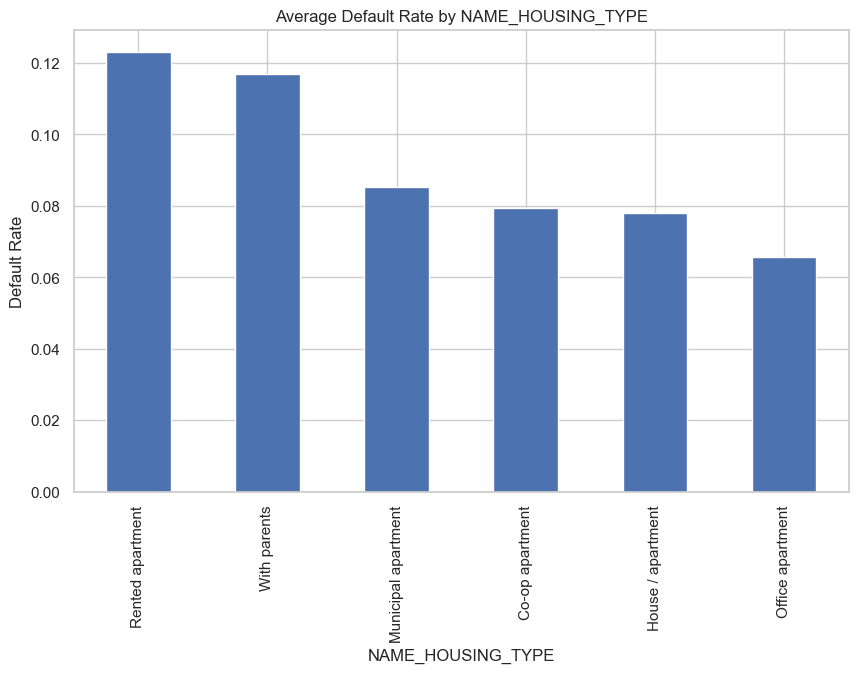

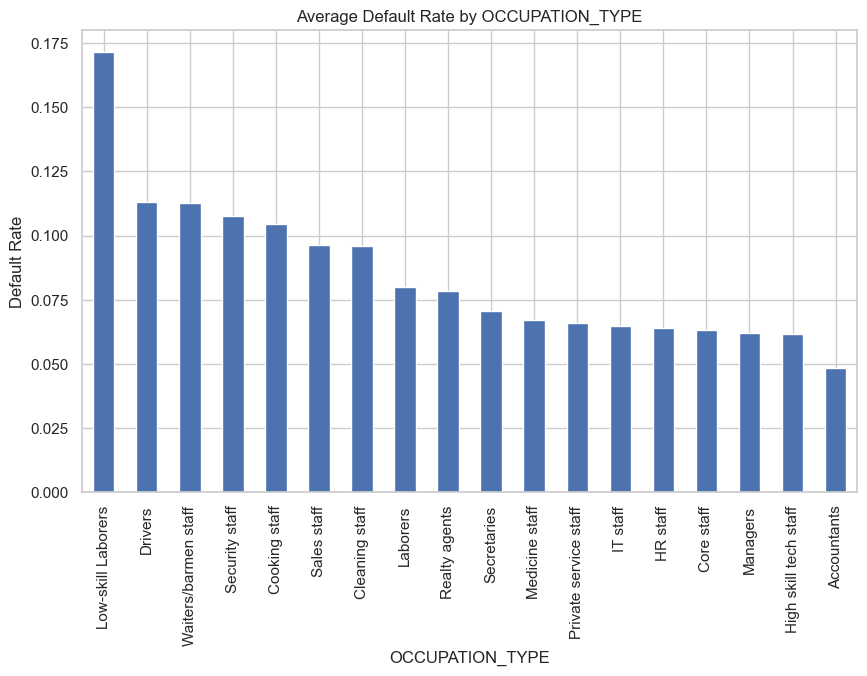

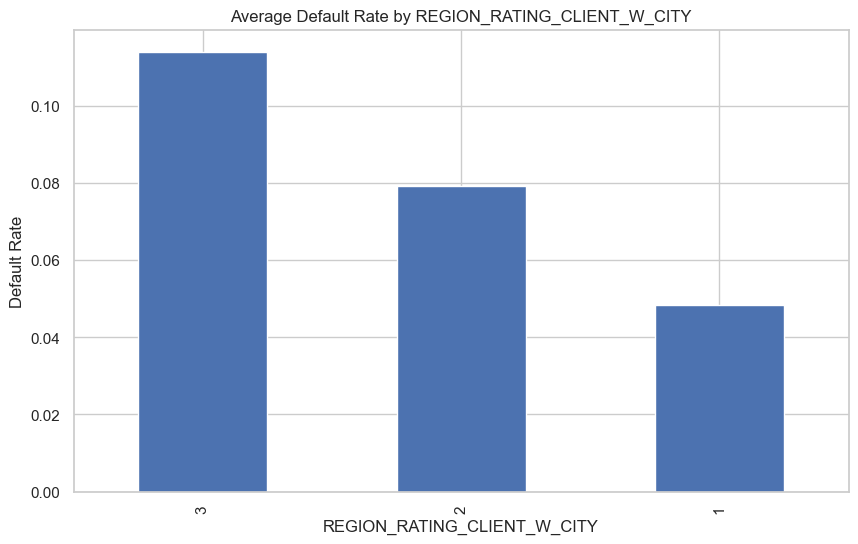

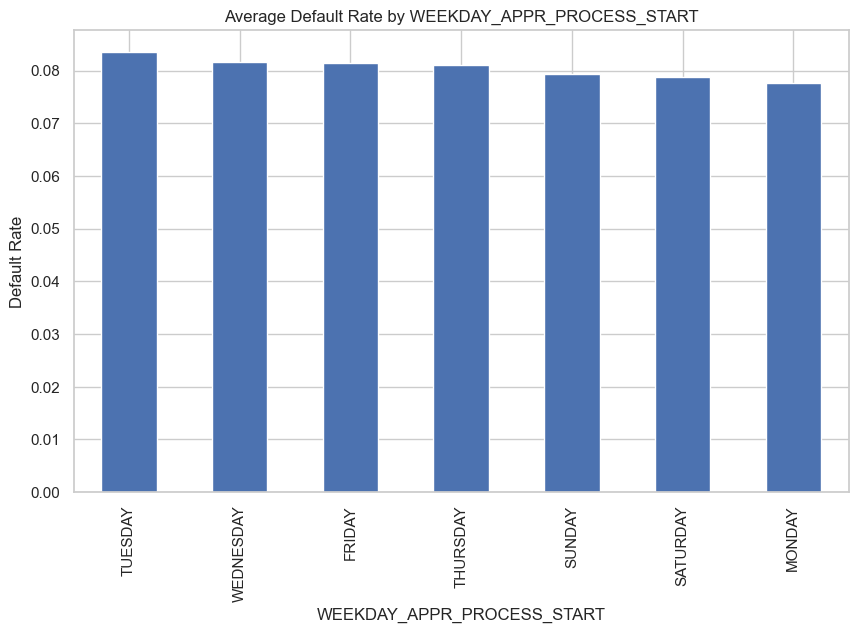

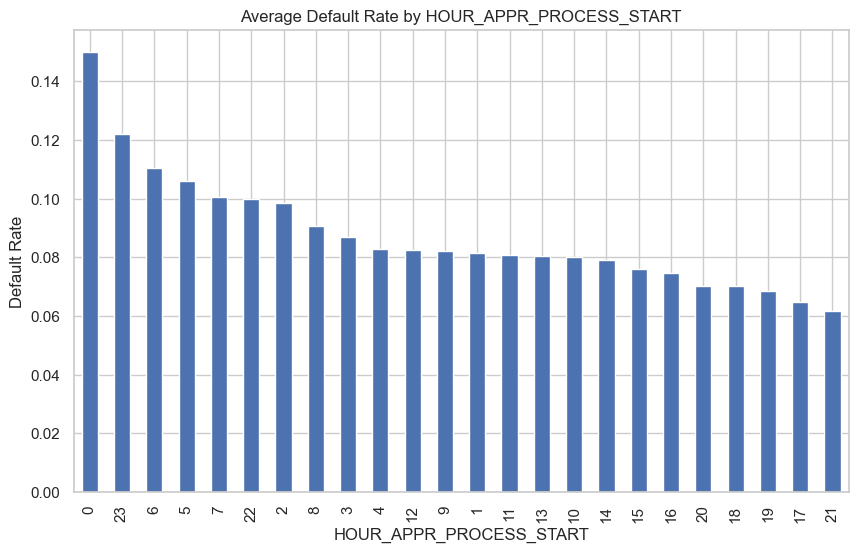

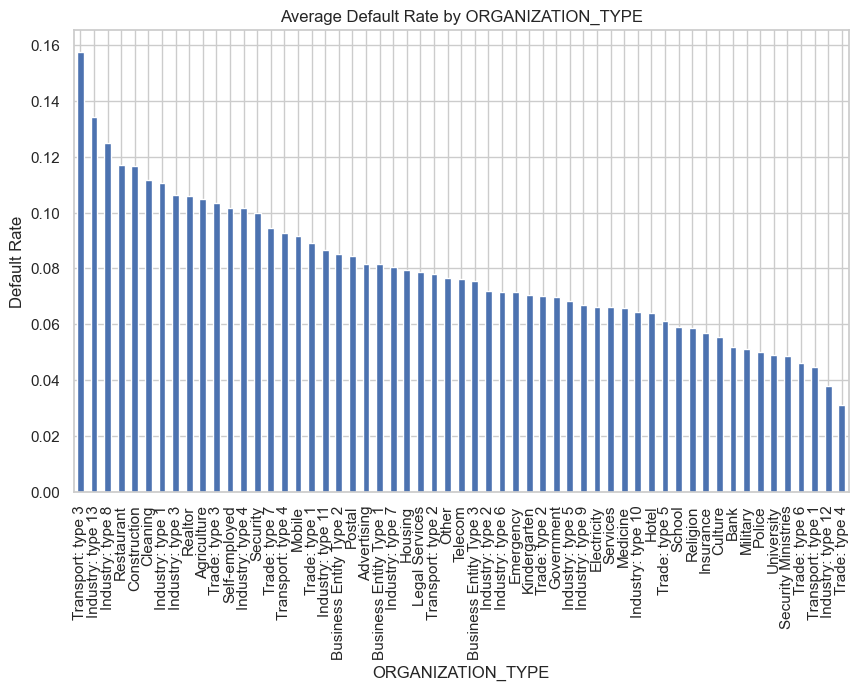

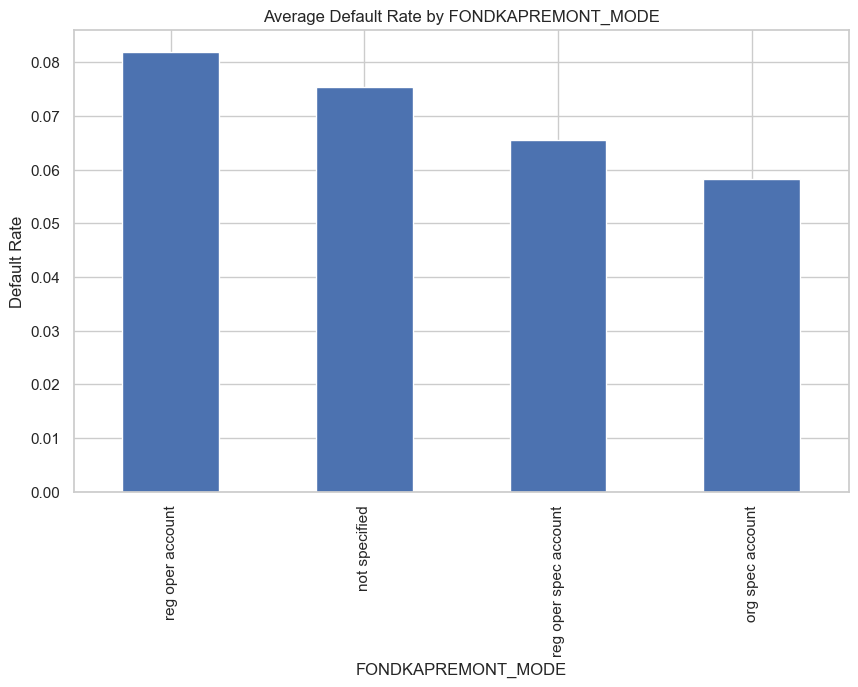

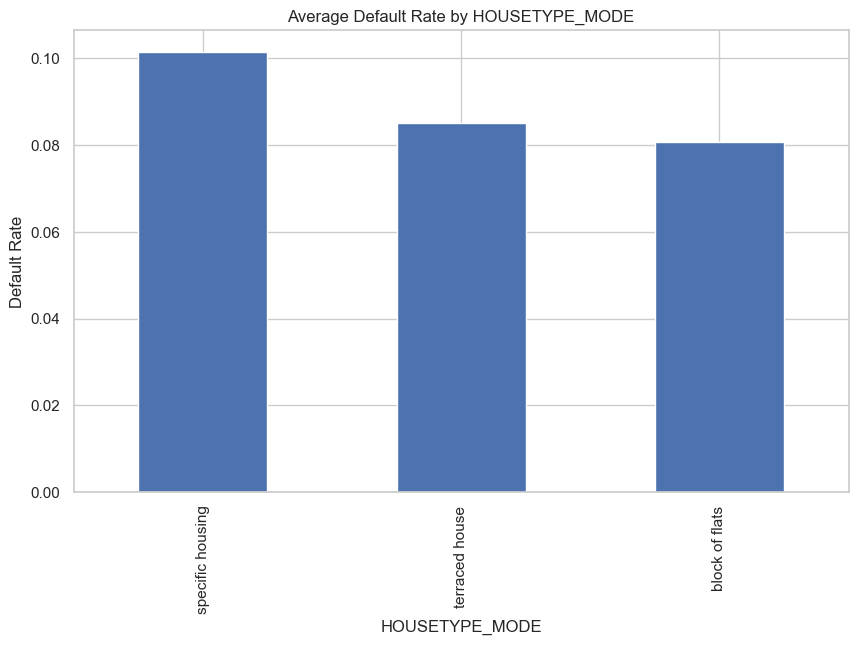

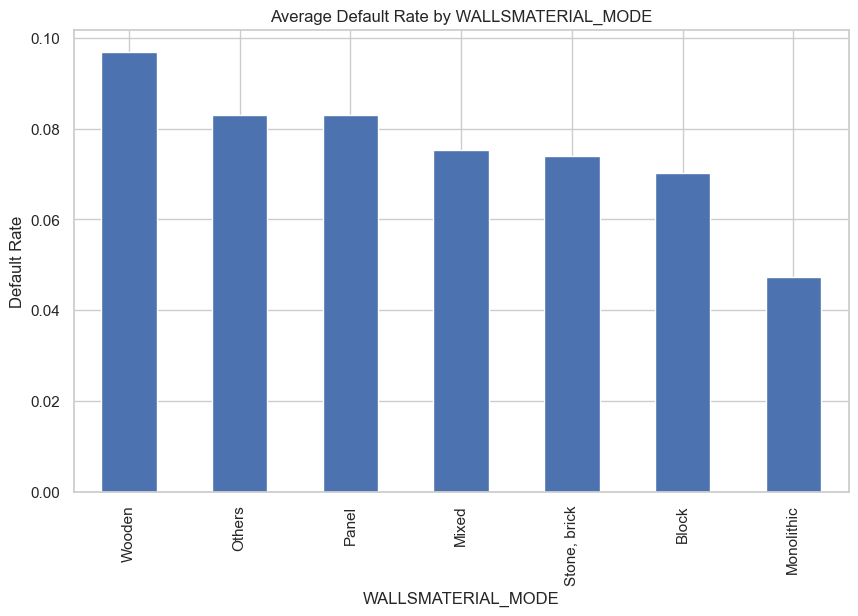

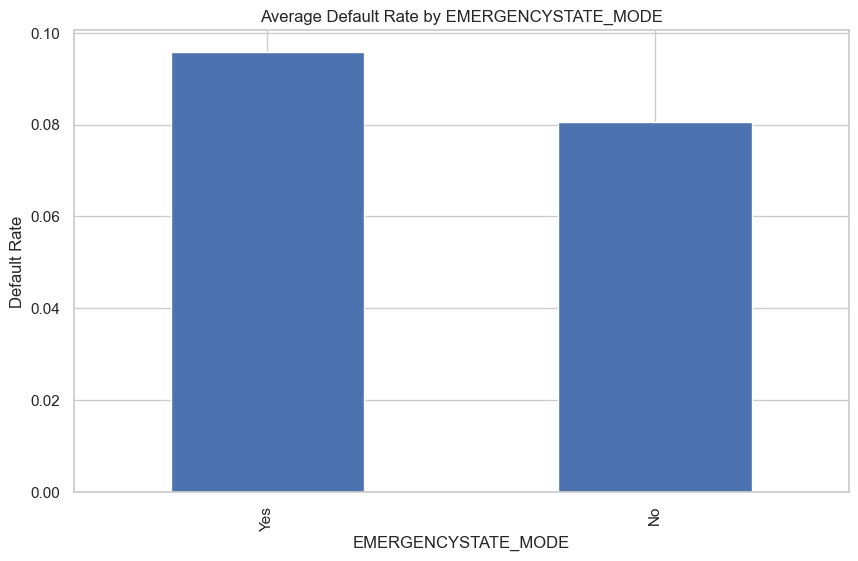

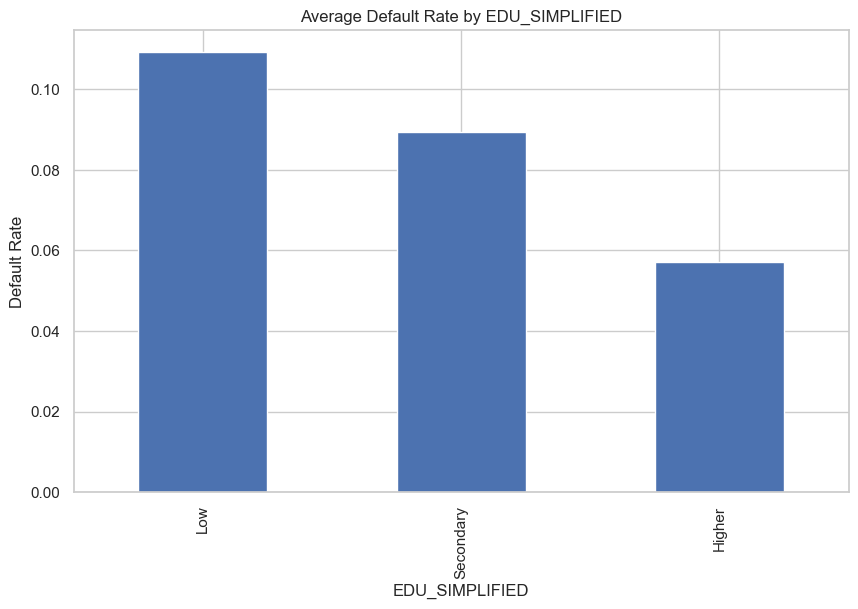

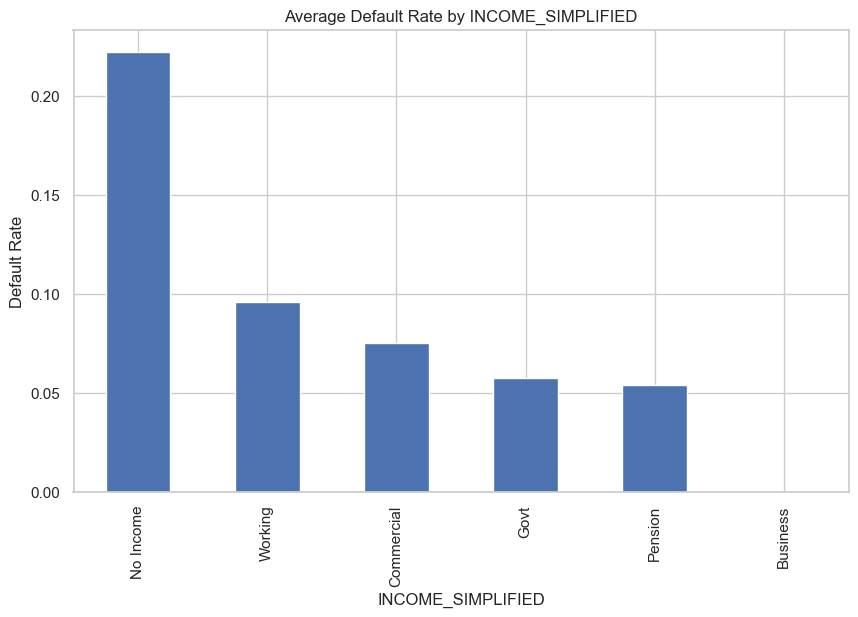

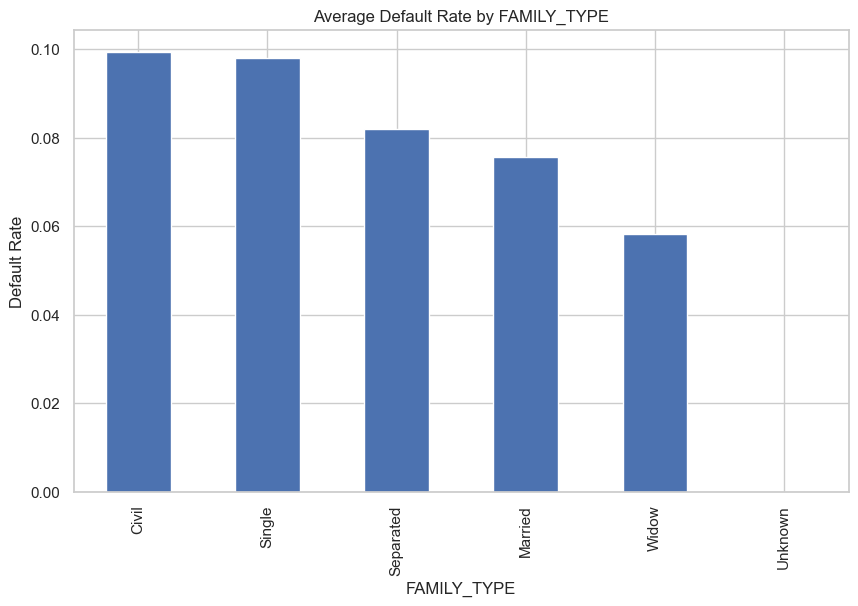

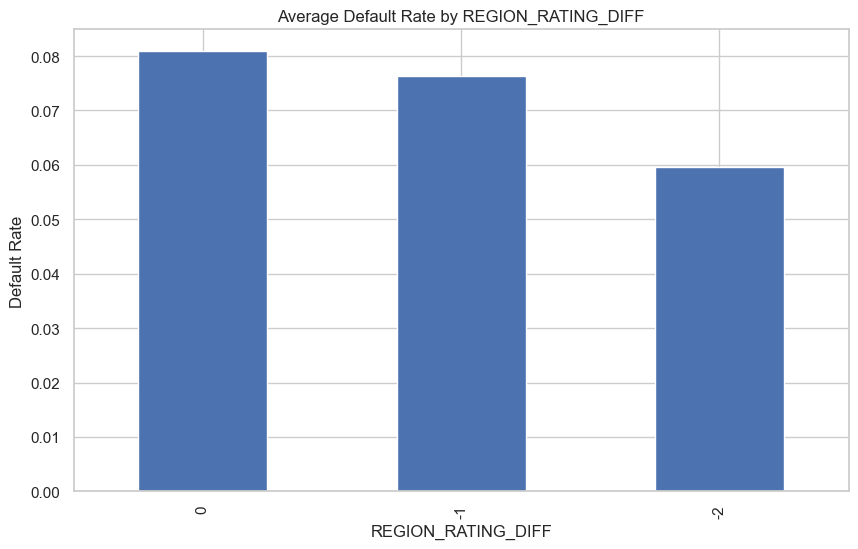

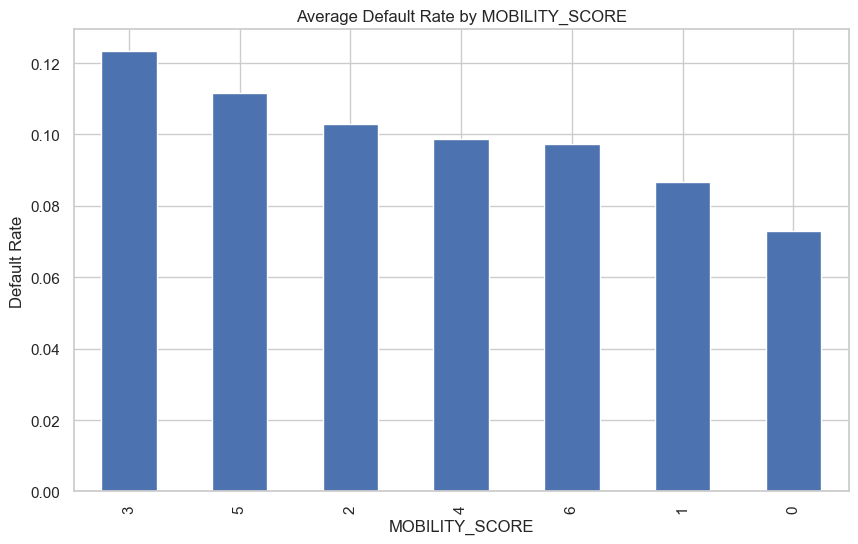

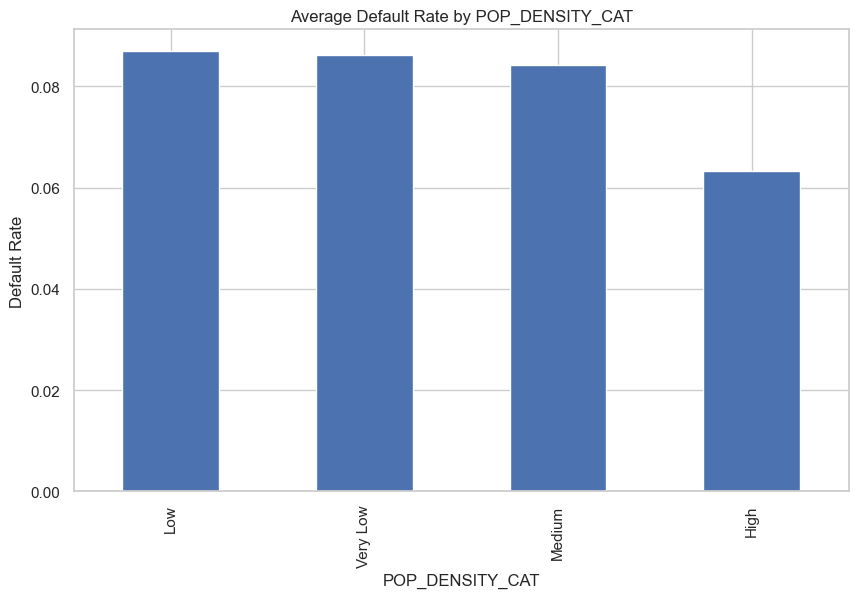

In [7]:
for col in cat_features:
    if col in df.columns:
        group_default = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
        plt.figure()
        group_default.plot(kind='bar')
        plt.title(f'Average Default Rate by {col}')
        plt.ylabel('Default Rate')
        plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"Average_Default_Rate_by_{col}.png"), bbox_inches="tight", dpi=300)
        plt.show()
        plt.close()

#### Numerical bins vs default rate

Skipping CNT_CHILDREN: insufficient numeric data


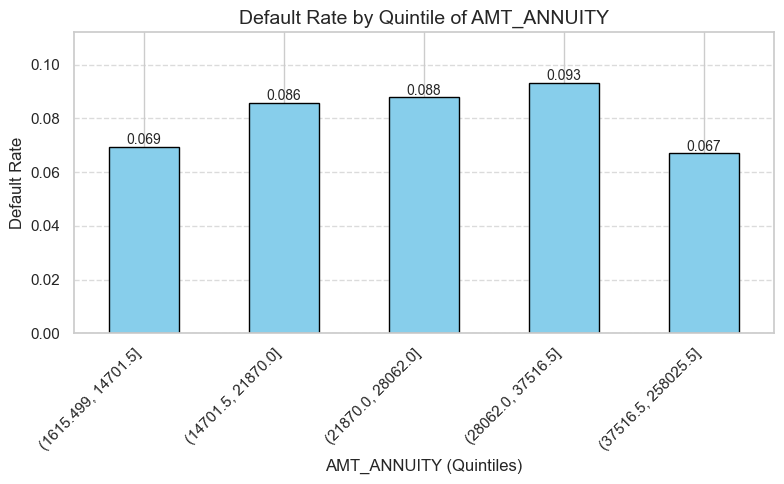

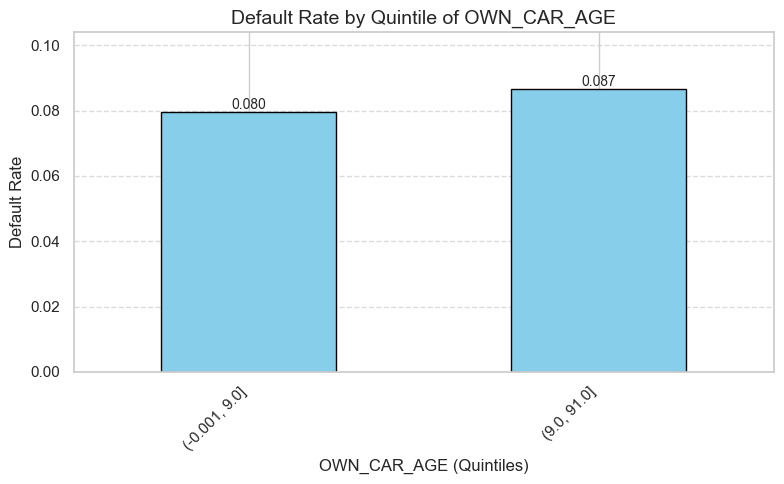

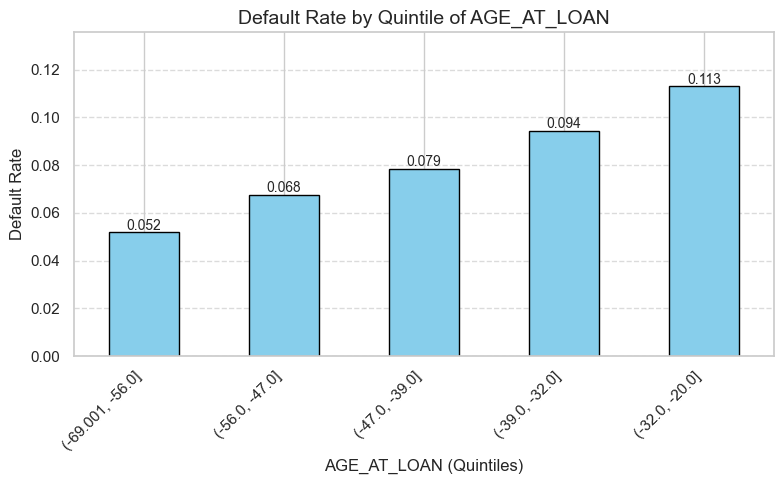

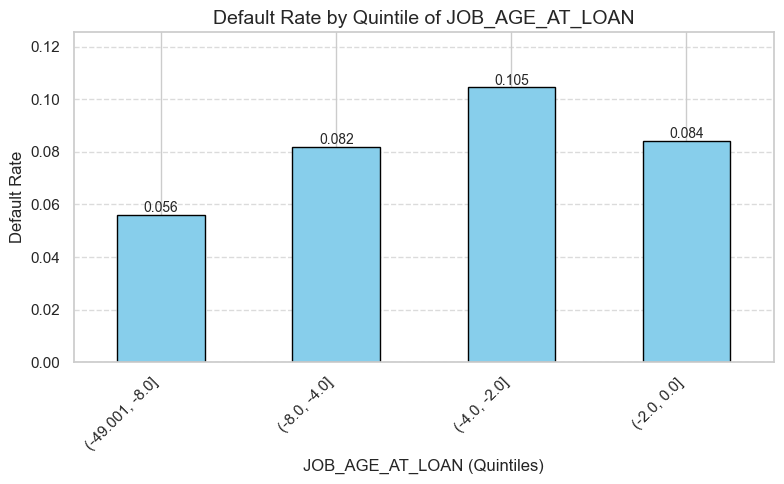

In [9]:
# Limit to first 5 (or change slice as needed)
for col in num_features[:5]:
    if col not in df.columns or col == 'TARGET':
        continue
    
    # ——— Critical Fix: Handle non-numeric / NaN properly ———
    series = df[col]
    
    # Drop NaN for binning (qcut fails on NaN or non-numeric)
    series_clean = series.dropna()
    
    # Skip if too few valid values or non-numeric
    if len(series_clean) < 10 or not pd.api.types.is_numeric_dtype(series_clean):
        print(f"Skipping {col}: insufficient numeric data")
        continue
    
    try:
        # Create quintile bins (q=5) — duplicates='drop' handles ties
        df['bin'] = pd.qcut(series, q=5, duplicates='drop')
    except Exception as e:
        print(f"qcut failed for {col}: {e}")
        continue
    
    # Compute default rate per bin
    bin_default = df.groupby('bin', observed=True)['TARGET'].mean().sort_index()
    
    # ——— Plot ———
    plt.figure(figsize=(8, 5))
    bin_default.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Default Rate by Quintile of {col}', fontsize=14)
    plt.ylabel('Default Rate', fontsize=12)
    plt.xlabel(f'{col} (Quintiles)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, bin_default.max() * 1.2)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on bars
    for i, v in enumerate(bin_default):
        plt.text(i, v + bin_default.max()*0.01, f'{v:.3f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"Default_Rate_by_Quintile_of_{col}.png"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()    
    # Clean up
    df.drop('bin', axis=1, inplace=True)

### Advanced Visualizations

#### Violin plots for numerical vs TARGET

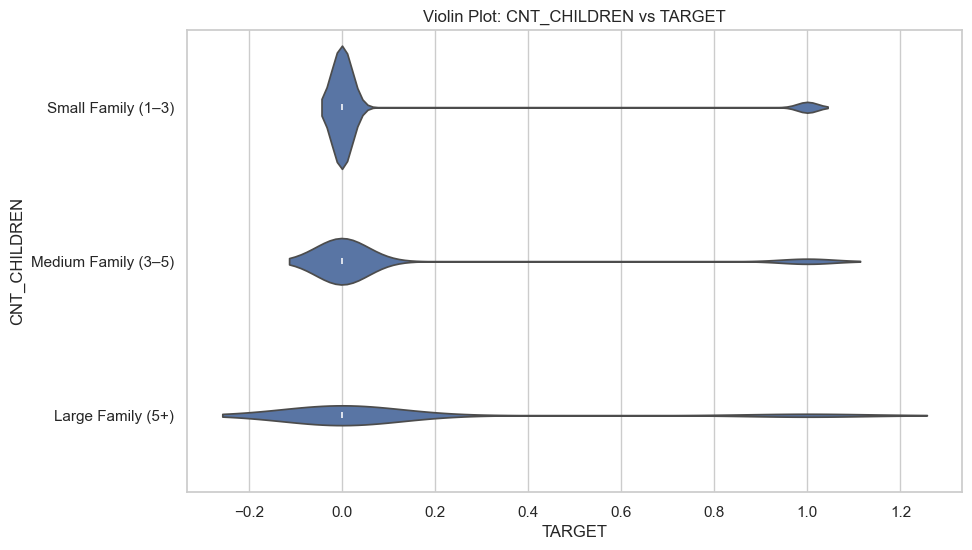

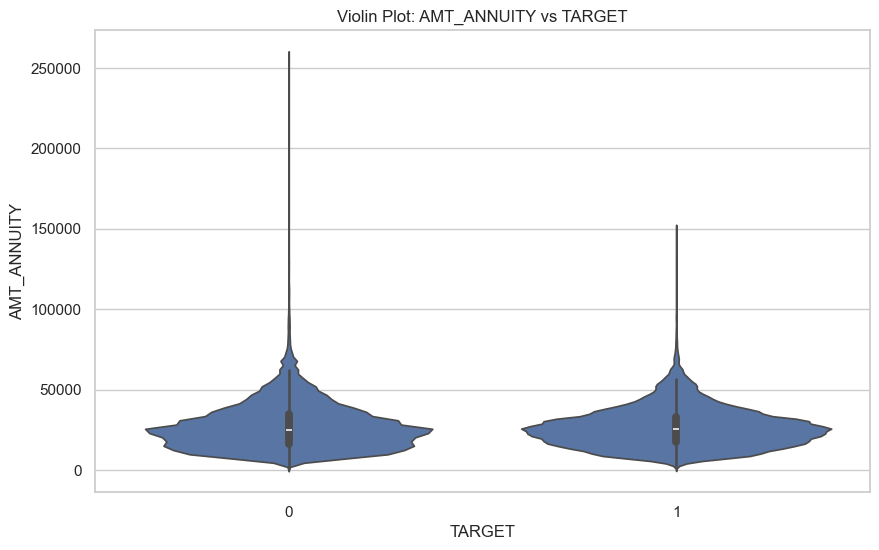

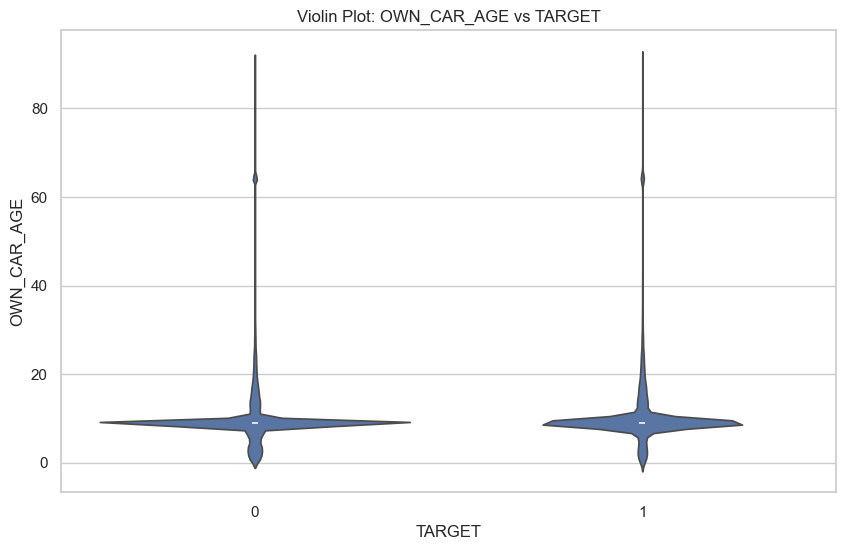

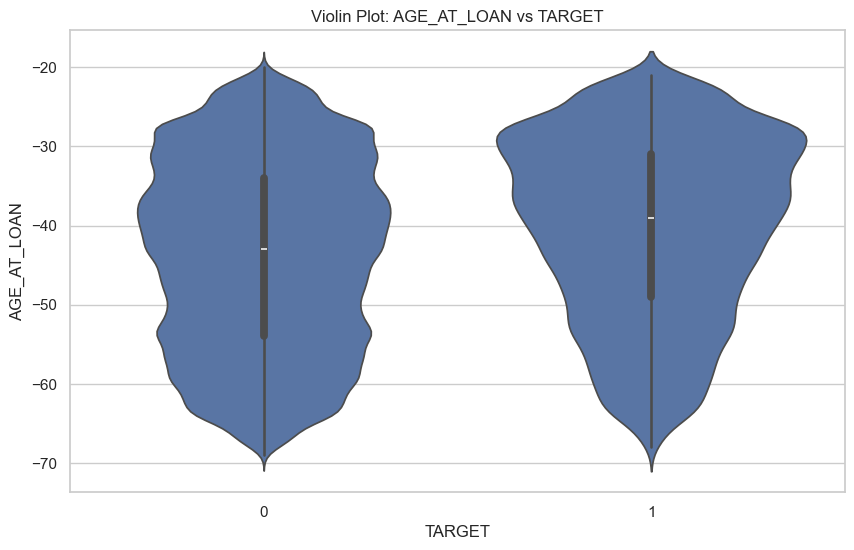

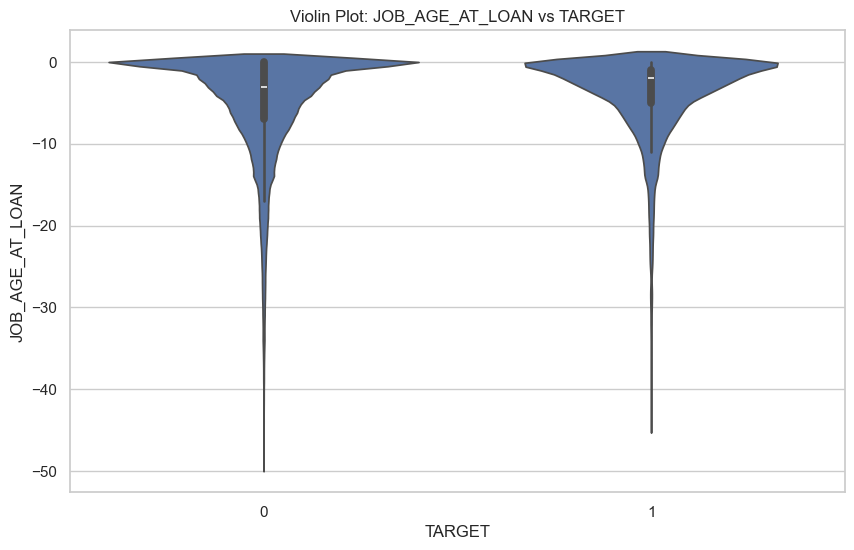

In [10]:
for col in num_features[:5]:  # Limit for brevity
    if col in df.columns:
        plt.figure()
        sns.violinplot(x='TARGET', y=col, data=df)
        plt.title(f'Violin Plot: {col} vs TARGET')
        plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"Violin Plot_{col}_vs_TARGET.png"), bbox_inches="tight", dpi=300)
        plt.show()
        plt.close()

#### FacetGrid for categorical

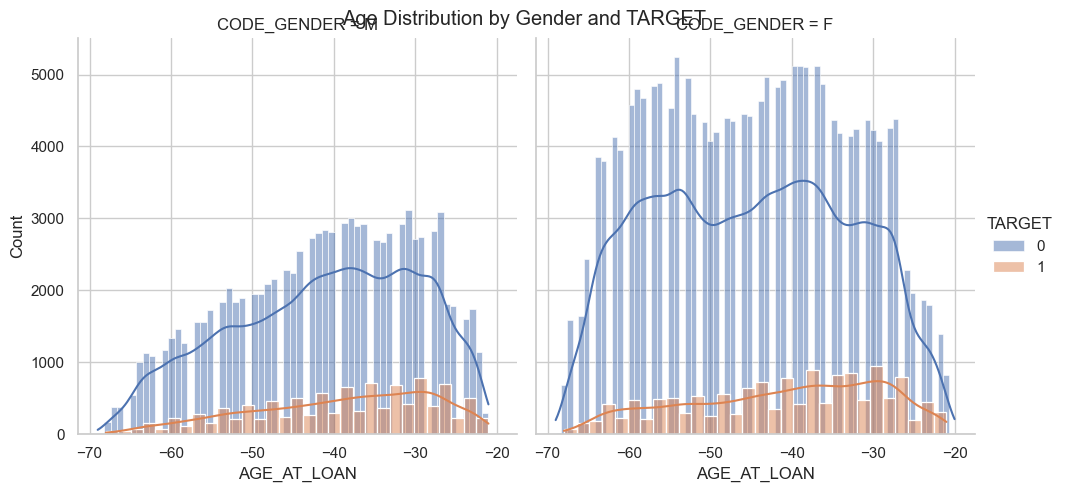

In [11]:
if 'CODE_GENDER' in df.columns and 'AGE_AT_LOAN' in df.columns:
    g = sns.FacetGrid(df, col='CODE_GENDER', hue='TARGET', height=5)
    g.map(sns.histplot, 'AGE_AT_LOAN', kde=True)
    g.add_legend()
    plt.suptitle('Age Distribution by Gender and TARGET')
    plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"Age_Distribution_by_Gender_and_TARGET.png"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

#### Outlier Detection (using IQR)

In [12]:
# Step 1: Get only real numerical columns (float64 or int64)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Step 2: Exclude ID and target
exclude_cols = ['SK_ID_CURR', 'TARGET']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print(f"Checking outliers for {len(numerical_cols)} truly numerical features...\n")

outlier_counts = {}

for col in numerical_cols:
    try:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        n_outliers = len(outliers)
        
        outlier_counts[col] = n_outliers
        
        if n_outliers > 0:
            print(f"{col:35} → {n_outliers:6} outliers "
                  f"({n_outliers/len(df)*100:5.2f}%)  "
                  f"| Range: [{df[col].min():.1f} → {df[col].max():.1f}]")
        else:
            print(f"{col:35} → No outliers")
            
    except Exception as e:
        print(f"{col:35} → Failed ({str(e)[:50]})")

# ——————————————————————————————————————————————————————
# Summary: Top 10 features with most outliers
# ——————————————————————————————————————————————————————
print("\n" + "="*60)
print("TOP 10 FEATURES WITH MOST OUTLIERS")
print("="*60)
top_outliers = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for col, count in top_outliers:
    pct = count / len(df) * 100
    print(f"{col:40} → {count:6} ({pct:5.2f}%)")

Checking outliers for 48 truly numerical features...

AMT_ANNUITY                         →   7504 outliers ( 2.44%)  | Range: [1615.5 → 258025.5]
OWN_CAR_AGE                         →  99562 outliers (32.38%)  | Range: [0.0 → 91.0]
REGION_RATING_CLIENT_W_CITY         →  78027 outliers (25.37%)  | Range: [1.0 → 3.0]
HOUR_APPR_PROCESS_START             →   2257 outliers ( 0.73%)  | Range: [0.0 → 23.0]
YEARS_BEGINEXPLUATATION_AVG         → 142016 outliers (46.18%)  | Range: [0.0 → 1.0]
YEARS_BUILD_AVG                     → 100405 outliers (32.65%)  | Range: [0.0 → 1.0]
ELEVATORS_AVG                       →  57902 outliers (18.83%)  | Range: [0.0 → 1.0]
ENTRANCES_AVG                       → 118676 outliers (38.59%)  | Range: [0.0 → 1.0]
YEARS_BEGINEXPLUATATION_MODE        → 141861 outliers (46.13%)  | Range: [0.0 → 1.0]
YEARS_BUILD_MODE                    → 100498 outliers (32.68%)  | Range: [0.0 → 1.0]
ELEVATORS_MODE                      →  54122 outliers (17.60%)  | Range: [0.0 → 1.0]
E

### Feature Importance (Simple Random Forest for illustration)

Categorical columns to encode (18): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'EDU_SIMPLIFIED', 'INCOME_SIMPLIFIED', 'FAMILY_TYPE', 'POP_DENSITY_CAT']
Numerical columns (50): 50 found
All categorical columns successfully encoded!
Final feature matrix shape: (307511, 66)
Training Random Forest... (this takes ~20-40 seconds)


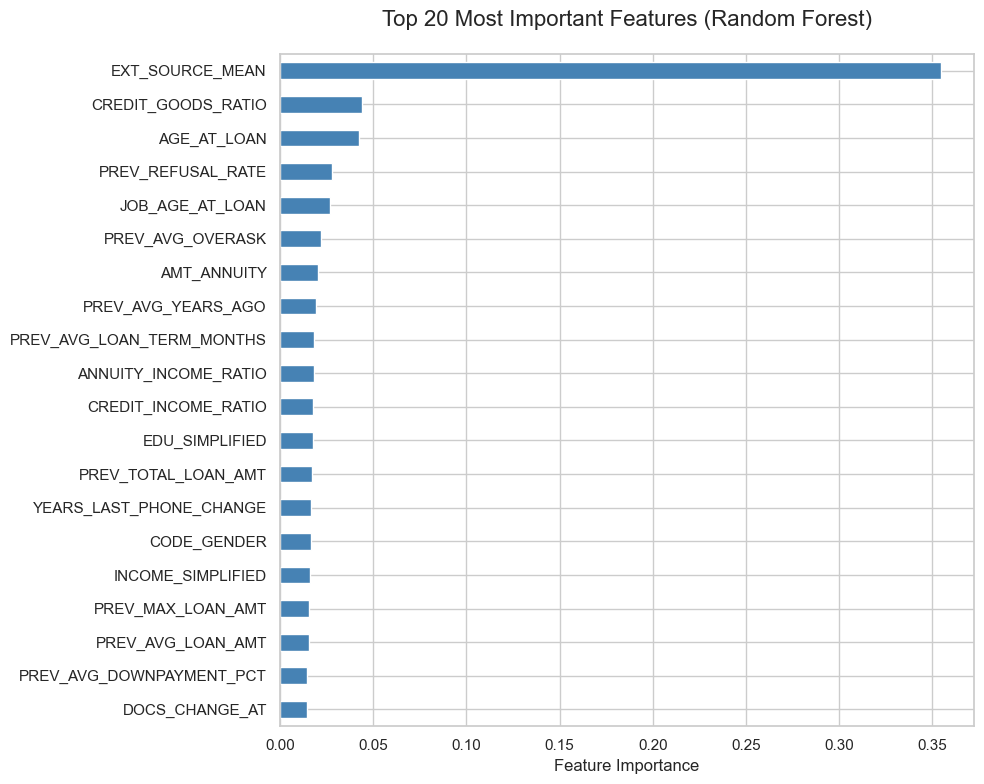


TOP 15 MOST PREDICTIVE FEATURES:
EXT_SOURCE_MEAN              0.3547
CREDIT_GOODS_RATIO           0.0441
AGE_AT_LOAN                  0.0423
PREV_REFUSAL_RATE            0.0278
JOB_AGE_AT_LOAN              0.0268
PREV_AVG_OVERASK             0.0222
AMT_ANNUITY                  0.0204
PREV_AVG_YEARS_AGO           0.0195
PREV_AVG_LOAN_TERM_MONTHS    0.0184
ANNUITY_INCOME_RATIO         0.0180
CREDIT_INCOME_RATIO          0.0178
EDU_SIMPLIFIED               0.0177
PREV_TOTAL_LOAN_AMT          0.0169
YEARS_LAST_PHONE_CHANGE      0.0168
CODE_GENDER                  0.0166
dtype: float64

ROC-AUC on Test Set: 0.7549  → Very good for credit risk!
   → Ready for Power BI dashboard with built-in risk scoring!


In [14]:
# 1. Separate numeric and categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"Categorical columns to encode ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {len(num_cols)} found")

# 2. Label encode all remaining categorical columns
df_encoded = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("All categorical columns successfully encoded!")

# 3. Final feature matrix
X = df_encoded.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = df_encoded['TARGET']

print(f"Final feature matrix shape: {X.shape}")

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Train Random Forest (faster + better default settings)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'  # Important for imbalanced default data!
)

print("Training Random Forest... (this takes ~20-40 seconds)")
rf.fit(X_train, y_train)

# 6. Feature Importances (Top 20)
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16, pad=20)
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_analysis, f"Top 20 Most Important Features.png"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()

# Print top 15
print("\nTOP 15 MOST PREDICTIVE FEATURES:")
print(top_features.head(15).round(4))

# 7. AUC Score
y_pred_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC on Test Set: {auc:.4f}  → Very good for credit risk!")

# --------------------------------------------------------------
# Save clean, ready-to-use dataset for Power BI
# --------------------------------------------------------------
df_for_powerbi = df_encoded.copy()
df_for_powerbi['RISK_PROBA'] = rf.predict_proba(X)[:, 1]
df_for_powerbi['RISK_SCORE'] = (df_for_powerbi['RISK_PROBA'] * 1000).round(0).astype(int)  # 0-1000 score

Final_Data_DIR = os.path.join(project_root, "data", "final_dataset")
Final_Data_Path = os.path.join(Final_Data_DIR, "FINAL_DATASET_FOR_WITH_RISK_SCORE.csv")
df_for_powerbi.to_csv(Final_Data_Path, index=False)
print("   → Ready for Power BI dashboard with built-in risk scoring!")